In [1]:
import jax
import equinox as eqx
import jax.random as jrandom
from diff_ml.reference_models.analytic import Analytic
from diff_ml.reference_models.bachelier import Bachelier
from diff_ml.reference_models.heston import Heston
from diff_ml.reference_models.mnist import MNIST_ref
from diff_ml.nn.utils import init_linear_weight, trunc_init
import optax
from diff_ml.nn.train import train

from diff_ml.utils import Range, MakeScalar, mse

from jax import vmap
import jax.numpy as jnp

from diff_ml.losses.directions import StreamingHessianSketch

In [2]:
import matplotlib.pyplot as plt

# style change for latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "EB Garamond",
    "font.size": 12
})

### smoothed payoff differential plot

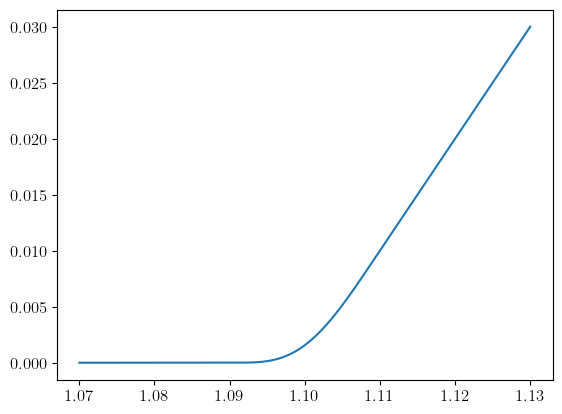

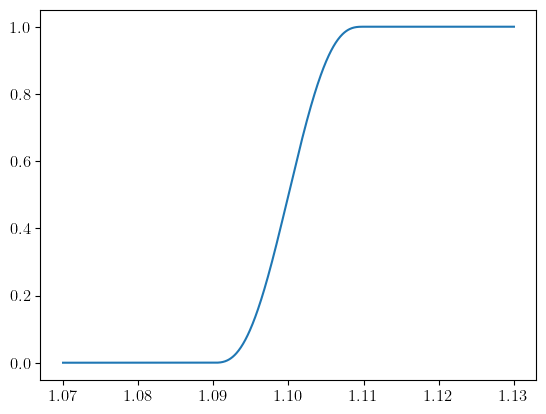

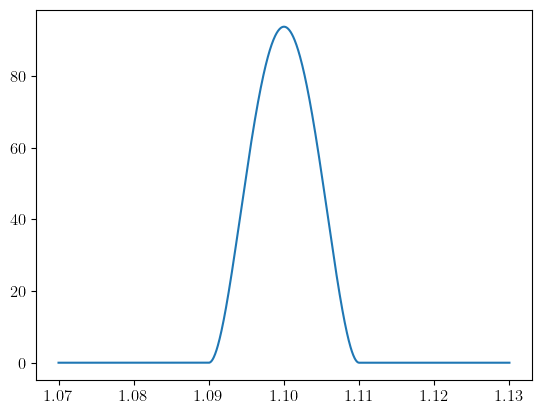

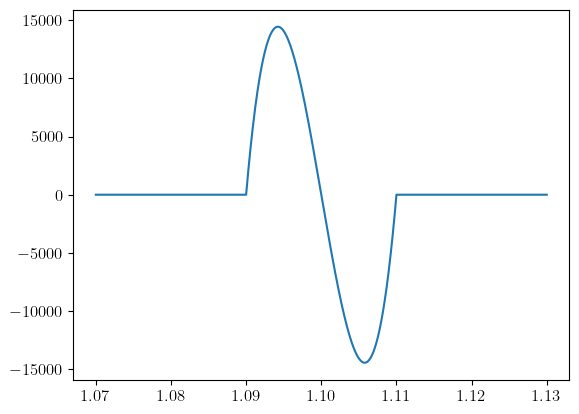

In [3]:
from diff_ml.reference_models.bachelier import EuropeanPayoff

smoothed_fn = EuropeanPayoff.smoothed_call

K=1.10
eps = 0.01

S_Ts = jnp.linspace(K - 3*eps, K + 3*eps, 1000)

def payoff_fn(S_T):
    return smoothed_fn(S_T, K, eps)
payoffs = jax.vmap(payoff_fn)(S_Ts)
plt.plot(S_Ts, payoffs)
plt.show()

# first derivative
payoff_fn_grad = jax.grad(payoff_fn)
payoffs_grad = jax.vmap(payoff_fn_grad)(S_Ts)
plt.plot(S_Ts, payoffs_grad)
plt.show()

# second derivative
payoff_fn_hess = jax.grad(payoff_fn_grad)
payoffs_hess = jax.vmap(payoff_fn_hess)(S_Ts)
plt.plot(S_Ts, payoffs_hess)
plt.show()

# third derivative
payoff_fn_third = jax.grad(payoff_fn_hess)
payoffs_third = jax.vmap(payoff_fn_third)(S_Ts)
plt.plot(S_Ts, payoffs_third)
plt.show()

# Single Run

In [3]:

key = jrandom.PRNGKey(1)
key, subkey = jrandom.split(key)



#ref_model_analytic = Analytic(
#    key=key,
#    #type="RHE",
#    #type="Rastrigin",
#    type="Rosenbrock",
#    #type="Ackley", 
#    #type="CubicRankR"
#    d=5,
#    min_x=-1.5,
#    max_x=2.5
#)
##RHE: min_x = -5.0, max_x = 5.0
##Rastrigin: min_x = -5.12, max_x = 5.12
##Rosenbrock: min_x = -1.5, max_x = 2.5
##Ackley: min_x = -5.0, max_x = 5.0
##CubicRankR: min_x = -1.0, max_x = 1.0


ref_model_mnist = MNIST_ref(
    key=key, 
    scale=0.5,
    target_class=9
)


#basket_dim = 7
#ref_model_heston = Heston(
#    key = key,
#    basket_dim=basket_dim,
#    basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0),
#    )

#basket_dim = 7
#ref_model_bachelier = Bachelier(
#    key,
#    basket_dim=basket_dim, 
#    weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
#)



#ref_model = ref_model_bachelier
#ref_model = ref_model_heston
#ref_model = ref_model_analytic
ref_model = ref_model_mnist




test_set = ref_model.get_test_set(n_samples=128, order=2)
#test_set = ref_model.get_test_set(n_samples=1024, order=2)
#test_set = ref_model.get_test_set(n_samples=4*1024, order=3)

#if ref_model.was_normalized:
#    y_std = test_set[4]["y_std"]
#    ref_model.set_y_std(y_std)
#    print(y_std)

print("shapes:")
print("x:", test_set.x.shape)
print("y:", test_set.y.shape)
print("dydx:", test_set.dy.shape)
print("ddyddx:", "-" if test_set.ddy == None  else test_set.ddy.shape)
print("dddydddx:", "-" if test_set.dddy == None  else test_set.dddy.shape)



###train_sample_batch = ref_model.sample(key=key, n_samples=32)
#train_sample_batch = ref_model.sample(key=key, n_samples=1*1024, order=3)
#print("")
#print("shapes:")
#print("x:", train_sample_batch.x.shape)
#print("y:", train_sample_batch.y.shape)
#print("dydx:", train_sample_batch.dy.shape)



Loading MNIST dataset...


2025-11-18 23:19:51.303944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763504391.317412  260844 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763504391.321822  260844 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763504391.335850  260844 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763504391.335878  260844 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763504391.335881  260844 computation_placer.cc:177] computation placer alr

Training reference model...
Epoch 1/3
 -> test accuracy: 95.64%
Epoch 2/3
 -> test accuracy: 97.14%
Epoch 3/3
 -> test accuracy: 97.95%


2025-11-18 23:20:11.732784: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 9.79GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-18 23:20:12.049666: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 19.57GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-18 23:20:14.486737: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 19.57GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-18 23:20:15.540574: W external/xla/xla/tsl/framework/bfc_alloca

shapes:
x: (128, 196)
y: (128,)
dydx: (128, 196)
ddyddx: (128, 196, 196)
dddydddx: -


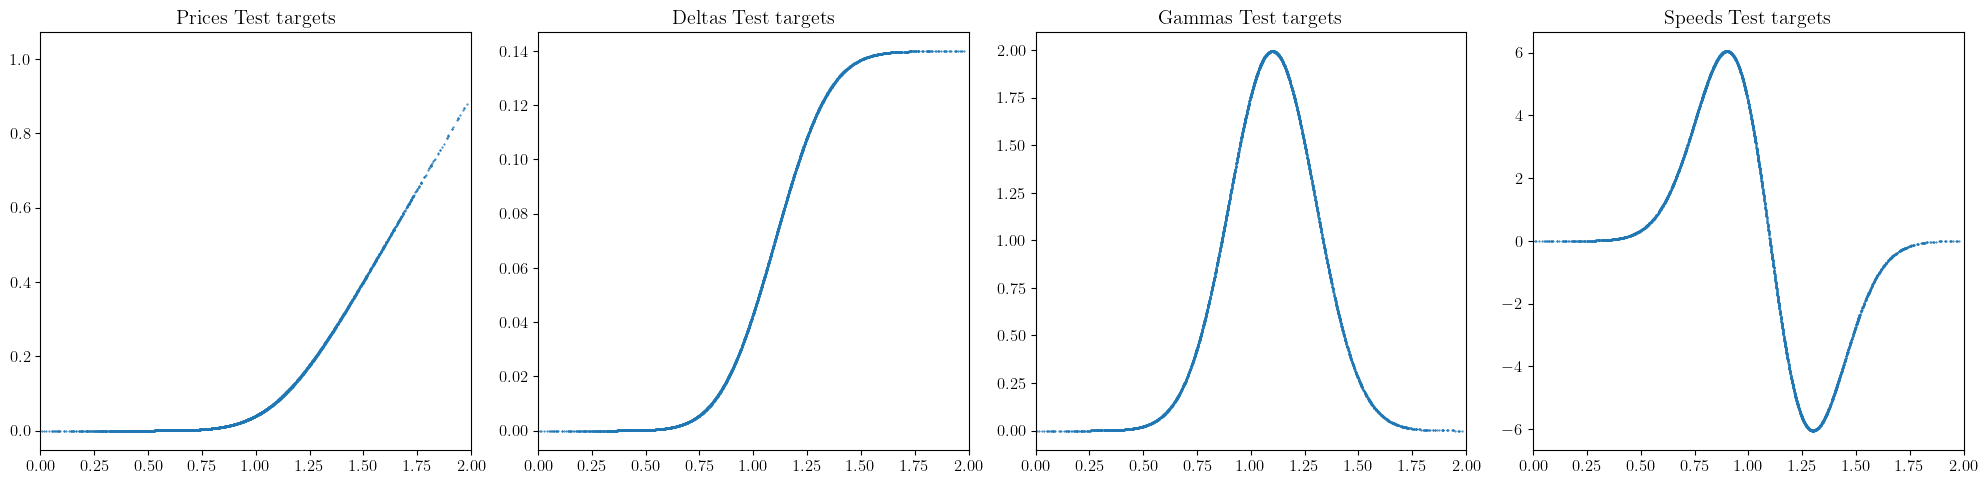

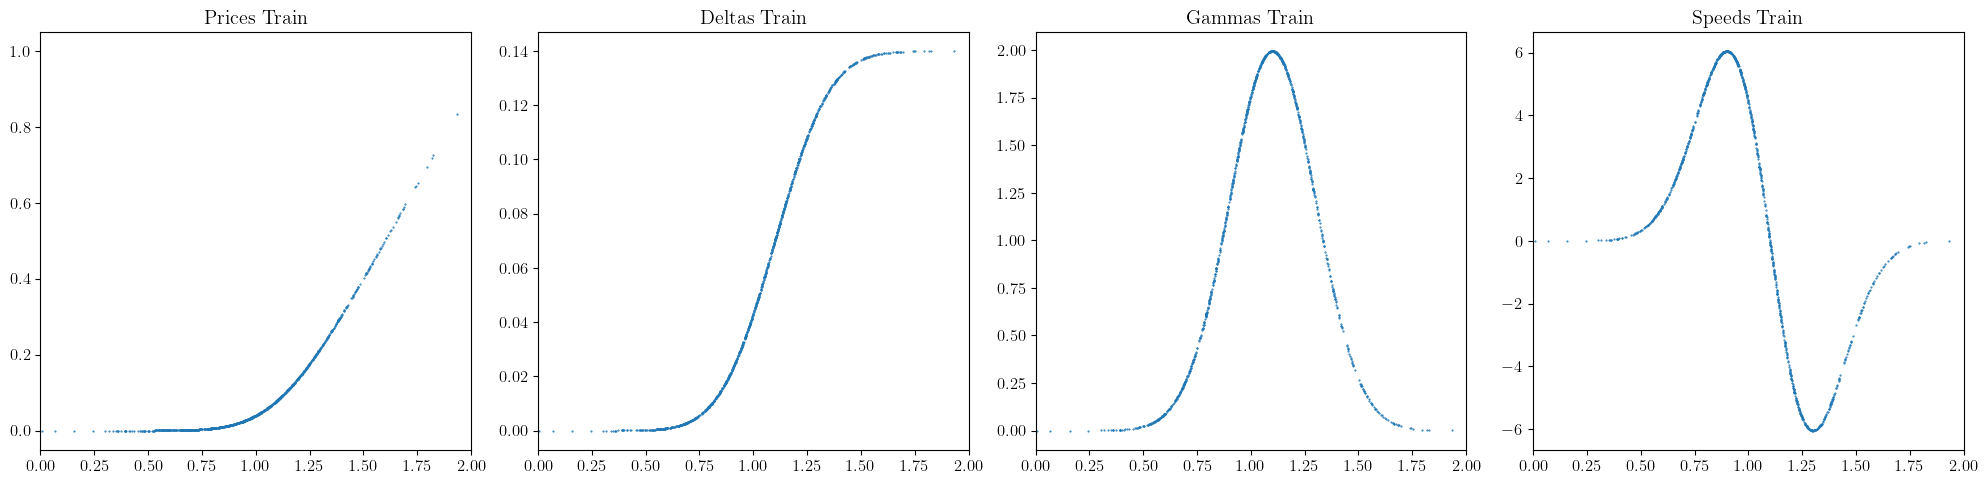

In [5]:
ref_model.visualize_data(test_set, name="Test targets")
ref_model.visualize_data(train_sample_batch, name="Train")


In [11]:




#variant = "value"
#variant = "1st"
#variant = "random"
#variant = "pcady"
#variant = "batchSVD"
variant = "3rdBatchSVD"
#variant = "perXSVD"
#variant = "streaming"
#variant = "fullHessian"
#variant = "3rdBatchSVD"

learnable_loss_weights = True
k = 6
streaming_r = 10

oversamppling_p = streaming_r - k
power_iteration_q = 0


n_epochs = 100#300  # 200 for Heston single asset convergence
n_batches_per_epoch = 32#64#32#32#8#32#32 # 32
BATCH_SIZE = 16#128#256#256#16#256#256 # 256
key = jrandom.PRNGKey(42)



# nn model
input_dims = ref_model.n_dims
key, subkey = jax.random.split(key)
mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
mlp = init_linear_weight(mlp, trunc_init, subkey)
surrogate_model = mlp



if variant == "streaming":
    # sketch
    key, subkey = jax.random.split(key)
    sketch = StreamingHessianSketch(
                ref_model=ref_model,
                r=streaming_r,
                k=k, 
                key=subkey)
else:
    sketch = None


optim = optax.adam(learning_rate=1e-3)



weighted_model, iteration_datas, sketch, avg_time_per_batch = train(
                        model = surrogate_model, 
                        test_data=test_set,
                        optim=optim, 
                        n_epochs=n_epochs,
                        n_batches_per_epoch=n_batches_per_epoch,
                        batch_size=BATCH_SIZE,
                        ref_model=ref_model,
                        sketch=sketch,
                        variant=variant,
                        k=k,
                        p=oversamppling_p,
                        q=power_iteration_q,
                        learnable_loss_weights=learnable_loss_weights
                        )


Training for 100 epochs with 32 batches per epoch and batch size 16.
Finished epoch 1 | Train Loss: 0.02790 | Test Value Loss: 1.65136
Finished epoch 2 | Train Loss: -0.03782 | Test Value Loss: 1.01902
Finished epoch 3 | Train Loss: -0.10308 | Test Value Loss: 0.86586
Finished epoch 4 | Train Loss: -0.16790 | Test Value Loss: 0.82083
Finished epoch 5 | Train Loss: -0.23273 | Test Value Loss: 0.76223
Finished epoch 6 | Train Loss: -0.29760 | Test Value Loss: 0.72670
Finished epoch 7 | Train Loss: -0.36184 | Test Value Loss: 0.68887
Finished epoch 8 | Train Loss: -0.42589 | Test Value Loss: 0.65115
Finished epoch 9 | Train Loss: -0.48982 | Test Value Loss: 0.60661
Finished epoch 10 | Train Loss: -0.55369 | Test Value Loss: 0.57260
Finished epoch 11 | Train Loss: -0.61748 | Test Value Loss: 0.55288
Finished epoch 12 | Train Loss: -0.68122 | Test Value Loss: 0.53889
Finished epoch 13 | Train Loss: -0.74495 | Test Value Loss: 0.52740
Finished epoch 14 | Train Loss: -0.80867 | Test Value Los

In [12]:
from diff_ml.utils import rmse
# eval price predictions
test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(weighted_model))(test_set.x)

test_pred_ddys = vmap(jax.hessian(MakeScalar(weighted_model)))(test_set.x)
test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)


if test_set.dddy is not None:
    test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(weighted_model))))(test_set.x)
    test_pred_dddys = test_pred_dddys.reshape(test_set.dddy.shape)


print("Test predictions shapes:")
print("test_pred_ys shape: ", test_pred_ys.shape)
print("test_pred_dys shape: ", test_pred_dys.shape)
print("test_pred_ddys shape: ", test_pred_ddys.shape)
if test_set.dddy is not None:
    print("test_pred_dddys shape: ", test_pred_dddys.shape)

print("")

y_error = rmse(test_pred_ys, test_set.y)
dy_error = rmse(test_pred_dys, test_set.dy)
ddy_error = rmse(test_pred_ddys, test_set.ddy)
if test_set.dddy is not None:
    dddy_error = rmse(test_pred_dddys, test_set.dddy)

print(f"test y error: {y_error:.5f}")
print(f"test dy error: {dy_error:.5f}")
print(f"test ddy error: {ddy_error:.5f}")
if test_set.dddy is not None:
    print(f"test dddy error: {dddy_error:.5f}")



Test predictions shapes:
test_pred_ys shape:  (128,)
test_pred_dys shape:  (128, 196)
test_pred_ddys shape:  (128, 196, 196)

test y error: 0.40701
test dy error: 0.10265
test ddy error: 0.03560


In [ ]:
# value:
#test y error: 0.00563
#test dy error: 0.00839
#test ddy error: 0.01060

# 1st:
#test y error: 0.00279 0.00202
#test dy error: 0.00440
#test ddy error: 0.00636

# pcady:
#test y error: 0.00112
#test dy error: 0.00164
#test ddy error: 0.00235

# batchSVD:
#test y error: 0.00112
#test dy error: 0.00164
#test ddy error: 0.00235
# batchSVD analytic:
#test y error: 0.00024
#test dy error: 0.00033
#test ddy error: 0.00055
#test dddy error: 0.00085

# streaming:
#test y error: 0.00119
#test dy error: 0.00168
#test ddy error: 0.00241

# 3rd analytic
#test y error: 0.00047
#test dy error: 0.00031
#test ddy error: 0.00031
#test dddy error: 0.00033



# heston2
# batchSVD:
#test y error: 0.00243
#test dy error: 0.00236
#test ddy error: 0.00552
#test dddy error: 0.01347

# 3rd
#test y error: 0.00208
#test dy error: 0.00153
#test ddy error: 0.00342
#test dddy error: 0.00927


#test y error: 0.00019
#test dy error: 0.00015
#test ddy error: 0.00014
#test dddy error: 0.00018

#test y error: 0.00034
#test dy error: 0.00021
#test ddy error: 0.00011
#test dddy error: 0.00013

### balancing factors plot

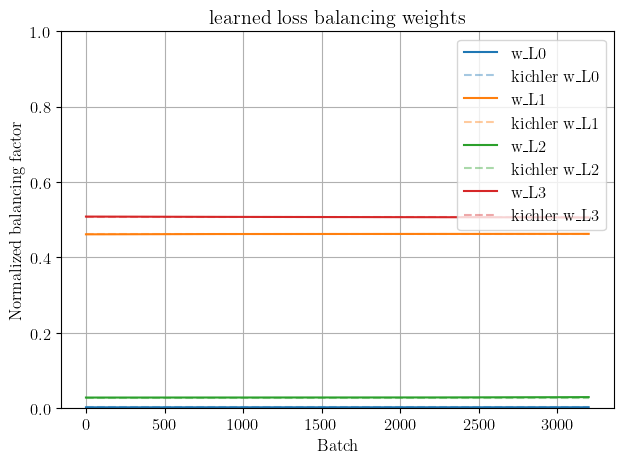

In [13]:
import matplotlib.pyplot as plt

# Kichler balancing factors (default settings, alpha=1, beta=2k/d^2) as reference
kichler_wL0 = 1
kichler_wL1 = ref_model.n_dims
kichler_wL2 = 2*k
kichler_wL3 = 6*(k**2)
c = 1 + ref_model.n_dims + 2*k
if variant == "3rdBatchSVD":
    c += 6*(k**2)
kichler_wLi = {
    0: kichler_wL0 / c,
    1: kichler_wL1 / c,
    2: kichler_wL2 / c,
    3: kichler_wL3 / c
}


ws = jnp.array([iteration_datas[t]["eff_w_norm"] for t in range(len(iteration_datas))])
active = (ws[0] != 0).astype(int)
ws = ws.T

for i, v in enumerate(active):
    if v:
        plt.plot(ws[i], label=f"w_L{i}")
        current_color = plt.gca().lines[-1].get_color()
        
        plt.hlines(y=kichler_wLi[i], xmin=0, xmax=len(ws[i]), linestyles='dashed', colors=current_color, label=f"kichler w_L{i}", alpha=0.4)
        

plt.xlabel("Batch")
plt.ylabel("Normalized balancing factor")
plt.ylim(0, 1)
#plt.ylim(0.33, 0.34)
plt.title("learned loss balancing weights")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



### loss plot

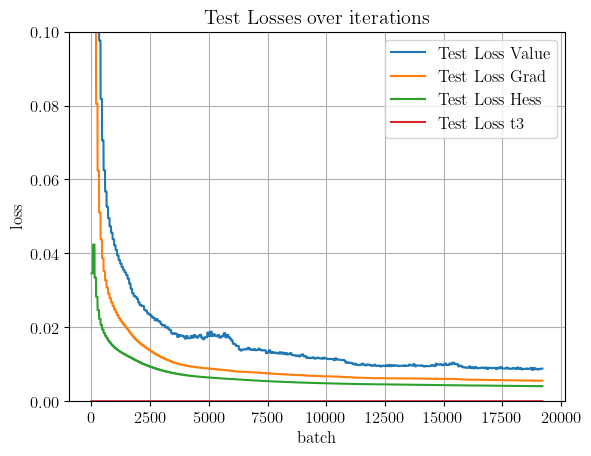

In [9]:
import matplotlib.pyplot as plt
test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
test_losses_t3 = jnp.array([iteration_datas[t]["test t3 loss"] for t in range(len(iteration_datas))])
test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])


x = range(len(test_losses_value))

#plt.plot(x, train_losses, label='Train Loss', alpha=0.2)#, linestyle='-', marker='o')
# Plot each of the three series
plt.plot(x, test_losses_value, label='Test Loss Value')#, linestyle='-', marker='o')
plt.plot(x, test_losses_grad, label='Test Loss Grad')#, linestyle='--', marker='s')
plt.plot(x, test_losses_hess, label='Test Loss Hess')#, linestyle=':', marker='^')
plt.plot(x, test_losses_t3, label='Test Loss t3')#, linestyle=':', marker='^')
#plt.plot(x, test_losses_proj_hess, label='Test Loss Proj Hess')#, linestyle=':', marker='^')

plt.ylim(0, 0.1)
# Add labels & title
plt.xlabel('batch')
plt.ylabel('loss')
plt.title('Test Losses over iterations')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()

### eval plots

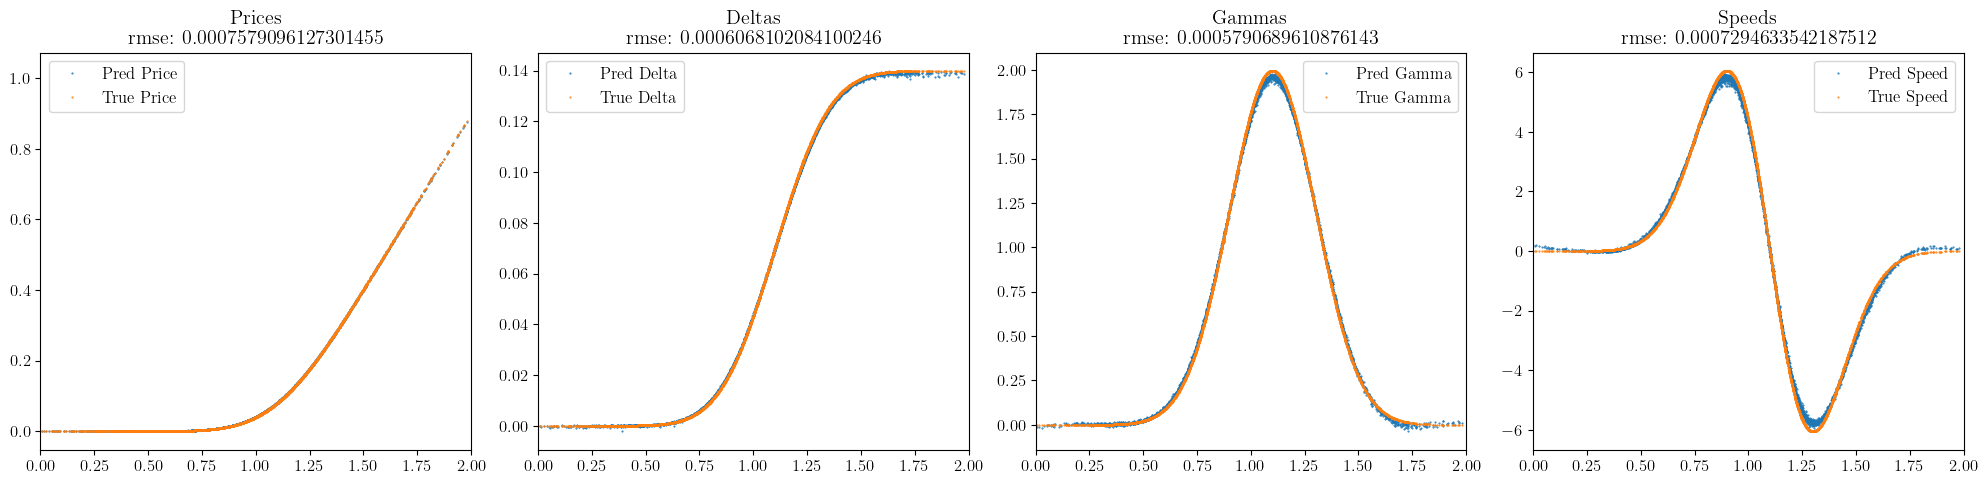

In [9]:
import matplotlib.pyplot as plt
    
ref_model.plot_eval(test_pred_ys, test_pred_dys, test_pred_ddys, test_pred_dddys, test_set)

# Averaged Runs

In [3]:
def make_MNIST(key, test_set_order=2):
    ref_model = MNIST_ref(
        key=key, 
        scale=0.5,
        target_class=9
    )
    test_set = ref_model.get_test_set(n_samples=128, order=test_set_order)
    return ref_model, test_set
    

def make_bachelier(key, test_set_order=2):
    
    basket_dim = 7
    ref_model = Bachelier(
        key,
        basket_dim=basket_dim, 
        weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    test_set = ref_model.get_test_set(n_samples=4*1024, order=test_set_order)
    return ref_model, test_set

def make_heston(key, do_test_eval=True, test_set_order=2):
    basket_dim = 30
    ref_model = Heston(
        key = key,
        basket_dim=basket_dim,
        basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    if not do_test_eval:
        test_set = None
    else:
        if test_set_order ==3:
            test_set = ref_model.get_test_set(n_samples=1*128, order=test_set_order)
        else:
            test_set = ref_model.get_test_set(n_samples=1*1024, order=test_set_order)
    #y_std = test_set[4]["y_std"]
    #ref_model.set_y_std(y_std)
    return ref_model, test_set
    
def make_analytic(key, test_set_order=2):
    ref_model = Analytic(
        key=key,
        #type="RHE",
        #type="Rastrigin",
        #type="Rosenbrock",
        #type="Ackley",
        type="CubicRankR",
        d=20,
        min_x=-1,
        max_x=1
    )
    #RHE: min_x = -5.0, max_x = 5.0
    ##Rastrigin: min_x = -5.12, max_x = 5.12
    #Rosenbrock: min_x = -1.5, max_x = 2.5
    #Ackley: min_x = -5.0, max_x = 5.0
    #CubicRankR: min_x = -1.0, max_x = 1.0

    test_set = ref_model.get_test_set(n_samples=8*1024, order=test_set_order)
    return ref_model, test_set

### evals (single seed)

running variant value
Training for 100 epochs with 64 batches per epoch and batch size 128.
Average execution time per batch: 0.00232s
Test predictions shapes:
test_pred_ys shape:  (4096,)
test_pred_dys shape:  (4096, 7)
test_pred_ddys shape:  (4096, 7, 7)
test_pred_dddys shape:  (4096, 7, 7, 7)

test y error: 0.01239
test dy error: 0.01005
test ddy error: 0.00862
test dddy error: 0.00893


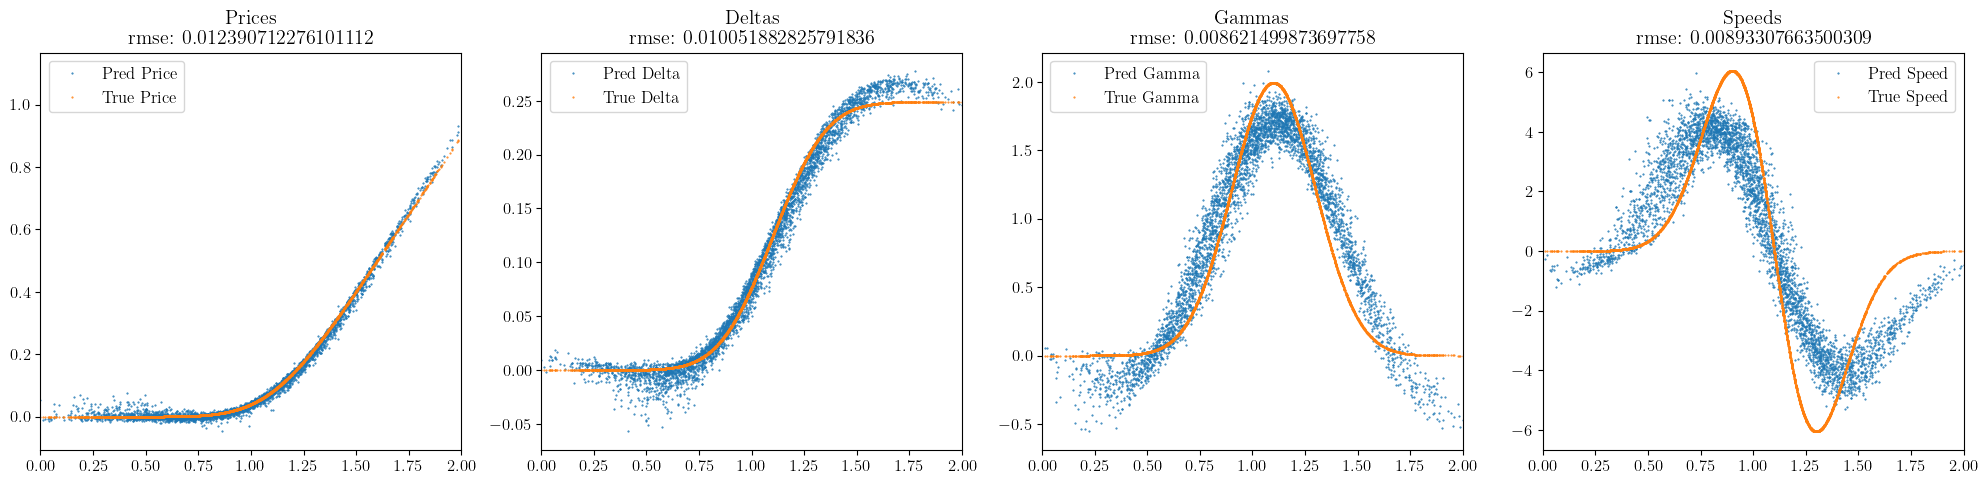

running variant 1st
Training for 100 epochs with 64 batches per epoch and batch size 128.
Average execution time per batch: 0.00240s
Test predictions shapes:
test_pred_ys shape:  (4096,)
test_pred_dys shape:  (4096, 7)
test_pred_ddys shape:  (4096, 7, 7)
test_pred_dddys shape:  (4096, 7, 7, 7)

test y error: 0.00697
test dy error: 0.00449
test ddy error: 0.00447
test dddy error: 0.00531


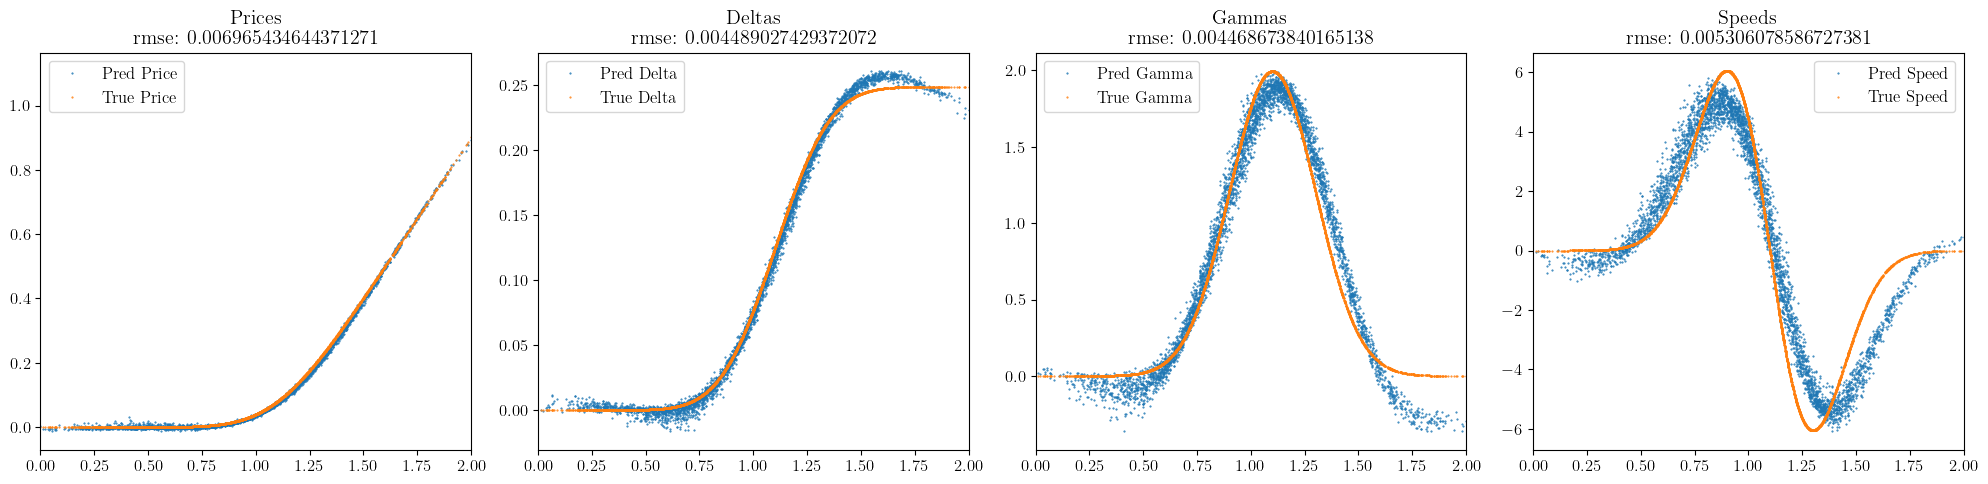

running variant random
Training for 100 epochs with 64 batches per epoch and batch size 128.
Average execution time per batch: 0.00244s
Test predictions shapes:
test_pred_ys shape:  (4096,)
test_pred_dys shape:  (4096, 7)
test_pred_ddys shape:  (4096, 7, 7)
test_pred_dddys shape:  (4096, 7, 7, 7)

test y error: 0.00500
test dy error: 0.00357
test ddy error: 0.00336
test dddy error: 0.00402


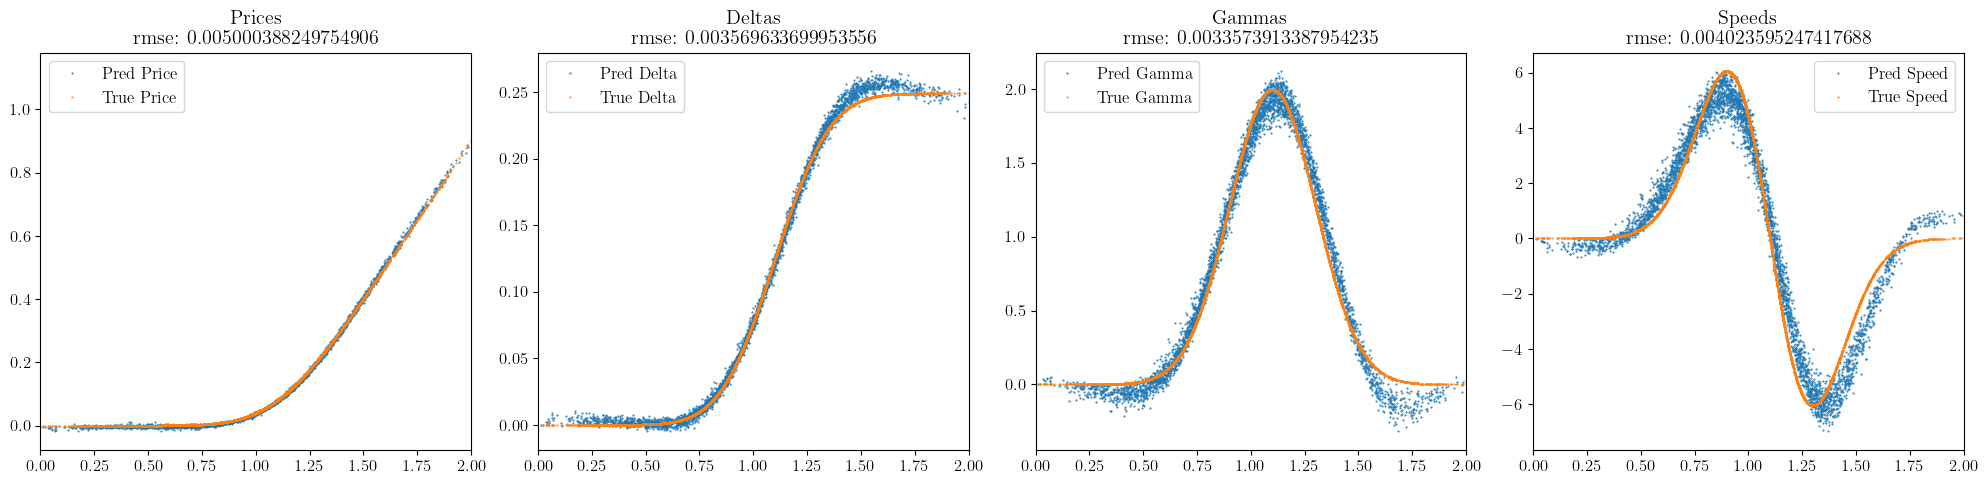

running variant pcady
Training for 100 epochs with 64 batches per epoch and batch size 128.
Average execution time per batch: 0.00356s
Test predictions shapes:
test_pred_ys shape:  (4096,)
test_pred_dys shape:  (4096, 7)
test_pred_ddys shape:  (4096, 7, 7)
test_pred_dddys shape:  (4096, 7, 7, 7)

test y error: 0.01087
test dy error: 0.00435
test ddy error: 0.00327
test dddy error: 0.00364


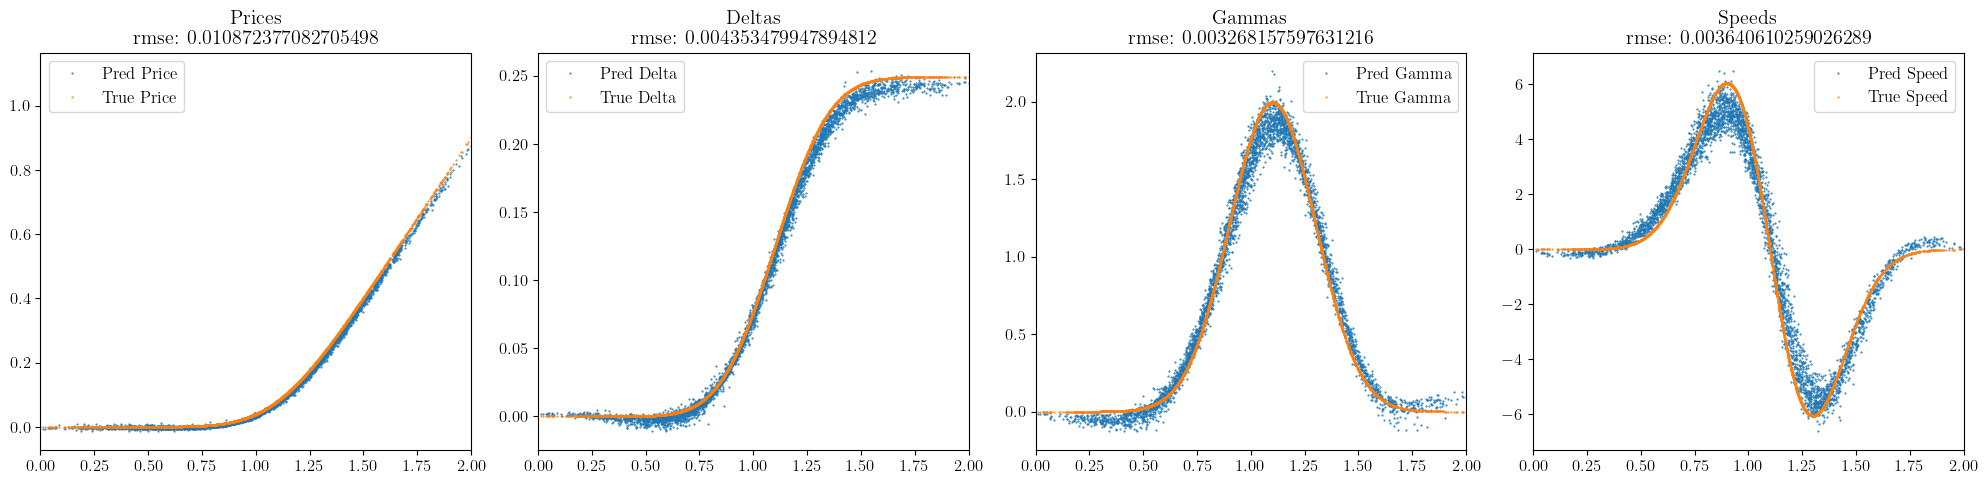

running variant batchSVD
Training for 100 epochs with 64 batches per epoch and batch size 128.
Average execution time per batch: 0.00329s
Test predictions shapes:
test_pred_ys shape:  (4096,)
test_pred_dys shape:  (4096, 7)
test_pred_ddys shape:  (4096, 7, 7)
test_pred_dddys shape:  (4096, 7, 7, 7)

test y error: 0.01077
test dy error: 0.00432
test ddy error: 0.00326
test dddy error: 0.00364


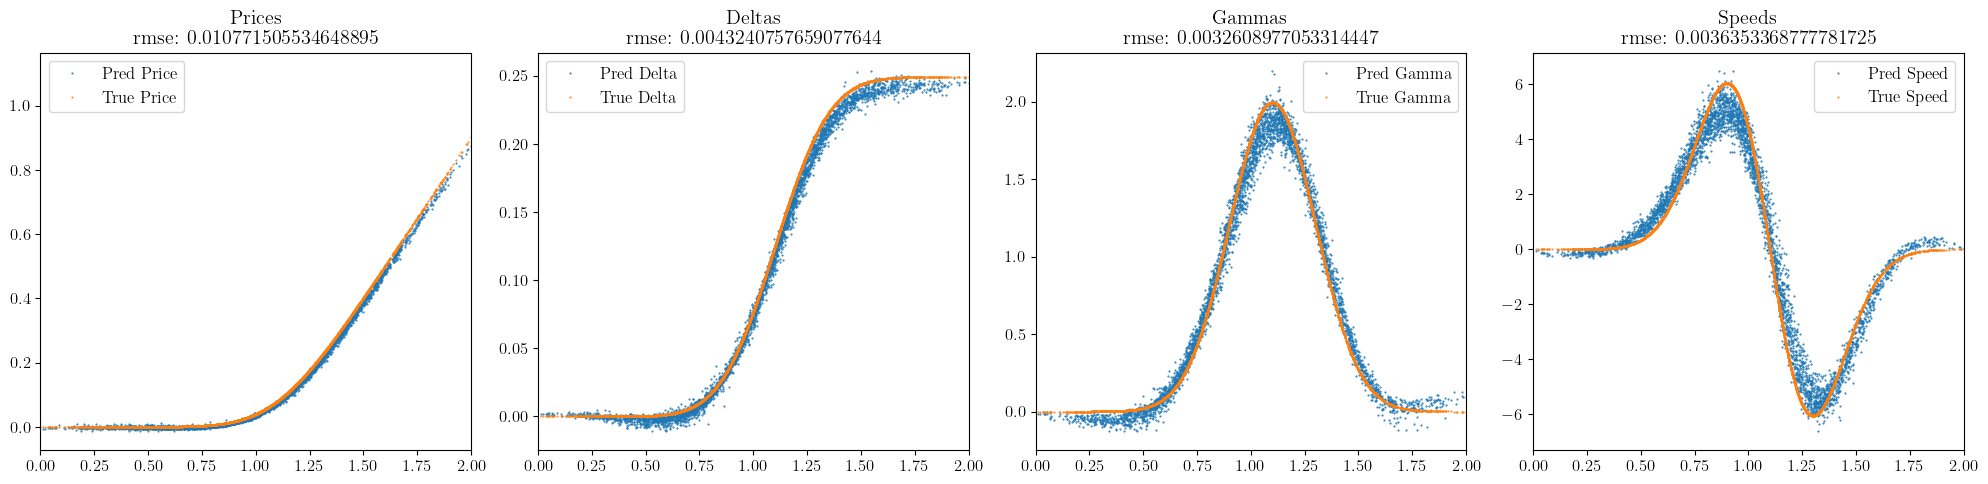

running variant streaming
Training for 100 epochs with 64 batches per epoch and batch size 128.
Average execution time per batch: 0.00348s
Test predictions shapes:
test_pred_ys shape:  (4096,)
test_pred_dys shape:  (4096, 7)
test_pred_ddys shape:  (4096, 7, 7)
test_pred_dddys shape:  (4096, 7, 7, 7)

test y error: 0.01142
test dy error: 0.00448
test ddy error: 0.00327
test dddy error: 0.00364


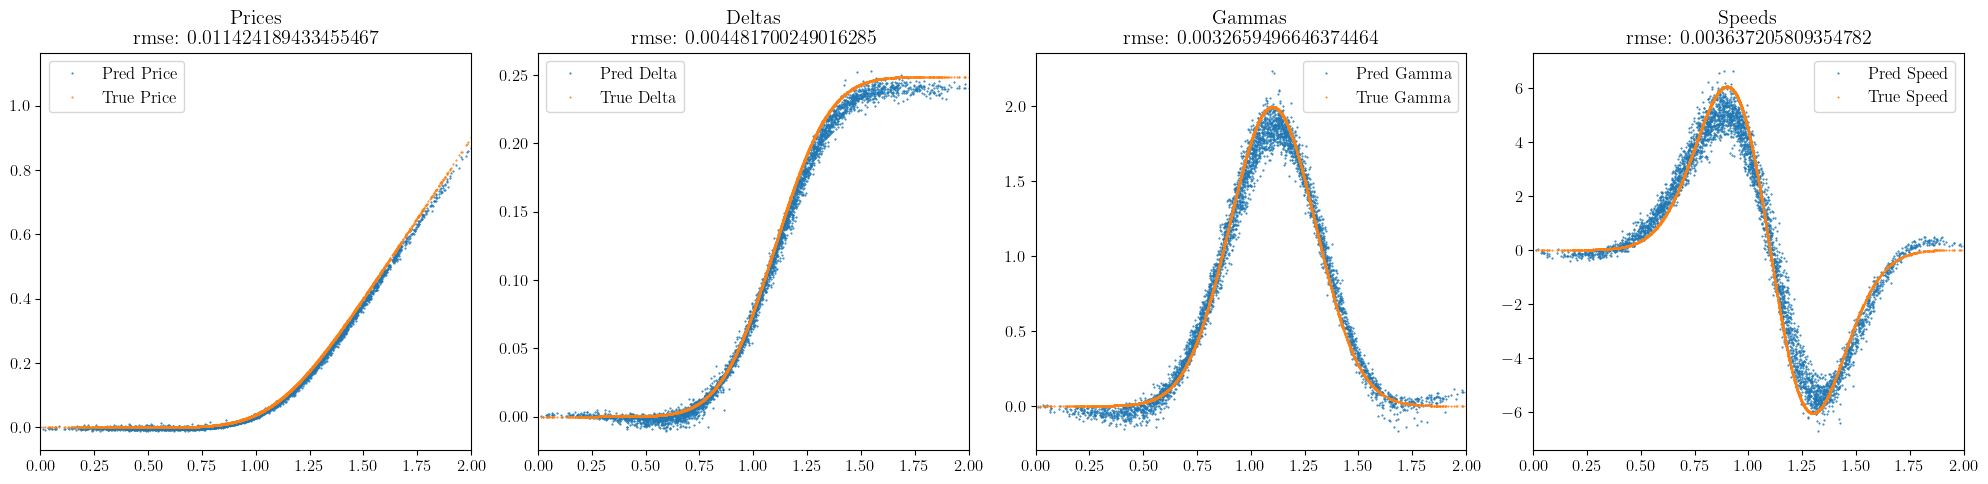

running variant fullHessian
Training for 100 epochs with 64 batches per epoch and batch size 128.
Average execution time per batch: 0.00245s
Test predictions shapes:
test_pred_ys shape:  (4096,)
test_pred_dys shape:  (4096, 7)
test_pred_ddys shape:  (4096, 7, 7)
test_pred_dddys shape:  (4096, 7, 7, 7)

test y error: 0.00723
test dy error: 0.00323
test ddy error: 0.00286
test dddy error: 0.00353


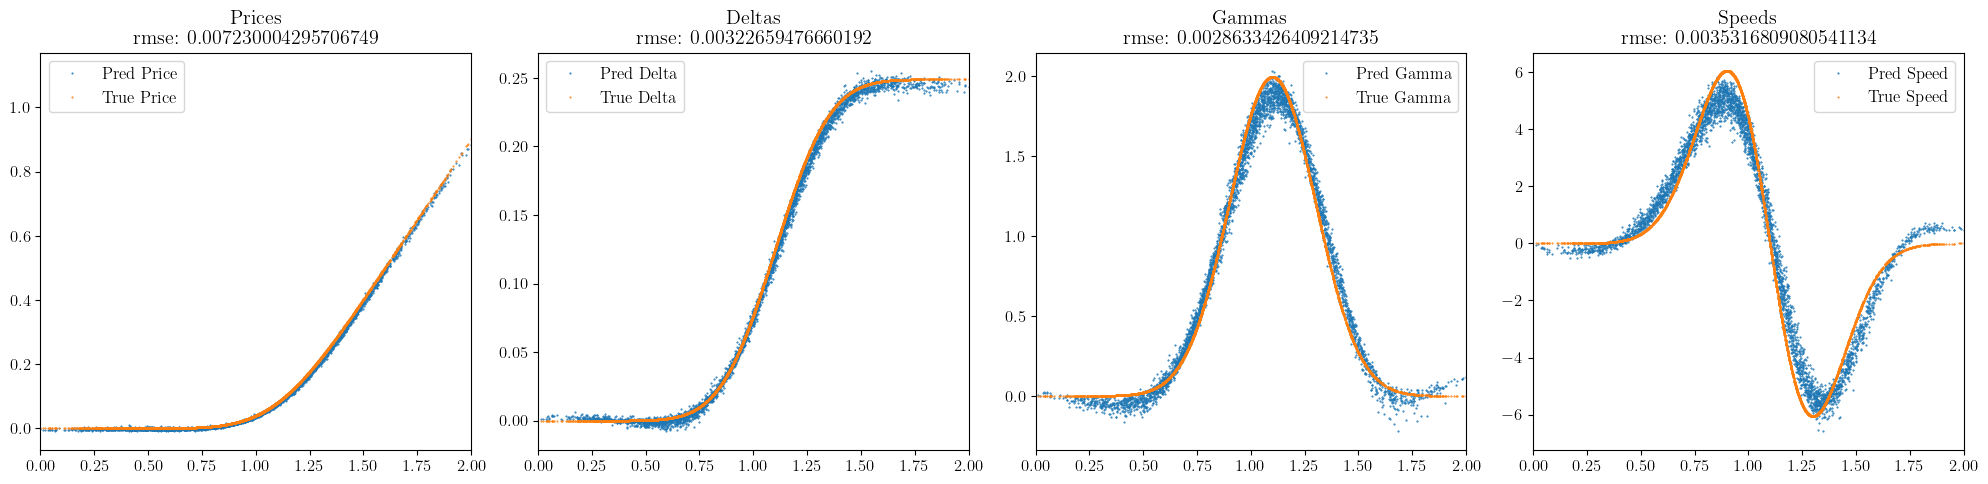

running variant 3rdBatchSVD
Training for 100 epochs with 64 batches per epoch and batch size 128.
Average execution time per batch: 0.00325s
Test predictions shapes:
test_pred_ys shape:  (4096,)
test_pred_dys shape:  (4096, 7)
test_pred_ddys shape:  (4096, 7, 7)
test_pred_dddys shape:  (4096, 7, 7, 7)

test y error: 0.03357
test dy error: 0.02571
test ddy error: 0.02311
test dddy error: 0.02232


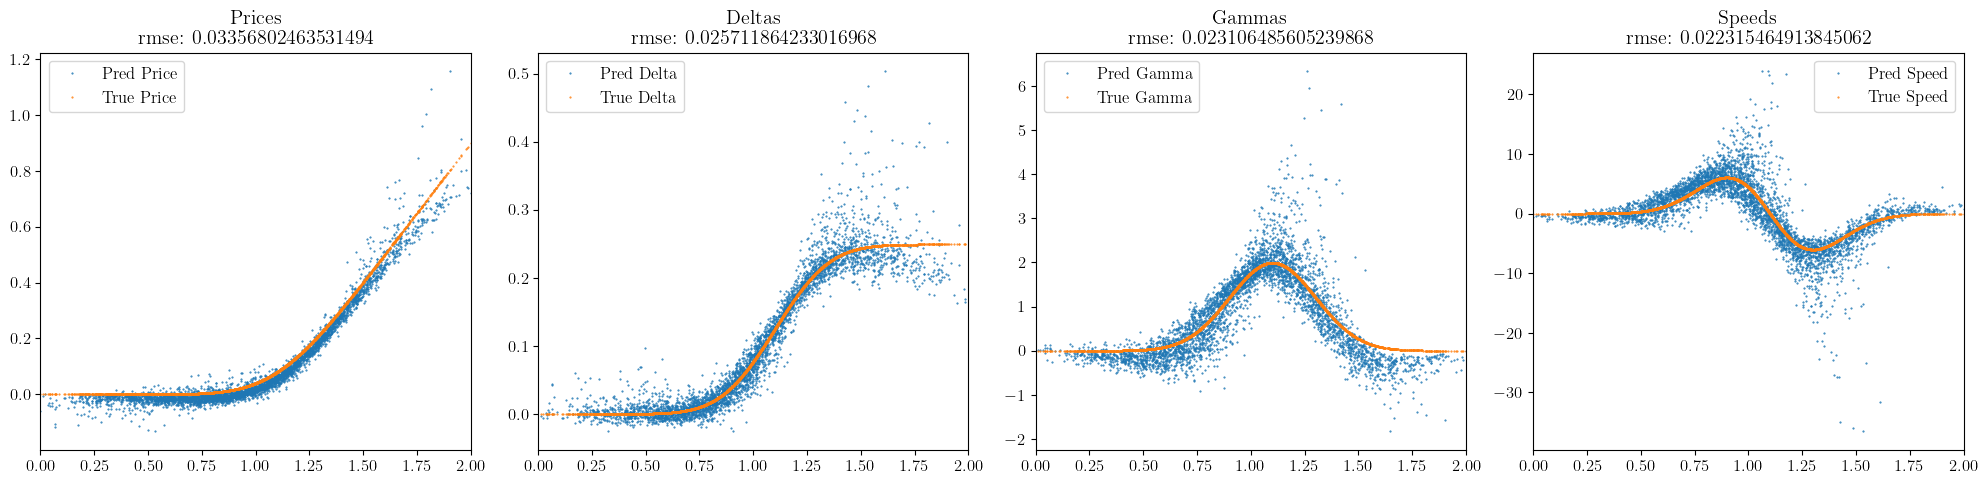

In [5]:
main_key = jrandom.PRNGKey(42)


n_epochs = 100
n_batches_per_epoch = 64#32#8#32 # 32
BATCH_SIZE = 128#256#16 #256 # 256

lr = 1e-3


k = 1
streaming_r = 2

oversamppling_p = streaming_r - k
power_iteration_q = 0


test_set_order = 3
learnable_loss_weights = False

do_approx_metrics = False # set to False for accurate time per batch measurement
do_test_eval = False



data = {}
#for variant in ["batchSVD"]:
for variant in ["value", "1st", "random", "pcady", "batchSVD", "streaming", "fullHessian", "3rdBatchSVD"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    print("running variant", variant)
    
 

    # reference model
    key, subkey = jax.random.split(main_key)

    ref_model, test_set = make_bachelier(key, test_set_order)
    #ref_model, test_set = make_heston(key, do_test_eval)
    #ref_model, test_set = make_MNIST(key)
    #ref_model, test_set = make_analytic(key)


    
    
    # nn model
    key, subkey = jax.random.split(key)
    input_dims = ref_model.n_dims
    mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
    mlp = init_linear_weight(mlp, trunc_init, subkey)
    surrogate_model = mlp
    
    # sketch
    sketch = None
    if variant == "streaming":
        key, subkey = jax.random.split(key)
        sketch = StreamingHessianSketch(
                    ref_model=ref_model,
                    r=streaming_r,
                    k=k, 
                    key=subkey)
    
    
    
    optim = optax.adam(learning_rate=lr)
    
    
    surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                            model = surrogate_model, 
                            test_data=test_set,
                            optim=optim, 
                            n_epochs=n_epochs,
                            n_batches_per_epoch=n_batches_per_epoch,
                            batch_size=BATCH_SIZE,
                            ref_model=ref_model,
                            sketch=sketch,
                            variant=variant,
                            k=k,
                            p=oversamppling_p,
                            q=power_iteration_q,
                            learnable_loss_weights=learnable_loss_weights,
                            do_approx_metrics=do_approx_metrics,
                            do_test_eval=do_test_eval
                            )
    

    from diff_ml.utils import rmse
    # eval price predictions
    test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_set.x)
    test_pred_ddys = vmap(jax.hessian(MakeScalar(surrogate_model)))(test_set.x)
    test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)
    test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(surrogate_model))))(test_set.x)
    test_pred_dddys = test_pred_dddys.reshape(test_set.dddy.shape)

    print("Test predictions shapes:")
    print("test_pred_ys shape: ", test_pred_ys.shape)
    print("test_pred_dys shape: ", test_pred_dys.shape)
    print("test_pred_ddys shape: ", test_pred_ddys.shape)
    print("test_pred_dddys shape: ", test_pred_dddys.shape)

    print("")
    y_error = rmse(test_pred_ys, test_set.y)
    dy_error = rmse(test_pred_dys, test_set.dy)
    ddy_error = rmse(test_pred_ddys, test_set.ddy)
    dddy_error = rmse(test_pred_dddys, test_set.dddy)

    print(f"test y error: {y_error:.5f}")
    print(f"test dy error: {dy_error:.5f}")
    print(f"test ddy error: {ddy_error:.5f}")
    print(f"test dddy error: {dddy_error:.5f}")

    ref_model.plot_eval(test_pred_ys, test_pred_dys, test_pred_ddys, test_pred_dddys, test_set)
    plt.show()
        





### losses

In [ ]:
main_key = jrandom.PRNGKey(42)

# averaging over n seeds
n_runs = 10

n_epochs = 300#200 
n_batches_per_epoch = 64#64#32#32#8#32 # 32
BATCH_SIZE = 128#256#16 #256 # 256

lr = 1e-3


k = 1
streaming_r = 2


oversamppling_p = streaming_r - k
power_iteration_q = 0


test_set_order = 3
learnable_loss_weights = True
do_approx_metrics = False # set to False for accurate time per batch measurement
do_test_eval = True



data = {}
#for variant in ["3rdBatchSVD"]:
for variant in ["value", "1st", "random", "pcady", "batchSVD", "streaming", "fullHessian", "3rdBatchSVD"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    print("running variant", variant)
    
    test_losses_values = []
    test_losses_grads = []
    test_losses_hessians = []
    test_losses_t3s = []
    avg_times = []
 

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        ref_model, test_set = make_bachelier(key, test_set_order)
        #ref_model, test_set = make_heston(key, do_test_eval, test_set_order)
        #ref_model, test_set = make_MNIST(key)
        #ref_model, test_set = make_analytic(key)


        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        ref_model=ref_model,
                        r=streaming_r,
                        k=k, 
                        key=subkey)
        
        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k,
                                p=oversamppling_p,
                                q=power_iteration_q,
                                learnable_loss_weights=learnable_loss_weights,
                                do_approx_metrics=do_approx_metrics,
                                do_test_eval=do_test_eval
                                )
        
        test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
        test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
        test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
        test_losses_t3 = jnp.array([iteration_datas[t]["test t3 loss"] for t in range(len(iteration_datas))])
        #test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
        #train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])


    
        test_losses_values.append(test_losses_value)
        test_losses_grads.append(test_losses_grad)
        test_losses_hessians.append(test_losses_hess)
        test_losses_t3s.append(test_losses_t3)
        avg_times.append(avg_time_per_batch)

        

    # average the runs
    print("")
    test_losses_values = jnp.array(test_losses_values)
    test_losses_grads = jnp.array(test_losses_grads)
    test_losses_hessians = jnp.array(test_losses_hessians)
    test_losses_t3s = jnp.array(test_losses_t3s)

    test_losses_values_mean = test_losses_values.mean(axis=0)
    test_losses_values_std = test_losses_values.std(axis=0)
    test_losses_grads_mean = test_losses_grads.mean(axis=0)
    test_losses_grads_std = test_losses_grads.std(axis=0)
    test_losses_hessians_mean = test_losses_hessians.mean(axis=0)
    test_losses_hessians_std = test_losses_hessians.std(axis=0)
    test_losses_t3s_mean = test_losses_t3s.mean(axis=0)
    test_losses_t3s_std = test_losses_t3s.std(axis=0)

    avg_times_mean = jnp.mean(jnp.array(avg_times))

        


    data[variant] = {
        "test_losses_values": (test_losses_values_mean, test_losses_values_std),
        "test_losses_grads": (test_losses_grads_mean, test_losses_grads_std),
        "test_losses_hessians": (test_losses_hessians_mean, test_losses_hessians_std),
        "test_losses_t3s": (test_losses_t3s_mean, test_losses_t3s_std),
        "avg_time_per_batch": avg_times_mean
    }

    



running variant value

run 1 / 10 for value
Training for 300 epochs with 64 batches per epoch and batch size 128.
Finished epoch 1 | Train Loss: 0.03354 | Test Value Loss: 0.26551
Finished epoch 2 | Train Loss: -0.02925 | Test Value Loss: 0.14277
Finished epoch 3 | Train Loss: -0.06215 | Test Value Loss: 0.13632
Finished epoch 4 | Train Loss: -0.09454 | Test Value Loss: 0.12803
Finished epoch 5 | Train Loss: -0.12670 | Test Value Loss: 0.11647
Finished epoch 6 | Train Loss: -0.15880 | Test Value Loss: 0.10383
Finished epoch 7 | Train Loss: -0.19090 | Test Value Loss: 0.09125
Finished epoch 8 | Train Loss: -0.22299 | Test Value Loss: 0.07940
Finished epoch 9 | Train Loss: -0.25503 | Test Value Loss: 0.06909
Finished epoch 10 | Train Loss: -0.28710 | Test Value Loss: 0.06163
Finished epoch 11 | Train Loss: -0.31915 | Test Value Loss: 0.05338
Finished epoch 12 | Train Loss: -0.35120 | Test Value Loss: 0.04719
Finished epoch 13 | Train Loss: -0.38323 | Test Value Loss: 0.04478
Finished epo

In [ ]:
# final errors and std deviations
for variant in data.keys():
    print(f"Variant: {variant}")
    avg_time = data[variant]["avg_time_per_batch"]
    print(f"  avg time per batch: {avg_time*1000:.2f} ms")
    
    for order, name in zip(
        ["test_losses_values", "test_losses_grads", "test_losses_hessians", "test_losses_t3s"],
        ["value", "1st-order", "2nd-order", "3rd-order"]
    ):
        final_loss_mean, final_loss_std = data[variant][order]
        final_loss_mean = final_loss_mean[-1]
        final_loss_std = final_loss_std[-1]
        print(f"  final {name} loss: {final_loss_mean:.6f} ± {final_loss_std:.6f}")
    print("")

Variant: value
  avg time per batch: 2.36 ms
  final value loss: 0.019083 ± 0.002307
  final 1st-order loss: 0.015184 ± 0.001614
  final 2nd-order loss: 0.011719 ± 0.001129
  final 3rd-order loss: 0.007678 ± 0.000475

Variant: 1st
  avg time per batch: 2.43 ms
  final value loss: 0.015174 ± 0.001905
  final 1st-order loss: 0.011350 ± 0.001125
  final 2nd-order loss: 0.008916 ± 0.000776
  final 3rd-order loss: 0.006538 ± 0.000449

Variant: random
  avg time per batch: 2.56 ms
  final value loss: 0.013617 ± 0.002186
  final 1st-order loss: 0.009829 ± 0.001145
  final 2nd-order loss: 0.007486 ± 0.000673
  final 3rd-order loss: 0.005776 ± 0.000427

Variant: pcady
  avg time per batch: 3.50 ms
  final value loss: 0.013804 ± 0.002422
  final 1st-order loss: 0.010032 ± 0.001231
  final 2nd-order loss: 0.007567 ± 0.000812
  final 3rd-order loss: 0.005463 ± 0.000480

Variant: batchSVD
  avg time per batch: 3.68 ms
  final value loss: 0.013305 ± 0.002273
  final 1st-order loss: 0.009495 ± 0.0009

In [ ]:
from matplotlib import cm

colors = cm.tab10.colors

#colors = plt.cm.rainbow(np.linspace(0, 0.85, 7))  # 7 variants

# reverse
#colors = colors[::-1]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)


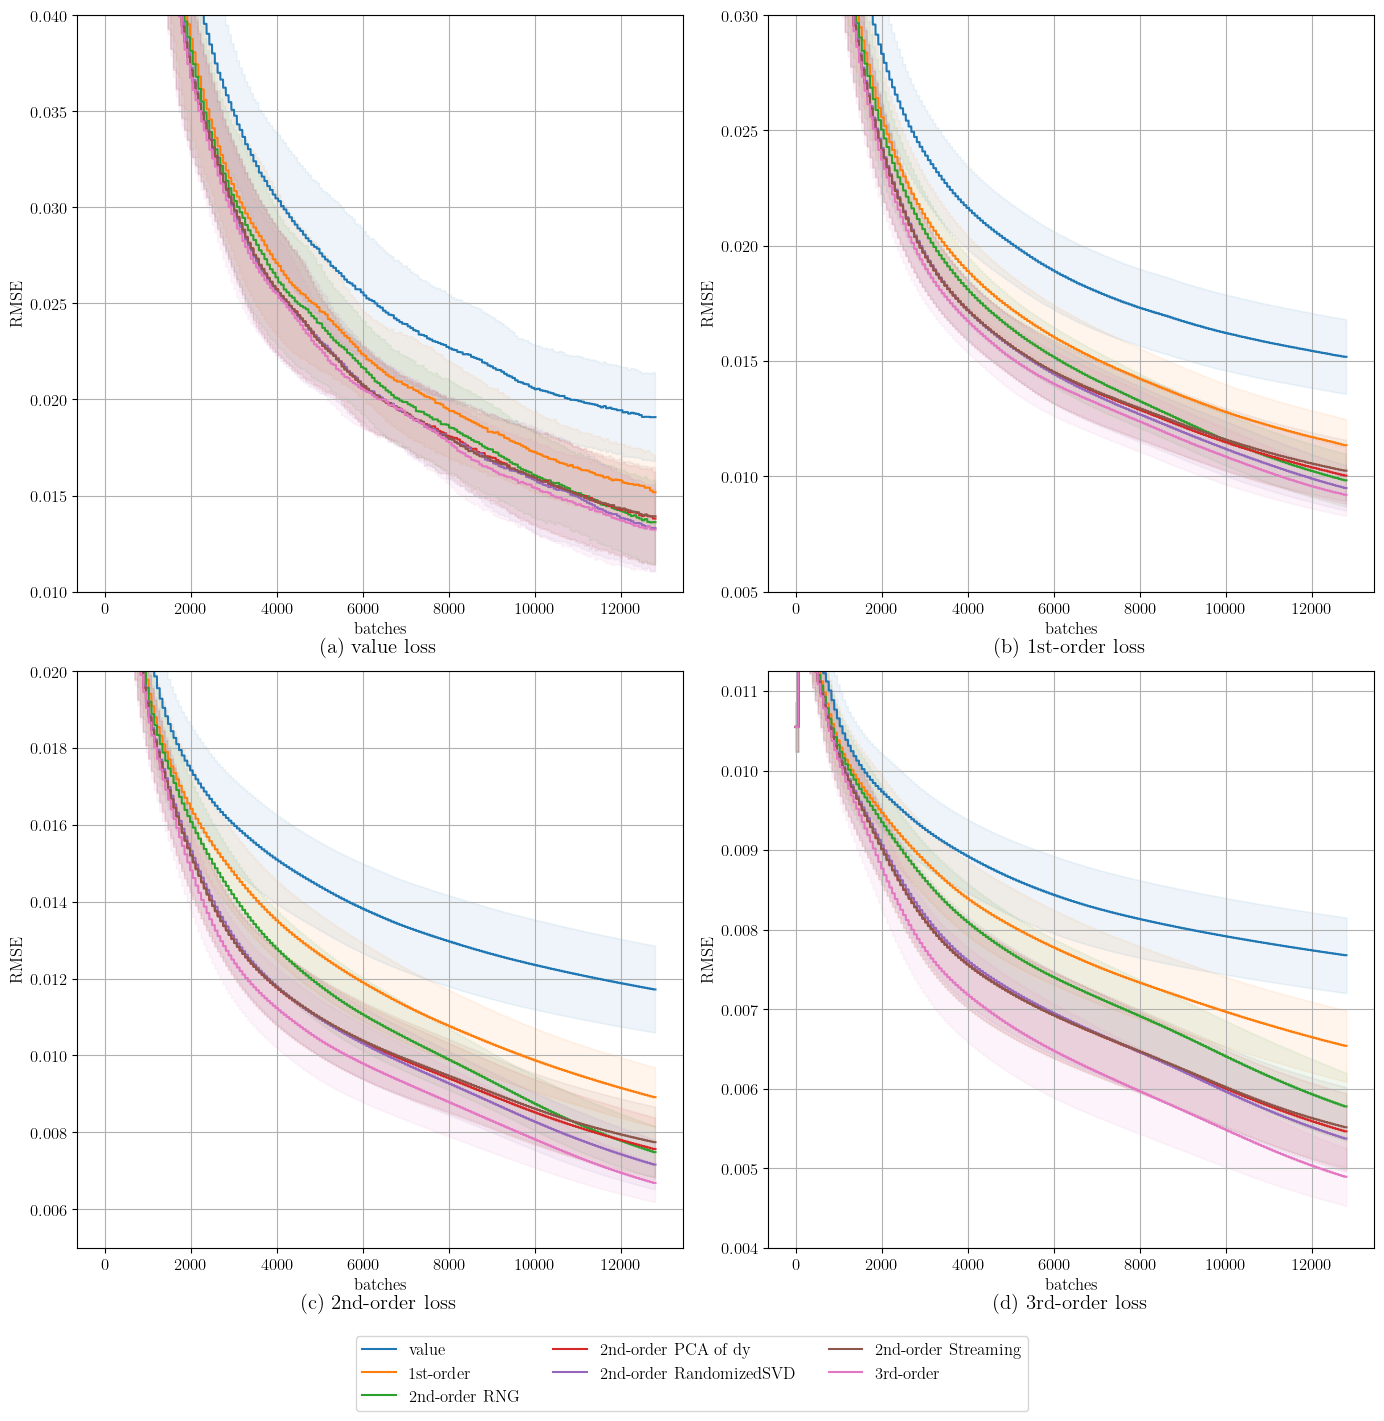

In [ ]:
import matplotlib.pyplot as plt

epoch_cap = -1

orders = ["values", "grads", "hessians", "t3s"]

order_names = {
    "values": "(a) value",
    "grads": "(b) 1st-order",
    "hessians": "(c) 2nd-order",
    "t3s": "(d) 3rd-order"
}

order_ylims = {
    "values": (0.01, 0.04),
    "grads": (0.005, 0.03),
    "hessians": (0.005, 0.02),
    "t3s": (0.004, 0.01125)
}

variant_names = {
    "value": "value",
    "1st": "1st-order",
    "random": "2nd-order RNG",
    "pcady": "2nd-order PCA of dy",
    "batchSVD": "2nd-order RandomizedSVD",
    "streaming": "2nd-order Streaming",
    "3rdBatchSVD": "3rd-order"
}

variants = ["value", "1st", "random", "pcady", "batchSVD", "streaming", "3rdBatchSVD"]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

handles = []  # for collecting legend entries

for ax, order in zip(axes, orders):
    for variant in variants:
        results = data[variant]

        mean = results[f"test_losses_{order}"][0][:epoch_cap]
        std  = results[f"test_losses_{order}"][1][:epoch_cap]
        x = range(len(mean))

        # plot line
        line, = ax.plot(x, mean, label=variant_names[variant])

        # shaded std band
        ax.fill_between(
            x, mean - std, mean + std,
            color=line.get_color(),
            alpha=0.075
        )

        # Store handle for legend only once
        if order == "values":
            handles.append(line)

    ax.set_title(f"{order_names[order]} loss", y=-0.12, fontsize=15)
    ax.set_xlabel("batches")
    ax.set_ylabel("RMSE")
    ax.set_ylim(*order_ylims[order])
    ax.grid(True)
    #ax.grid(axis='y', linestyle='--', alpha=0.7)
    

# Shared legend under all plots
fig.legend(
    handles,
    [variant_names[v] for v in variants],
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()


In [ ]:
import time
now = time.strftime("%d%m_%H:%M")
fig.savefig(f"res/losses_heston7_k2_r4_64_128_lb_{now}.pdf", bbox_inches='tight')

time per batch for value: 	0.00219s
time per batch for 1st: 	0.00232s
time per batch for random: 	0.00242s
time per batch for pcady: 	0.00358s
time per batch for batchSVD: 	0.00340s
time per batch for streaming: 	0.00365s
time per batch for fullHessian: 	0.00239s


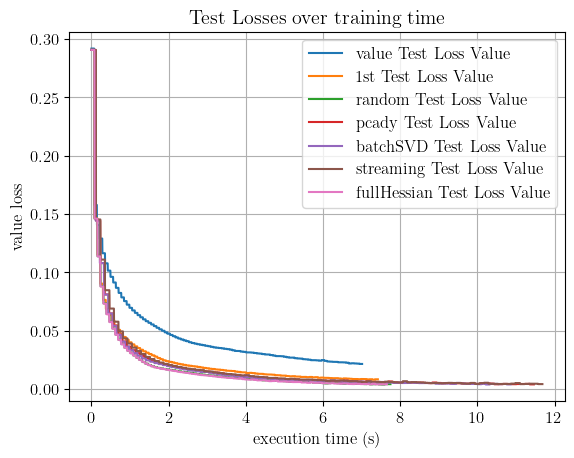

In [ ]:
for variant in ["value", "1st", "random", "pcady", "batchSVD", "streaming", "fullHessian"]:
    results = data[variant]
    test_losses_value_mean = results["test_losses_values"][0][:epoch_cap]
    time_per_batch = results["avg_time_per_batch"]
    print(f"time per batch for {variant}: \t{time_per_batch:.5f}s")

    # Scale x-axis by execution time
    x = [i * time_per_batch for i in range(len(test_losses_value_mean))]

    plt.plot(x, test_losses_value_mean, label=f"{variant} Test Loss Value")
    


# Add labels & title
plt.xlabel('execution time (s)')
plt.ylabel('value loss')
plt.title('Test Losses over training time')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()


### all variants

In [ ]:
main_key = jrandom.PRNGKey(42)


n_runs = 10

n_epochs = 100  # 200 for Heston single asset convergence
n_batches_per_epoch = 64#8#4#32#8#32 # 32
BATCH_SIZE = 128#16#8#256#16 #256 # 256

lr = 1e-3


k = 1
streaming_r = 2

oversamppling_p = streaming_r - k
power_iteration_q = 0


test_set_order = 3
learnable_loss_weights = True
do_approx_metrics = True
do_test_eval = True



data = {}
#for variant in ["batchSVD"]:
#for variant in ["streaming"]:
#for variant in ["3rdBatchSVD"]:
#for variant in ["perXSVD"]:
for variant in ["value", "1st", "random", "pcady", "batchSVD", "streaming", "fullHessian"]:#, "3rdBatchSVD"]:
    print("running variant", variant)
    
    y_errors = []
    dy_errors = []
    ddy_errors = []
    dddy_errors = []
    eFs = []
    e2s = []
    evrs = []
    engs = []
    avg_t_p_bs = []

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        ref_model, test_set = make_bachelier(key=key, test_set_order=test_set_order)
        #ref_model, test_set = make_heston(key, test_set_order=test_set_order)
        #ref_model, test_set = make_analytic(key, test_set_order=test_set_order)
        #ref_model, test_set = make_MNIST(key, test_set_order=test_set_order)
        

        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=4, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        ref_model=ref_model,
                        r=streaming_r,
                        k=k, 
                        key=subkey)
        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k,
                                p=oversamppling_p,
                                q=power_iteration_q,
                                learnable_loss_weights=learnable_loss_weights,
                                do_approx_metrics=do_approx_metrics,
                                do_test_eval=do_test_eval
                                )
        
    
        
        # eval price predictions
        test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_set.x)
        test_pred_ddys = vmap(jax.hessian(MakeScalar(surrogate_model)))(test_set.x)
        test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)



        y_error = jnp.sqrt(mse(test_pred_ys, test_set.y))
        dy_error = jnp.sqrt(mse(test_pred_dys, test_set.dy))
        ddy_error = jnp.sqrt(mse(test_pred_ddys, test_set.ddy))

        if test_set_order > 2:
            test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(surrogate_model))))(test_set.x)
            dddy_error = jnp.sqrt(mse(test_pred_dddys, test_set.dddy))        
        else:
            dddy_error = jnp.nan

        y_errors.append(y_error)
        dy_errors.append(dy_error)
        ddy_errors.append(ddy_error)
        dddy_errors.append(dddy_error)
        print(f"test y error: {y_error:.5f}")
        print(f"test dy error: {dy_error:.5f}")
        print(f"test ddy error: {ddy_error:.5f}")
        if test_set_order > 2:
            print(f"test dddy error: {dddy_error:.5f}")
    
        #print(iteration_datas[0])
        if "approximation metrics ref" in iteration_datas[0]:
            epochs = list(range(len(iteration_datas)))
            eF_vals  = jnp.array([iteration_datas[t]["approximation metrics ref"]["eF mean"]  for t in epochs])
            e2_vals  = jnp.array([iteration_datas[t]["approximation metrics ref"]["e2 mean"]  for t in epochs])
            evr_vals = jnp.array([iteration_datas[t]["approximation metrics ref"]["evr mean"] for t in epochs])
            eng_vals = jnp.array([iteration_datas[t]["approximation metrics ref"]["eng mean"] for t in epochs])
            mean_eF  = jnp.nanmean(eF_vals)
            mean_e2  = jnp.nanmean(e2_vals)
            mean_evr = jnp.nanmean(evr_vals)
            mean_eng = jnp.nanmean(eng_vals)
        else:
            mean_eF  = 0.0
            mean_e2  = 0.0
            mean_evr = 0.0
            mean_eng = 0.0
        eFs.append(mean_eF)
        e2s.append(mean_e2)
        evrs.append(mean_evr)
        engs.append(mean_eng)
        print(f"eF: {mean_eF:.5f}")
        print(f"e2: {mean_e2:.5f}")
        print(f"evr: {mean_evr:.5f}")
        print(f"eng: {mean_eng:.5f}")
        avg_t_p_bs.append(avg_time_per_batch)
        print(f"avg time per batch: {avg_time_per_batch:.5f}")

    # average the runs
    print("")
    y_errors = jnp.array(y_errors)
    dy_errors = jnp.array(dy_errors)
    ddy_errors = jnp.array(ddy_errors)
    dddy_errors = jnp.array(dddy_errors)

    y_errors_mean = y_errors.mean()
    dy_errors_mean = dy_errors.mean()
    ddy_errors_mean = ddy_errors.mean()
    dddy_errors_mean = dddy_errors.mean()
    y_errors_std = y_errors.std()
    dy_errors_std = dy_errors.std()
    ddy_errors_std = ddy_errors.std()
    dddy_errors_std = dddy_errors.std()

    print(f"y errors: \tmean: {y_errors_mean:.5f} \tstd: {y_errors_std:.5f}")
    print(f"dy errors: \tmean: {dy_errors_mean:.5f} \tstd: {dy_errors_std:.5f}")
    print(f"ddy errors: \tmean: {ddy_errors_mean:.5f} \tstd: {ddy_errors_std:.5f}")
    if test_set_order > 2:
        print(f"dddy errors: \tmean: {dddy_errors_mean:.5f} \tstd: {dddy_errors_std:.5f}")


    eFs = jnp.array(eFs)
    e2s = jnp.array(e2s)
    evrs = jnp.array(evrs)
    engs = jnp.array(engs)

    eFs_mean = eFs.mean()
    e2s_mean = e2s.mean()
    evrs_mean = evrs.mean()
    engs_mean = engs.mean()
    eFs_std = eFs.std()
    e2s_std = e2s.std()
    evrs_std = evrs.std()
    engs_std = engs.std()

    print(f"eFs: \tmean: {eFs_mean:.5f} \tstd: {eFs_std:.5f}")
    print(f"e2s: \tmean: {e2s_mean:.5f} \tstd: {e2s_std:.5f}")
    print(f"evrs: \tmean: {evrs_mean:.5f} \tstd: {evrs_std:.5f}")
    print(f"engs: \tmean: {engs_mean:.5f} \tstd: {engs_std:.5f}")

    avg_t_p_bs = jnp.array(avg_t_p_bs)


    print(f"avg time per batch: {avg_t_p_bs.mean():.5f}")



        


    data[variant] = {
        "y errors":   (y_errors_mean, y_errors_std),
        "dy errors":  (dy_errors_mean, dy_errors_std),
        "ddy errors": (ddy_errors_mean, ddy_errors_std),
        "dddy errors": (dddy_errors_mean, dddy_errors_std),
        "eFs":  (eFs_mean, eFs_std),
        "e2s":  (e2s_mean, e2s_std),
        "evrs": (evrs_mean, evrs_std),
        "engs": (engs_mean, engs_std),
        "avg time per batch": avg_t_p_bs.mean(),
    }

    



### formatting

In [ ]:
key_map = {
    "y errors": "y_error",
    "dy errors": "dy_error",
    "ddy errors": "ddy_error",
    "eFs": "eFs",
    "e2s": "e2s",
    "evrs": "evrs",
    "engs": "engs",    
    "avg time per batch": "time_p_b"
}

variant_nicknames = {
    "3rdBatchSVD": "t3BatchSVD",
    "fullHessian": "fullHessian",
    "streaming": "streaming",
    "perXSVD": "perxRandSVD",
    "batchSVD": "batchRandSVD",
    "pcady": "pcady",
    "random": "random",
    "1st": "1st",
    "value": "value",
}

# variants that should only get y/dy/ddy errors
restricted_keys_variants = {"fullHessian", "1st", "value"}

def format_results(data, name):
    lines = []
    all_prefixes = []

    # Collect all var_prefix strings first
    for variant, results in reversed(list(data.items())):
        for k in results.keys():
            if variant in restricted_keys_variants and k not in ("y errors", "dy errors", "ddy errors"):
                continue
            suffix = key_map.get(k, k.replace(" ", "_"))
            var_prefix = f"{name}_{variant}_{suffix}"
            all_prefixes.append(var_prefix)

    # Find the maximum length for alignment
    max_len = max(len(p) for p in all_prefixes)
    max_len += 6 # account for '_mean'

    # Build the output with alignment
    for variant, results in reversed(list(data.items())):
        
        label = f"# {variant}"
        lines.append(label)
        variant_nickname = variant_nicknames.get(variant)

        for k, v in results.items():
            #(mean, std) = v
            if type(v) == tuple:
                mean, std = v 
            else:
                mean = v
                std = .0
            
            if variant in restricted_keys_variants and k not in ("y errors", "dy errors", "ddy errors", "avg time per batch"):
                continue
            if k in ("eFs", "e2s", "evrs", "engs"):
                offset = 0
            else:
                offset = 4
            suffix = key_map.get(k, k.replace(" ", "_"))
            var_prefix_mean = f"{name}_{variant_nickname}_{suffix}_mean"
            var_prefix_std = f"{name}_{variant_nickname}_{suffix}_std"
            
            # Pad with spaces so all "=" align
            lines.append(
                f"{var_prefix_mean.ljust(max_len)}, {var_prefix_std.ljust(max_len)} {''.ljust(offset)} = {mean:.5f}, {std:.5f}"
            )

        #lines.append("")  # blank line after each block

    return "\n".join(lines)
print(format_results(data, name="bachelier7"))

### 8th learnable balancing

In [ ]:
import jax.numpy as jnp
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
bachelier_t3BatchSVD_y_error_mean      , bachelier_t3BatchSVD_y_error_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_dy_error_mean     , bachelier_t3BatchSVD_dy_error_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_ddy_error_mean    , bachelier_t3BatchSVD_ddy_error_std           = jnp.nan, jnp.nan
bachelier_t3BatchSVD_dddy_errors_mean  , bachelier_t3BatchSVD_dddy_errors_std         = jnp.nan,jnp.nan
bachelier_t3BatchSVD_eFs_mean          , bachelier_t3BatchSVD_eFs_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_e2s_mean          , bachelier_t3BatchSVD_e2s_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_evrs_mean         , bachelier_t3BatchSVD_evrs_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_engs_mean         , bachelier_t3BatchSVD_engs_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_time_p_b_mean     , bachelier_t3BatchSVD_time_p_b_std            = jnp.nan, jnp.nan
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std          = 0.00339, 0.00164
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std         = 0.00211, 0.00085
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std        = 0.00187, 0.00069
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00616, 0.00000
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00229, 0.00000
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std            = 0.00339, 0.00164
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std           = 0.00211, 0.00085
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std          = 0.00187, 0.00069
bachelier_streaming_dddy_errors_mean , bachelier_streaming_dddy_errors_std        = jnp.nan, jnp.nan
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std            = 0.00019, 0.00006
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std            = 0.00019, 0.00006
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std           = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std           = 0.99709, 0.00022
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.02167, 0.00000
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.00252, 0.00000
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std          = 0.00339, 0.00164
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std         = 0.00211, 0.00085
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std        = 0.00187, 0.00069
bachelier_perxRandSVD_dddy_errors_mean, bachelier_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std         = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std         = 0.99708, 0.00026
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.03759, 0.00000
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.01759, 0.00000
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std         = 0.00288, 0.00158
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std        = 0.00174, 0.00067
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std       = 0.00105, 0.00031
bachelier_batchRandSVD_dddy_errors_mean, bachelier_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std        = 0.99859, 0.00005
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00745, 0.00000
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00332, 0.00000
# pcady
bachelier_pcady_y_error_mean         , bachelier_pcady_y_error_std                = 0.00295, 0.00161
bachelier_pcady_dy_error_mean        , bachelier_pcady_dy_error_std               = 0.00178, 0.00067
bachelier_pcady_ddy_error_mean       , bachelier_pcady_ddy_error_std              = 0.00106, 0.00032
bachelier_pcady_dddy_errors_mean     , bachelier_pcady_dddy_errors_std            = jnp.nan, jnp.nan
bachelier_pcady_eFs_mean             , bachelier_pcady_eFs_std                = 0.00071, 0.00004
bachelier_pcady_e2s_mean             , bachelier_pcady_e2s_std                = 0.00071, 0.00004
bachelier_pcady_evrs_mean            , bachelier_pcady_evrs_std               = 1.00000, 0.00000
bachelier_pcady_engs_mean            , bachelier_pcady_engs_std               = 0.99859, 0.00005
bachelier_pcady_time_p_b_mean        , bachelier_pcady_time_p_b_std               = 0.00737, 0.00000
bachelier_pcady_time_p_b_mean        , bachelier_pcady_time_p_b_std               = 0.00363, 0.00000
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std               = 0.00341, 0.00168
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std              = 0.00213, 0.00088
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std             = 0.00189, 0.00070
bachelier_random_dddy_errors_mean    , bachelier_random_dddy_errors_std           = jnp.nan, jnp.nan
bachelier_random_eFs_mean            , bachelier_random_eFs_std               = 0.92098, 0.00196
bachelier_random_e2s_mean            , bachelier_random_e2s_std               = 0.92098, 0.00196
bachelier_random_evrs_mean           , bachelier_random_evrs_std              = 0.14200, 0.00319
bachelier_random_engs_mean           , bachelier_random_engs_std              = 0.14180, 0.00319
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00659, 0.00000
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00240, 0.00000
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                  = 0.00372, 0.00182
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                 = 0.00255, 0.00097
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std                = 0.00291, 0.00095
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00444, 0.00000
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00224, 0.00000
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std                = 0.00545, 0.00232
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std               = 0.00414, 0.00080
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std              = 0.00532, 0.00112
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00376, 0.00000
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00191, 0.00000

# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
heston1_t3BatchSVD_y_error_mean      , heston1_t3BatchSVD_y_error_std             = 0.00272, 0.00235
heston1_t3BatchSVD_dy_error_mean     , heston1_t3BatchSVD_dy_error_std            = 0.00175, 0.00116
heston1_t3BatchSVD_ddy_error_mean    , heston1_t3BatchSVD_ddy_error_std           = 0.00257, 0.00057
heston1_t3BatchSVD_dddy_errors_mean  , heston1_t3BatchSVD_dddy_errors_std         = 0.01295, 0.00174
heston1_t3BatchSVD_eFs_mean          , heston1_t3BatchSVD_eFs_std             = 0.26298, 0.00212
heston1_t3BatchSVD_e2s_mean          , heston1_t3BatchSVD_e2s_std             = 0.26655, 0.00212
heston1_t3BatchSVD_evrs_mean         , heston1_t3BatchSVD_evrs_std            = 0.89151, 0.00211
heston1_t3BatchSVD_engs_mean         , heston1_t3BatchSVD_engs_std            = 0.89151, 0.00211
heston1_t3BatchSVD_time_p_b_mean     , heston1_t3BatchSVD_time_p_b_std            = 0.01209, 0.00000
# fullHessian
heston1_fullHessian_y_error_mean   , heston1_fullHessian_y_error_std          = 0.00210, 0.00145
heston1_fullHessian_dy_error_mean  , heston1_fullHessian_dy_error_std         = 0.00160, 0.00076
heston1_fullHessian_ddy_error_mean , heston1_fullHessian_ddy_error_std        = 0.00341, 0.00052
heston1_fullHessian_time_p_b_mean  , heston1_fullHessian_time_p_b_std         = 0.00677, 0.00000
# streaming
heston1_streaming_y_error_mean     , heston1_streaming_y_error_std            = 0.00151, 0.00053
heston1_streaming_dy_error_mean    , heston1_streaming_dy_error_std           = 0.00110, 0.00024
heston1_streaming_ddy_error_mean   , heston1_streaming_ddy_error_std          = 0.00335, 0.00059
heston1_streaming_dddy_errors_mean , heston1_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston1_streaming_eFs_mean         , heston1_streaming_eFs_std            = 0.09376, 0.00007
heston1_streaming_e2s_mean         , heston1_streaming_e2s_std            = 0.09585, 0.00008
heston1_streaming_evrs_mean        , heston1_streaming_evrs_std           = 0.98593, 0.00004
heston1_streaming_engs_mean        , heston1_streaming_engs_std           = 0.86643, 0.00021
heston1_streaming_time_p_b_mean    , heston1_streaming_time_p_b_std           = 0.02205, 0.00000
# perXSVD
heston1_perxRandSVD_y_error_mean   , heston1_perxRandSVD_y_error_std          = 0.00151, 0.00053
heston1_perxRandSVD_dy_error_mean  , heston1_perxRandSVD_dy_error_std         = 0.00110, 0.00024
heston1_perxRandSVD_ddy_error_mean , heston1_perxRandSVD_ddy_error_std        = 0.00335, 0.00059
heston1_perxRandSVD_dddy_errors_mean, heston1_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston1_perxRandSVD_eFs_mean       , heston1_perxRandSVD_eFs_std          = 0.20976, 0.00019
heston1_perxRandSVD_e2s_mean       , heston1_perxRandSVD_e2s_std          = 0.21294, 0.00020
heston1_perxRandSVD_evrs_mean      , heston1_perxRandSVD_evrs_std         = 0.90807, 0.00021
heston1_perxRandSVD_engs_mean      , heston1_perxRandSVD_engs_std         = 0.81128, 0.00026
heston1_perxRandSVD_time_p_b_mean  , heston1_perxRandSVD_time_p_b_std         = 0.03658, 0.00000
# batchSVD
heston1_batchRandSVD_y_error_mean  , heston1_batchRandSVD_y_error_std         = 0.00230, 0.00083
heston1_batchRandSVD_dy_error_mean , heston1_batchRandSVD_dy_error_std        = 0.00165, 0.00048
heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std       = 0.00519, 0.00086
heston1_batchRandSVD_dddy_errors_mean, heston1_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston1_batchRandSVD_eFs_mean      , heston1_batchRandSVD_eFs_std         = 0.26298, 0.00212
heston1_batchRandSVD_e2s_mean      , heston1_batchRandSVD_e2s_std         = 0.26655, 0.00212
heston1_batchRandSVD_evrs_mean     , heston1_batchRandSVD_evrs_std        = 0.89151, 0.00211
heston1_batchRandSVD_engs_mean     , heston1_batchRandSVD_engs_std        = 0.89151, 0.00211
heston1_batchRandSVD_time_p_b_mean , heston1_batchRandSVD_time_p_b_std        = 0.00781, 0.00000
# pcady
heston1_pcady_y_error_mean         , heston1_pcady_y_error_std                = 0.00151, 0.00095
heston1_pcady_dy_error_mean        , heston1_pcady_dy_error_std               = 0.00151, 0.00032
heston1_pcady_ddy_error_mean       , heston1_pcady_ddy_error_std              = 0.00561, 0.00100
heston1_pcady_dddy_errors_mean     , heston1_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston1_pcady_eFs_mean             , heston1_pcady_eFs_std                = 0.22756, 0.00018
heston1_pcady_e2s_mean             , heston1_pcady_e2s_std                = 0.23104, 0.00019
heston1_pcady_evrs_mean            , heston1_pcady_evrs_std               = 0.92084, 0.00012
heston1_pcady_engs_mean            , heston1_pcady_engs_std               = 0.92084, 0.00012
heston1_pcady_time_p_b_mean        , heston1_pcady_time_p_b_std               = 0.00808, 0.00000
# random
heston1_random_y_error_mean        , heston1_random_y_error_std               = 0.00160, 0.00101
heston1_random_dy_error_mean       , heston1_random_dy_error_std              = 0.00140, 0.00048
heston1_random_ddy_error_mean      , heston1_random_ddy_error_std             = 0.00362, 0.00058
heston1_random_dddy_errors_mean    , heston1_random_dddy_errors_std           = jnp.nan, jnp.nan
heston1_random_eFs_mean            , heston1_random_eFs_std               = 0.64556, 0.00277
heston1_random_e2s_mean            , heston1_random_e2s_std               = 0.65069, 0.00279
heston1_random_evrs_mean           , heston1_random_evrs_std              = 0.49792, 0.00301
heston1_random_engs_mean           , heston1_random_engs_std              = 0.49792, 0.00301
heston1_random_time_p_b_mean       , heston1_random_time_p_b_std              = 0.00712, 0.00000
# 1st
heston1_1st_y_error_mean           , heston1_1st_y_error_std                  = 0.00253, 0.00208
heston1_1st_dy_error_mean          , heston1_1st_dy_error_std                 = 0.00304, 0.00133
heston1_1st_ddy_error_mean         , heston1_1st_ddy_error_std                = 0.01125, 0.00179
heston1_1st_time_p_b_mean          , heston1_1st_time_p_b_std                 = 0.00399, 0.00000
# value
heston1_value_y_error_mean         , heston1_value_y_error_std                = 0.00292, 0.00097
heston1_value_dy_error_mean        , heston1_value_dy_error_std               = 0.00830, 0.00250
heston1_value_ddy_error_mean       , heston1_value_ddy_error_std              = 0.02737, 0.00787
heston1_value_time_p_b_mean        , heston1_value_time_p_b_std               = 0.00329, 0.00000

# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
heston2_t3BatchSVD_y_error_mean      , heston2_t3BatchSVD_y_error_std             = 0.00308, 0.00107
heston2_t3BatchSVD_dy_error_mean     , heston2_t3BatchSVD_dy_error_std            = 0.00318, 0.00058
heston2_t3BatchSVD_ddy_error_mean    , heston2_t3BatchSVD_ddy_error_std           = 0.00590, 0.00095
heston2_t3BatchSVD_dddy_errors_mean  , heston2_t3BatchSVD_dddy_errors_std         = 0.01290, 0.00166
heston2_t3BatchSVD_eFs_mean          , heston2_t3BatchSVD_eFs_std             = 0.64692, 0.06221
heston2_t3BatchSVD_e2s_mean          , heston2_t3BatchSVD_e2s_std             = 0.71475, 0.09256
heston2_t3BatchSVD_evrs_mean         , heston2_t3BatchSVD_evrs_std            = 0.54400, 0.06756
heston2_t3BatchSVD_engs_mean         , heston2_t3BatchSVD_engs_std            = 0.54400, 0.06756
heston2_t3BatchSVD_time_p_b_mean     , heston2_t3BatchSVD_time_p_b_std            = 0.01161, 0.00000
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00257, 0.00073
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00333, 0.00037
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.00727, 0.00086
heston2_fullHessian_time_p_b_mean  , heston2_fullHessian_time_p_b_std         = 0.03921, 0.00000
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00257, 0.00073
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00333, 0.00037
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.00727, 0.00086
heston2_streaming_dddy_errors_mean , heston2_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48112, 0.06025
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.51728, 0.08179
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73995, 0.05302
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.59283, 0.10343
heston2_streaming_time_p_b_mean    , heston2_streaming_time_p_b_std           = 0.06107, 0.00000
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00257, 0.00073
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00333, 0.00037
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.00727, 0.00086
heston2_perxRandSVD_dddy_errors_mean, heston2_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58080, 0.05137
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65375, 0.07768
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61912, 0.04665
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49745, 0.05733
heston2_perxRandSVD_time_p_b_mean  , heston2_perxRandSVD_time_p_b_std         = 0.05391, 0.00000
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00319, 0.00105
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00372, 0.00035
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.00783, 0.00075
heston2_batchRandSVD_dddy_errors_mean, heston2_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64691, 0.06221
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71475, 0.09256
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54400, 0.06756
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54400, 0.06756
heston2_batchRandSVD_time_p_b_mean , heston2_batchRandSVD_time_p_b_std        = 0.06049, 0.00000
# pcady
heston2_pcady_y_error_mean         , heston2_pcady_y_error_std                = 0.00324, 0.00103
heston2_pcady_dy_error_mean        , heston2_pcady_dy_error_std               = 0.00472, 0.00075
heston2_pcady_ddy_error_mean       , heston2_pcady_ddy_error_std              = 0.00953, 0.00138
heston2_pcady_dddy_errors_mean     , heston2_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston2_pcady_eFs_mean             , heston2_pcady_eFs_std                = 0.53839, 0.10582
heston2_pcady_e2s_mean             , heston2_pcady_e2s_std                = 0.59004, 0.14280
heston2_pcady_evrs_mean            , heston2_pcady_evrs_std               = 0.65661, 0.11064
heston2_pcady_engs_mean            , heston2_pcady_engs_std               = 0.65661, 0.11064
heston2_pcady_time_p_b_mean        , heston2_pcady_time_p_b_std               = 0.04892, 0.00000
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00361, 0.00158
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00352, 0.00038
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.00738, 0.00084
heston2_random_dddy_errors_mean    , heston2_random_dddy_errors_std           = jnp.nan, jnp.nan
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85727, 0.00218
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88457, 0.01109
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.24941, 0.00178
heston2_random_engs_mean           , heston2_random_engs_std              = 0.24941, 0.00178
heston2_random_time_p_b_mean       , heston2_random_time_p_b_std              = 0.04573, 0.00000
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00396, 0.00131
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.00600, 0.00072
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.01241, 0.00134
heston2_1st_time_p_b_mean          , heston2_1st_time_p_b_std                 = 0.00792, 0.00000
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00657, 0.00119
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.01362, 0.00210
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.02543, 0.00366
heston2_value_time_p_b_mean        , heston2_value_time_p_b_std               = 0.00318, 0.00000


# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# k=2, r=4
# 3rdBatchSVD
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 0.01327, 0.00162
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.00863, 0.00059
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.00613, 0.00043
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00475, 0.00033
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.77980, 0.01835
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.83901, 0.02362
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.38478, 0.02733
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.38478, 0.02733
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00795, 0.00000
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00519, 0.00000
# fullHessian
heston7_fullHessian_y_error_mean   , heston7_fullHessian_y_error_std          = 0.01921, 0.00146
heston7_fullHessian_dy_error_mean  , heston7_fullHessian_dy_error_std         = 0.01350, 0.00109
heston7_fullHessian_ddy_error_mean , heston7_fullHessian_ddy_error_std        = 0.01015, 0.00084
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00568, 0.00000
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00330, 0.00000
# streaming
heston7_streaming_y_error_mean     , heston7_streaming_y_error_std            = 0.01921, 0.00146
heston7_streaming_dy_error_mean    , heston7_streaming_dy_error_std           = 0.01350, 0.00109
heston7_streaming_ddy_error_mean   , heston7_streaming_ddy_error_std          = 0.01015, 0.00084
heston7_streaming_dddy_errors_mean , heston7_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston7_streaming_eFs_mean         , heston7_streaming_eFs_std            = 0.66079, 0.02849
heston7_streaming_e2s_mean         , heston7_streaming_e2s_std            = 0.69360, 0.04387
heston7_streaming_evrs_mean        , heston7_streaming_evrs_std           = 0.55656, 0.03589
heston7_streaming_engs_mean        , heston7_streaming_engs_std           = 0.40795, 0.02856
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.02146, 0.00000
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.00367, 0.00000
# perXSVD
heston7_perxRandSVD_y_error_mean   , heston7_perxRandSVD_y_error_std          = 0.01921, 0.00146
heston7_perxRandSVD_dy_error_mean  , heston7_perxRandSVD_dy_error_std         = 0.01350, 0.00109
heston7_perxRandSVD_ddy_error_mean , heston7_perxRandSVD_ddy_error_std        = 0.01015, 0.00084
heston7_perxRandSVD_dddy_errors_mean, heston7_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston7_perxRandSVD_eFs_mean       , heston7_perxRandSVD_eFs_std          = 0.70098, 0.01742
heston7_perxRandSVD_e2s_mean       , heston7_perxRandSVD_e2s_std          = 0.76232, 0.02458
heston7_perxRandSVD_evrs_mean      , heston7_perxRandSVD_evrs_std         = 0.49776, 0.02287
heston7_perxRandSVD_engs_mean      , heston7_perxRandSVD_engs_std         = 0.35090, 0.02219
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.03535, 0.00000
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.01921, 0.00000
# batchSVD
heston7_batchRandSVD_y_error_mean  , heston7_batchRandSVD_y_error_std         = 0.01850, 0.00153
heston7_batchRandSVD_dy_error_mean , heston7_batchRandSVD_dy_error_std        = 0.01268, 0.00093
heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std       = 0.00932, 0.00075
heston7_batchRandSVD_dddy_errors_mean, heston7_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston7_batchRandSVD_eFs_mean      , heston7_batchRandSVD_eFs_std         = 0.77978, 0.01825
heston7_batchRandSVD_e2s_mean      , heston7_batchRandSVD_e2s_std         = 0.83902, 0.02354
heston7_batchRandSVD_evrs_mean     , heston7_batchRandSVD_evrs_std        = 0.38483, 0.02718
heston7_batchRandSVD_engs_mean     , heston7_batchRandSVD_engs_std        = 0.38483, 0.02718
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00861, 0.00000
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00384, 0.00000
# pcady
heston7_pcady_y_error_mean         , heston7_pcady_y_error_std                = 0.01861, 0.00112
heston7_pcady_dy_error_mean        , heston7_pcady_dy_error_std               = 0.01307, 0.00097
heston7_pcady_ddy_error_mean       , heston7_pcady_ddy_error_std              = 0.00964, 0.00094
heston7_pcady_dddy_errors_mean     , heston7_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston7_pcady_eFs_mean             , heston7_pcady_eFs_std                = 0.67097, 0.03995
heston7_pcady_e2s_mean             , heston7_pcady_e2s_std                = 0.72425, 0.05690
heston7_pcady_evrs_mean            , heston7_pcady_evrs_std               = 0.52929, 0.05128
heston7_pcady_engs_mean            , heston7_pcady_engs_std               = 0.52929, 0.05128
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00798, 0.00000
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00384, 0.00000
# random
heston7_random_y_error_mean        , heston7_random_y_error_std               = 0.01926, 0.00151
heston7_random_dy_error_mean       , heston7_random_dy_error_std              = 0.01351, 0.00109
heston7_random_ddy_error_mean      , heston7_random_ddy_error_std             = 0.01015, 0.00085
heston7_random_dddy_errors_mean    , heston7_random_dddy_errors_std           = jnp.nan, jnp.nan
heston7_random_eFs_mean            , heston7_random_eFs_std               = 0.92534, 0.00025
heston7_random_e2s_mean            , heston7_random_e2s_std               = 0.94258, 0.00183
heston7_random_evrs_mean           , heston7_random_evrs_std              = 0.14227, 0.00046
heston7_random_engs_mean           , heston7_random_engs_std              = 0.14227, 0.00046
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00699, 0.00000
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00239, 0.00000
# 1st
heston7_1st_y_error_mean           , heston7_1st_y_error_std                  = 0.01997, 0.00142
heston7_1st_dy_error_mean          , heston7_1st_dy_error_std                 = 0.01444, 0.00122
heston7_1st_ddy_error_mean         , heston7_1st_ddy_error_std                = 0.01105, 0.00094
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00392, 0.00000
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00247, 0.00000
# value
heston7_value_y_error_mean         , heston7_value_y_error_std                = 0.02255, 0.00191
heston7_value_dy_error_mean        , heston7_value_dy_error_std               = 0.01743, 0.00157
heston7_value_ddy_error_mean       , heston7_value_ddy_error_std              = 0.01338, 0.00109
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00314, 0.00000
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00220, 0.00000

# MNIST | epochs=100, n_batches_per_epoch=8, batch_size=16
# k=5, r=8
# 3rdBatchSVD
mnist_t3BatchSVD_y_error_mean      , mnist_t3BatchSVD_y_error_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_dy_error_mean     , mnist_t3BatchSVD_dy_error_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_ddy_error_mean    , mnist_t3BatchSVD_ddy_error_std           = jnp.nan, jnp.nan
mnist_t3BatchSVD_dddy_errors_mean  , mnist_t3BatchSVD_dddy_errors_std         = jnp.nan,jnp.nan
mnist_t3BatchSVD_eFs_mean          , mnist_t3BatchSVD_eFs_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_e2s_mean          , mnist_t3BatchSVD_e2s_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_evrs_mean         , mnist_t3BatchSVD_evrs_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_engs_mean         , mnist_t3BatchSVD_engs_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_time_p_b_mean     , mnist_t3BatchSVD_time_p_b_std            = jnp.nan, jnp.nan
# fullHessian
mnist_fullHessian_y_error_mean   , mnist_fullHessian_y_error_std          = 0.50945, 0.05798
mnist_fullHessian_dy_error_mean  , mnist_fullHessian_dy_error_std         = 0.22570, 0.00949
mnist_fullHessian_ddy_error_mean , mnist_fullHessian_ddy_error_std        = 0.04927, 0.00285
mnist_fullHessian_time_p_b_mean  , mnist_fullHessian_time_p_b_std         = 0.02140, 0.00000
# streaming
mnist_streaming_y_error_mean     , mnist_streaming_y_error_std            = 0.50943, 0.05798
mnist_streaming_dy_error_mean    , mnist_streaming_dy_error_std           = 0.22570, 0.00949
mnist_streaming_ddy_error_mean   , mnist_streaming_ddy_error_std          = 0.04926, 0.00285
mnist_streaming_dddy_errors_mean , mnist_streaming_dddy_errors_std        = jnp.nan, jnp.nan
mnist_streaming_eFs_mean         , mnist_streaming_eFs_std            = 0.78491, 0.01466
mnist_streaming_e2s_mean         , mnist_streaming_e2s_std            = 0.74538, 0.02475
mnist_streaming_evrs_mean        , mnist_streaming_evrs_std           = 0.38080, 0.02266
mnist_streaming_engs_mean        , mnist_streaming_engs_std           = 0.30622, 0.01941
mnist_streaming_time_p_b_mean    , mnist_streaming_time_p_b_std           = 0.28594, 0.00000
# perXSVD
mnist_perxRandSVD_y_error_mean  , mnist_perxRandSVD_y_error_std         = 0.50941, 0.05798
mnist_perxRandSVD_dy_error_mean , mnist_perxRandSVD_dy_error_std        = 0.22570, 0.00948
mnist_perxRandSVD_ddy_error_mean, mnist_perxRandSVD_ddy_error_std       = 0.04927, 0.00285
mnist_perxRandSVD_dddy_errors_mean, mnist_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
mnist_perxRandSVD_eFs_mean      , mnist_perxRandSVD_eFs_std         = 0.72194, 0.01004
mnist_perxRandSVD_e2s_mean      , mnist_perxRandSVD_e2s_std         = 0.68714, 0.01237
mnist_perxRandSVD_evrs_mean     , mnist_perxRandSVD_evrs_std        = 0.47401, 0.01421
mnist_perxRandSVD_engs_mean     , mnist_perxRandSVD_engs_std        = 0.23889, 0.01249
mnist_perxRandSVD_time_p_b_mean , mnist_perxRandSVD_time_p_b_std        = 0.27247, 0.00000
# batchSVD
mnist_batchRandSVD_y_error_mean , mnist_batchRandSVD_y_error_std        = 0.50941, 0.05747
mnist_batchRandSVD_dy_error_mean, mnist_batchRandSVD_dy_error_std       = 0.22301, 0.00951
mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std      = 0.04810, 0.00268
mnist_batchRandSVD_dddy_errors_mean, mnist_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
mnist_batchRandSVD_eFs_mean     , mnist_batchRandSVD_eFs_std        = 0.83915, 0.01162
mnist_batchRandSVD_e2s_mean     , mnist_batchRandSVD_e2s_std        = 0.82296, 0.01671
mnist_batchRandSVD_evrs_mean    , mnist_batchRandSVD_evrs_std       = 0.29316, 0.01920
mnist_batchRandSVD_engs_mean    , mnist_batchRandSVD_engs_std       = 0.29316, 0.01920
mnist_batchRandSVD_time_p_b_mean, mnist_batchRandSVD_time_p_b_std       = 0.25183, 0.00000
# pcady
mnist_pcady_y_error_mean        , mnist_pcady_y_error_std               = 0.50945, 0.05730
mnist_pcady_dy_error_mean       , mnist_pcady_dy_error_std              = 0.22252, 0.00946
mnist_pcady_ddy_error_mean      , mnist_pcady_ddy_error_std             = 0.04810, 0.00269
mnist_pcady_dddy_errors_mean    , mnist_pcady_dddy_errors_std           = jnp.nan, jnp.nan
mnist_pcady_eFs_mean            , mnist_pcady_eFs_std               = 0.84874, 0.00682
mnist_pcady_e2s_mean            , mnist_pcady_e2s_std               = 0.83129, 0.01199
mnist_pcady_evrs_mean           , mnist_pcady_evrs_std              = 0.27712, 0.01139
mnist_pcady_engs_mean           , mnist_pcady_engs_std              = 0.27712, 0.01139
mnist_pcady_time_p_b_mean       , mnist_pcady_time_p_b_std              = 0.25234, 0.00000
# random
mnist_random_y_error_mean     , mnist_random_y_error_std            = 0.50942, 0.05800
mnist_random_dy_error_mean    , mnist_random_dy_error_std           = 0.22572, 0.00950
mnist_random_ddy_error_mean   , mnist_random_ddy_error_std          = 0.04928, 0.00285
mnist_random_dddy_errors_mean , mnist_random_dddy_errors_std        = jnp.nan, jnp.nan
mnist_random_eFs_mean         , mnist_random_eFs_std            = 0.98714, 0.00004
mnist_random_e2s_mean         , mnist_random_e2s_std            = 0.98761, 0.00011
mnist_random_evrs_mean        , mnist_random_evrs_std           = 0.02551, 0.00008
mnist_random_engs_mean        , mnist_random_engs_std           = 0.02551, 0.00008
mnist_random_time_p_b_mean    , mnist_random_time_p_b_std           = 0.25073, 0.00000
# 1st
mnist_1st_y_error_mean        , mnist_1st_y_error_std               = 0.50931, 0.05810
mnist_1st_dy_error_mean       , mnist_1st_dy_error_std              = 0.22622, 0.00953
mnist_1st_ddy_error_mean      , mnist_1st_ddy_error_std             = 0.04951, 0.00289
mnist_1st_time_p_b_mean       , mnist_1st_time_p_b_std              = 0.01074, 0.00000
# value
mnist_value_y_error_mean      , mnist_value_y_error_std             = 0.51207, 0.06029
mnist_value_dy_error_mean     , mnist_value_dy_error_std            = 0.29483, 0.01783
mnist_value_ddy_error_mean    , mnist_value_ddy_error_std           = 0.06466, 0.00634
mnist_value_time_p_b_mean     , mnist_value_time_p_b_std            = 0.00845, 0.00000


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticRHE_t3BatchSVD_y_error_mean      , analyticRHE_t3BatchSVD_y_error_std             = 0.02404, 0.00272
analyticRHE_t3BatchSVD_dy_error_mean     , analyticRHE_t3BatchSVD_dy_error_std            = 0.01566, 0.00189
analyticRHE_t3BatchSVD_ddy_error_mean    , analyticRHE_t3BatchSVD_ddy_error_std           = 0.00983, 0.00130
analyticRHE_t3BatchSVD_dddy_errors_mean  , analyticRHE_t3BatchSVD_dddy_errors_std         = 0.00528, 0.00070
analyticRHE_t3BatchSVD_eFs_mean          , analyticRHE_t3BatchSVD_eFs_std             = 0.74052, 0.00037
analyticRHE_t3BatchSVD_e2s_mean          , analyticRHE_t3BatchSVD_e2s_std             = 0.87315, 0.00053
analyticRHE_t3BatchSVD_evrs_mean         , analyticRHE_t3BatchSVD_evrs_std            = 0.44988, 0.00063
analyticRHE_t3BatchSVD_engs_mean         , analyticRHE_t3BatchSVD_engs_std            = 0.44988, 0.00063
analyticRHE_t3BatchSVD_time_p_b_mean     , analyticRHE_t3BatchSVD_time_p_b_std            = 0.00843, 0.00000
# fullHessian
analyticRHE_fullHessian_y_error_mean   , analyticRHE_fullHessian_y_error_std          = 0.02525, 0.00267
analyticRHE_fullHessian_dy_error_mean  , analyticRHE_fullHessian_dy_error_std         = 0.01686, 0.00200
analyticRHE_fullHessian_ddy_error_mean , analyticRHE_fullHessian_ddy_error_std        = 0.01105, 0.00148
analyticRHE_fullHessian_time_p_b_mean  , analyticRHE_fullHessian_time_p_b_std         = 0.00420, 0.00000
# streaming
analyticRHE_streaming_y_error_mean     , analyticRHE_streaming_y_error_std            = 0.02513, 0.00272
analyticRHE_streaming_dy_error_mean    , analyticRHE_streaming_dy_error_std           = 0.01686, 0.00203
analyticRHE_streaming_ddy_error_mean   , analyticRHE_streaming_ddy_error_std          = 0.01105, 0.00148
analyticRHE_streaming_dddy_errors_mean , analyticRHE_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticRHE_streaming_eFs_mean         , analyticRHE_streaming_eFs_std            = 0.67499, 0.01953
analyticRHE_streaming_e2s_mean         , analyticRHE_streaming_e2s_std            = 0.78877, 0.04824
analyticRHE_streaming_evrs_mean        , analyticRHE_streaming_evrs_std           = 0.54319, 0.02638
analyticRHE_streaming_engs_mean        , analyticRHE_streaming_engs_std           = 0.54319, 0.02638
analyticRHE_streaming_time_p_b_mean    , analyticRHE_streaming_time_p_b_std           = 0.01947, 0.00000
# perXSVD
analyticRHE_perxRandSVD_y_error_mean   , analyticRHE_perxRandSVD_y_error_std          = 0.02513, 0.00272
analyticRHE_perxRandSVD_dy_error_mean  , analyticRHE_perxRandSVD_dy_error_std         = 0.01686, 0.00203
analyticRHE_perxRandSVD_ddy_error_mean , analyticRHE_perxRandSVD_ddy_error_std        = 0.01105, 0.00148
analyticRHE_perxRandSVD_dddy_errors_mean, analyticRHE_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRHE_perxRandSVD_eFs_mean       , analyticRHE_perxRandSVD_eFs_std          = 0.74040, 0.00003
analyticRHE_perxRandSVD_e2s_mean       , analyticRHE_perxRandSVD_e2s_std          = 0.87297, 0.00006
analyticRHE_perxRandSVD_evrs_mean      , analyticRHE_perxRandSVD_evrs_std         = 0.45006, 0.00012
analyticRHE_perxRandSVD_engs_mean      , analyticRHE_perxRandSVD_engs_std         = 0.45006, 0.00012
analyticRHE_perxRandSVD_time_p_b_mean  , analyticRHE_perxRandSVD_time_p_b_std         = 0.03484, 0.00000
# batchSVD
analyticRHE_batchRandSVD_y_error_mean  , analyticRHE_batchRandSVD_y_error_std         = 0.02537, 0.00249
analyticRHE_batchRandSVD_dy_error_mean , analyticRHE_batchRandSVD_dy_error_std        = 0.01645, 0.00180
analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std       = 0.01063, 0.00141
analyticRHE_batchRandSVD_dddy_errors_mean, analyticRHE_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRHE_batchRandSVD_eFs_mean      , analyticRHE_batchRandSVD_eFs_std         = 0.74052, 0.00037
analyticRHE_batchRandSVD_e2s_mean      , analyticRHE_batchRandSVD_e2s_std         = 0.87315, 0.00053
analyticRHE_batchRandSVD_evrs_mean     , analyticRHE_batchRandSVD_evrs_std        = 0.44988, 0.00063
analyticRHE_batchRandSVD_engs_mean     , analyticRHE_batchRandSVD_engs_std        = 0.44988, 0.00063
analyticRHE_batchRandSVD_time_p_b_mean , analyticRHE_batchRandSVD_time_p_b_std        = 0.00615, 0.00000
# pcady
analyticRHE_pcady_y_error_mean         , analyticRHE_pcady_y_error_std                = 0.02423, 0.00219
analyticRHE_pcady_dy_error_mean        , analyticRHE_pcady_dy_error_std               = 0.01615, 0.00184
analyticRHE_pcady_ddy_error_mean       , analyticRHE_pcady_ddy_error_std              = 0.01040, 0.00140
analyticRHE_pcady_dddy_errors_mean     , analyticRHE_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticRHE_pcady_eFs_mean             , analyticRHE_pcady_eFs_std                = 0.60986, 0.00004
analyticRHE_pcady_e2s_mean             , analyticRHE_pcady_e2s_std                = 0.71136, 0.00011
analyticRHE_pcady_evrs_mean            , analyticRHE_pcady_evrs_std               = 0.62723, 0.00020
analyticRHE_pcady_engs_mean            , analyticRHE_pcady_engs_std               = 0.62723, 0.00020
analyticRHE_pcady_time_p_b_mean        , analyticRHE_pcady_time_p_b_std               = 0.00636, 0.00000
# random
analyticRHE_random_y_error_mean        , analyticRHE_random_y_error_std               = 0.02516, 0.00267
analyticRHE_random_dy_error_mean       , analyticRHE_random_dy_error_std              = 0.01687, 0.00201
analyticRHE_random_ddy_error_mean      , analyticRHE_random_ddy_error_std             = 0.01105, 0.00147
analyticRHE_random_dddy_errors_mean    , analyticRHE_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticRHE_random_eFs_mean            , analyticRHE_random_eFs_std               = 0.83615, 0.00054
analyticRHE_random_e2s_mean            , analyticRHE_random_e2s_std               = 0.92270, 0.00069
analyticRHE_random_evrs_mean           , analyticRHE_random_evrs_std              = 0.29943, 0.00087
analyticRHE_random_engs_mean           , analyticRHE_random_engs_std              = 0.29943, 0.00087
analyticRHE_random_time_p_b_mean       , analyticRHE_random_time_p_b_std              = 0.00517, 0.00000
# 1st
analyticRHE_1st_y_error_mean           , analyticRHE_1st_y_error_std                  = 0.02740, 0.00304
analyticRHE_1st_dy_error_mean          , analyticRHE_1st_dy_error_std                 = 0.01873, 0.00225
analyticRHE_1st_ddy_error_mean         , analyticRHE_1st_ddy_error_std                = 0.01260, 0.00165
analyticRHE_1st_time_p_b_mean          , analyticRHE_1st_time_p_b_std                 = 0.00309, 0.00000
# value
analyticRHE_value_y_error_mean         , analyticRHE_value_y_error_std                = 0.03441, 0.00303
analyticRHE_value_dy_error_mean        , analyticRHE_value_dy_error_std               = 0.02562, 0.00210
analyticRHE_value_ddy_error_mean       , analyticRHE_value_ddy_error_std              = 0.01799, 0.00187
analyticRHE_value_time_p_b_mean        , analyticRHE_value_time_p_b_std               = 0.00166, 0.00000


# Analytic Rosenbrock10 | epochs=200, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticRosenbrock_t3BatchSVD_y_error_mean      , analyticRosenbrock_t3BatchSVD_y_error_std             = 0.09831, 0.01528
analyticRosenbrock_t3BatchSVD_dy_error_mean     , analyticRosenbrock_t3BatchSVD_dy_error_std            = 0.09771, 0.01441
analyticRosenbrock_t3BatchSVD_ddy_error_mean    , analyticRosenbrock_t3BatchSVD_ddy_error_std           = 0.09508, 0.01035
analyticRosenbrock_t3BatchSVD_dddy_errors_mean  , analyticRosenbrock_t3BatchSVD_dddy_errors_std         = 0.07374, 0.00441
analyticRosenbrock_t3BatchSVD_eFs_mean          , analyticRosenbrock_t3BatchSVD_eFs_std             = 0.80440, 0.00010
analyticRosenbrock_t3BatchSVD_e2s_mean          , analyticRosenbrock_t3BatchSVD_e2s_std             = 0.85090, 0.00011
analyticRosenbrock_t3BatchSVD_evrs_mean         , analyticRosenbrock_t3BatchSVD_evrs_std            = 0.34717, 0.00016
analyticRosenbrock_t3BatchSVD_engs_mean         , analyticRosenbrock_t3BatchSVD_engs_std            = 0.34717, 0.00016
analyticRosenbrock_t3BatchSVD_time_p_b_mean     , analyticRosenbrock_t3BatchSVD_time_p_b_std            = 0.00797, 0.00000
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.10078, 0.01554
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.10460, 0.01524
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.10547, 0.01171
analyticRosenbrock_fullHessian_time_p_b_mean  , analyticRosenbrock_fullHessian_time_p_b_std         = 0.00378, 0.00000
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.10070, 0.01564
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.10461, 0.01524
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.10549, 0.01170
analyticRosenbrock_streaming_dddy_errors_mean , analyticRosenbrock_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.67691, 0.01336
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.73619, 0.02073
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.53472, 0.01928
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34338, 0.01253
analyticRosenbrock_streaming_time_p_b_mean    , analyticRosenbrock_streaming_time_p_b_std           = 0.02003, 0.00000
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.10070, 0.01564
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.10461, 0.01524
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.10549, 0.01170
analyticRosenbrock_perxRandSVD_dddy_errors_mean, analyticRosenbrock_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50884, 0.00006
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58174, 0.00010
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72325, 0.00005
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33802, 0.00002
analyticRosenbrock_perxRandSVD_time_p_b_mean  , analyticRosenbrock_perxRandSVD_time_p_b_std         = 0.03463, 0.00000
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.10052, 0.01562
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.10339, 0.01432
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.10411, 0.01057
analyticRosenbrock_batchRandSVD_dddy_errors_mean, analyticRosenbrock_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80440, 0.00010
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85090, 0.00011
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_time_p_b_mean , analyticRosenbrock_batchRandSVD_time_p_b_std        = 0.00519, 0.00000
# pcady
analyticRosenbrock_pcady_y_error_mean         , analyticRosenbrock_pcady_y_error_std                = 0.09980, 0.01491
analyticRosenbrock_pcady_dy_error_mean        , analyticRosenbrock_pcady_dy_error_std               = 0.10201, 0.01450
analyticRosenbrock_pcady_ddy_error_mean       , analyticRosenbrock_pcady_ddy_error_std              = 0.10293, 0.01064
analyticRosenbrock_pcady_dddy_errors_mean     , analyticRosenbrock_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticRosenbrock_pcady_eFs_mean             , analyticRosenbrock_pcady_eFs_std                = 0.76195, 0.00008
analyticRosenbrock_pcady_e2s_mean             , analyticRosenbrock_pcady_e2s_std                = 0.79190, 0.00008
analyticRosenbrock_pcady_evrs_mean            , analyticRosenbrock_pcady_evrs_std               = 0.41371, 0.00010
analyticRosenbrock_pcady_engs_mean            , analyticRosenbrock_pcady_engs_std               = 0.41371, 0.00010
analyticRosenbrock_pcady_time_p_b_mean        , analyticRosenbrock_pcady_time_p_b_std               = 0.00520, 0.00000
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.10129, 0.01526
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.10525, 0.01494
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.10600, 0.01151
analyticRosenbrock_random_dddy_errors_mean    , analyticRosenbrock_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83427, 0.00019
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87432, 0.00022
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29950, 0.00031
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29950, 0.00031
analyticRosenbrock_random_time_p_b_mean       , analyticRosenbrock_random_time_p_b_std              = 0.00423, 0.00000
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.10758, 0.01560
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.12180, 0.01732
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.12748, 0.01447
analyticRosenbrock_1st_time_p_b_mean          , analyticRosenbrock_1st_time_p_b_std                 = 0.00284, 0.00000
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.13715, 0.01348
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.18380, 0.01835
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.19198, 0.01756
analyticRosenbrock_value_time_p_b_mean        , analyticRosenbrock_value_time_p_b_std               = 0.00139, 0.00000


# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticAckley_t3BatchSVD_y_error_mean      , analyticAckley_t3BatchSVD_y_error_std             = 0.25316, 0.01113
analyticAckley_t3BatchSVD_dy_error_mean     , analyticAckley_t3BatchSVD_dy_error_std            = 1.37355, 0.04954
analyticAckley_t3BatchSVD_ddy_error_mean    , analyticAckley_t3BatchSVD_ddy_error_std           = 8.06980, 0.28961
analyticAckley_t3BatchSVD_dddy_errors_mean  , analyticAckley_t3BatchSVD_dddy_errors_std         = 48.84258, 1.76302
analyticAckley_t3BatchSVD_eFs_mean          , analyticAckley_t3BatchSVD_eFs_std             = 0.83571, 0.00002
analyticAckley_t3BatchSVD_e2s_mean          , analyticAckley_t3BatchSVD_e2s_std             = 0.96808, 0.00006
analyticAckley_t3BatchSVD_evrs_mean         , analyticAckley_t3BatchSVD_evrs_std            = 0.29979, 0.00003
analyticAckley_t3BatchSVD_engs_mean         , analyticAckley_t3BatchSVD_engs_std            = 0.29979, 0.00003
analyticAckley_t3BatchSVD_time_p_b_mean     , analyticAckley_t3BatchSVD_time_p_b_std            = 0.01137, 0.00000
# fullHessian
analyticAckley_fullHessian_y_error_mean   , analyticAckley_fullHessian_y_error_std          = 0.24710, 0.00890
analyticAckley_fullHessian_dy_error_mean  , analyticAckley_fullHessian_dy_error_std         = 1.36966, 0.04924
analyticAckley_fullHessian_ddy_error_mean , analyticAckley_fullHessian_ddy_error_std        = 8.06737, 0.28995
analyticAckley_fullHessian_time_p_b_mean  , analyticAckley_fullHessian_time_p_b_std         = 0.00430, 0.00000
# streaming
analyticAckley_streaming_y_error_mean     , analyticAckley_streaming_y_error_std            = 0.24710, 0.00889
analyticAckley_streaming_dy_error_mean    , analyticAckley_streaming_dy_error_std           = 1.36966, 0.04924
analyticAckley_streaming_ddy_error_mean   , analyticAckley_streaming_ddy_error_std          = 8.06737, 0.28995
analyticAckley_streaming_dddy_errors_mean , analyticAckley_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticAckley_streaming_eFs_mean         , analyticAckley_streaming_eFs_std            = 0.77337, 0.00143
analyticAckley_streaming_e2s_mean         , analyticAckley_streaming_e2s_std            = 0.94679, 0.00167
analyticAckley_streaming_evrs_mean        , analyticAckley_streaming_evrs_std           = 0.40056, 0.00207
analyticAckley_streaming_engs_mean        , analyticAckley_streaming_engs_std           = 0.29999, 0.00003
analyticAckley_streaming_time_p_b_mean    , analyticAckley_streaming_time_p_b_std           = 0.01988, 0.00000
# perXSVD
analyticAckley_perxRandSVD_y_error_mean   , analyticAckley_perxRandSVD_y_error_std          = 0.24710, 0.00889
analyticAckley_perxRandSVD_dy_error_mean  , analyticAckley_perxRandSVD_dy_error_std         = 1.36966, 0.04924
analyticAckley_perxRandSVD_ddy_error_mean , analyticAckley_perxRandSVD_ddy_error_std        = 8.06737, 0.28995
analyticAckley_perxRandSVD_dddy_errors_mean, analyticAckley_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticAckley_perxRandSVD_eFs_mean       , analyticAckley_perxRandSVD_eFs_std          = 0.76339, 0.00004
analyticAckley_perxRandSVD_e2s_mean       , analyticAckley_perxRandSVD_e2s_std          = 0.94498, 0.00004
analyticAckley_perxRandSVD_evrs_mean      , analyticAckley_perxRandSVD_evrs_std         = 0.41484, 0.00005
analyticAckley_perxRandSVD_engs_mean      , analyticAckley_perxRandSVD_engs_std         = 0.30003, 0.00000
analyticAckley_perxRandSVD_time_p_b_mean  , analyticAckley_perxRandSVD_time_p_b_std         = 0.03566, 0.00000
# batchSVD
analyticAckley_batchRandSVD_y_error_mean  , analyticAckley_batchRandSVD_y_error_std         = 0.24718, 0.00890
analyticAckley_batchRandSVD_dy_error_mean , analyticAckley_batchRandSVD_dy_error_std        = 1.36971, 0.04924
analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std       = 8.06737, 0.28995
analyticAckley_batchRandSVD_dddy_errors_mean, analyticAckley_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticAckley_batchRandSVD_eFs_mean      , analyticAckley_batchRandSVD_eFs_std         = 0.83571, 0.00002
analyticAckley_batchRandSVD_e2s_mean      , analyticAckley_batchRandSVD_e2s_std         = 0.96808, 0.00006
analyticAckley_batchRandSVD_evrs_mean     , analyticAckley_batchRandSVD_evrs_std        = 0.29979, 0.00003
analyticAckley_batchRandSVD_engs_mean     , analyticAckley_batchRandSVD_engs_std        = 0.29979, 0.00003
analyticAckley_batchRandSVD_time_p_b_mean , analyticAckley_batchRandSVD_time_p_b_std        = 0.00797, 0.00000
# pcady
analyticAckley_pcady_y_error_mean         , analyticAckley_pcady_y_error_std                = 0.24715, 0.00887
analyticAckley_pcady_dy_error_mean        , analyticAckley_pcady_dy_error_std               = 1.36963, 0.04924
analyticAckley_pcady_ddy_error_mean       , analyticAckley_pcady_ddy_error_std              = 8.06737, 0.28995
analyticAckley_pcady_dddy_errors_mean     , analyticAckley_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticAckley_pcady_eFs_mean             , analyticAckley_pcady_eFs_std                = 0.83636, 0.00002
analyticAckley_pcady_e2s_mean             , analyticAckley_pcady_e2s_std                = 0.96235, 0.00004
analyticAckley_pcady_evrs_mean            , analyticAckley_pcady_evrs_std               = 0.29953, 0.00003
analyticAckley_pcady_engs_mean            , analyticAckley_pcady_engs_std               = 0.29953, 0.00003
analyticAckley_pcady_time_p_b_mean        , analyticAckley_pcady_time_p_b_std               = 0.00591, 0.00000
# random
analyticAckley_random_y_error_mean        , analyticAckley_random_y_error_std               = 0.24712, 0.00890
analyticAckley_random_dy_error_mean       , analyticAckley_random_dy_error_std              = 1.36967, 0.04925
analyticAckley_random_ddy_error_mean      , analyticAckley_random_ddy_error_std             = 8.06737, 0.28995
analyticAckley_random_dddy_errors_mean    , analyticAckley_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticAckley_random_eFs_mean            , analyticAckley_random_eFs_std               = 0.83623, 0.00002
analyticAckley_random_e2s_mean            , analyticAckley_random_e2s_std               = 0.96377, 0.00003
analyticAckley_random_evrs_mean           , analyticAckley_random_evrs_std              = 0.29959, 0.00003
analyticAckley_random_engs_mean           , analyticAckley_random_engs_std              = 0.29959, 0.00003
analyticAckley_random_time_p_b_mean       , analyticAckley_random_time_p_b_std              = 0.00494, 0.00000
# 1st
analyticAckley_1st_y_error_mean           , analyticAckley_1st_y_error_std                  = 0.24711, 0.00884
analyticAckley_1st_dy_error_mean          , analyticAckley_1st_dy_error_std                 = 1.36962, 0.04924
analyticAckley_1st_ddy_error_mean         , analyticAckley_1st_ddy_error_std                = 8.06738, 0.28995
analyticAckley_1st_time_p_b_mean          , analyticAckley_1st_time_p_b_std                 = 0.00300, 0.00000
# value
analyticAckley_value_y_error_mean         , analyticAckley_value_y_error_std                = 0.24734, 0.00883
analyticAckley_value_dy_error_mean        , analyticAckley_value_dy_error_std               = 1.36985, 0.04923
analyticAckley_value_ddy_error_mean       , analyticAckley_value_ddy_error_std              = 8.06738, 0.28994
analyticAckley_value_time_p_b_mean        , analyticAckley_value_time_p_b_std               = 0.00165, 0.00000

### Final 1 | Limited 8192, learnable_balancing=False

In [ ]:
# Bachelier7 analytic | epochs=100, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=False
# k=1, r=2, p=1, q=0
# fullHessian
bachelier7_fullHessian_y_error_mean   , bachelier7_fullHessian_y_error_std          = 0.00067, 0.00032
bachelier7_fullHessian_dy_error_mean  , bachelier7_fullHessian_dy_error_std         = 0.00057, 0.00020
bachelier7_fullHessian_ddy_error_mean , bachelier7_fullHessian_ddy_error_std        = 0.00076, 0.00016
bachelier7_fullHessian_time_p_b_mean  , bachelier7_fullHessian_time_p_b_std         = 0.00272, 0.00000
# streaming
bachelier7_streaming_y_error_mean     , bachelier7_streaming_y_error_std            = 0.00074, 0.00039
bachelier7_streaming_dy_error_mean    , bachelier7_streaming_dy_error_std           = 0.00060, 0.00021
bachelier7_streaming_ddy_error_mean   , bachelier7_streaming_ddy_error_std          = 0.00067, 0.00017
bachelier7_streaming_dddy_errors_mean , bachelier7_streaming_dddy_errors_std        = 0.00083, 0.00018
bachelier7_streaming_eFs_mean         , bachelier7_streaming_eFs_std            = 0.02190, 0.00959
bachelier7_streaming_e2s_mean         , bachelier7_streaming_e2s_std            = 0.02190, 0.00959
bachelier7_streaming_evrs_mean        , bachelier7_streaming_evrs_std           = 0.98842, 0.00819
bachelier7_streaming_engs_mean        , bachelier7_streaming_engs_std           = 0.98716, 0.00814
bachelier7_streaming_time_p_b_mean    , bachelier7_streaming_time_p_b_std           = 0.00365, 0.00000
# perXSVD
bachelier7_perxRandSVD_y_error_mean , bachelier7_perxRandSVD_y_error_std        = 0.00067, 0.00049
bachelier7_perxRandSVD_dy_error_mean, bachelier7_perxRandSVD_dy_error_std       = 0.00053, 0.00016
bachelier7_perxRandSVD_ddy_error_mean, bachelier7_perxRandSVD_ddy_error_std      = 0.00075, 0.00017
bachelier7_perxRandSVD_dddy_errors_mean, bachelier7_perxRandSVD_dddy_errors_std      = 0.00118, 0.00033
bachelier7_perxRandSVD_eFs_mean     , bachelier7_perxRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_perxRandSVD_e2s_mean     , bachelier7_perxRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_perxRandSVD_evrs_mean    , bachelier7_perxRandSVD_evrs_std       = 1.00000, 0.00001
bachelier7_perxRandSVD_engs_mean    , bachelier7_perxRandSVD_engs_std       = 0.99721, 0.00026
bachelier7_perxRandSVD_time_p_b_mean, bachelier7_perxRandSVD_time_p_b_std       = 0.01819, 0.00000
# batchSVD
bachelier7_batchRandSVD_y_error_mean  , bachelier7_batchRandSVD_y_error_std         = 0.00128, 0.00081
bachelier7_batchRandSVD_dy_error_mean , bachelier7_batchRandSVD_dy_error_std        = 0.00083, 0.00041
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std       = 0.00070, 0.00017
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.00085, 0.00018
bachelier7_batchRandSVD_eFs_mean      , bachelier7_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier7_batchRandSVD_e2s_mean      , bachelier7_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier7_batchRandSVD_evrs_mean     , bachelier7_batchRandSVD_evrs_std        = 1.00000, 0.00001
bachelier7_batchRandSVD_engs_mean     , bachelier7_batchRandSVD_engs_std        = 0.99872, 0.00029
bachelier7_batchRandSVD_time_p_b_mean , bachelier7_batchRandSVD_time_p_b_std        = 0.00332, 0.00000
# pcady
bachelier7_pcady_y_error_mean         , bachelier7_pcady_y_error_std                = 0.00080, 0.00055
bachelier7_pcady_dy_error_mean        , bachelier7_pcady_dy_error_std               = 0.00064, 0.00023
bachelier7_pcady_ddy_error_mean       , bachelier7_pcady_ddy_error_std              = 0.00067, 0.00017
bachelier7_pcady_dddy_errors_mean     , bachelier7_pcady_dddy_errors_std            = 0.00085, 0.00019
bachelier7_pcady_eFs_mean             , bachelier7_pcady_eFs_std                = 0.00071, 0.00004
bachelier7_pcady_e2s_mean             , bachelier7_pcady_e2s_std                = 0.00071, 0.00004
bachelier7_pcady_evrs_mean            , bachelier7_pcady_evrs_std               = 1.00000, 0.00001
bachelier7_pcady_engs_mean            , bachelier7_pcady_engs_std               = 0.99872, 0.00029
bachelier7_pcady_time_p_b_mean        , bachelier7_pcady_time_p_b_std               = 0.00372, 0.00000
# random
bachelier7_random_y_error_mean        , bachelier7_random_y_error_std               = 0.00089, 0.00045
bachelier7_random_dy_error_mean       , bachelier7_random_dy_error_std              = 0.00058, 0.00014
bachelier7_random_ddy_error_mean      , bachelier7_random_ddy_error_std             = 0.00076, 0.00018
bachelier7_random_dddy_errors_mean    , bachelier7_random_dddy_errors_std           = 0.00120, 0.00035
bachelier7_random_eFs_mean            , bachelier7_random_eFs_std               = 0.91634, 0.01053
bachelier7_random_e2s_mean            , bachelier7_random_e2s_std               = 0.91634, 0.01053
bachelier7_random_evrs_mean           , bachelier7_random_evrs_std              = 0.15058, 0.01728
bachelier7_random_engs_mean           , bachelier7_random_engs_std              = 0.15037, 0.01726
bachelier7_random_time_p_b_mean       , bachelier7_random_time_p_b_std              = 0.00291, 0.00000
# 1st
bachelier7_1st_y_error_mean           , bachelier7_1st_y_error_std                  = 0.00106, 0.00026
bachelier7_1st_dy_error_mean          , bachelier7_1st_dy_error_std                 = 0.00114, 0.00029
bachelier7_1st_ddy_error_mean         , bachelier7_1st_ddy_error_std                = 0.00169, 0.00036
bachelier7_1st_time_p_b_mean          , bachelier7_1st_time_p_b_std                 = 0.00262, 0.00000
# value
bachelier7_value_y_error_mean         , bachelier7_value_y_error_std                = 0.00366, 0.00176
bachelier7_value_dy_error_mean        , bachelier7_value_dy_error_std               = 0.00482, 0.00246
bachelier7_value_ddy_error_mean       , bachelier7_value_ddy_error_std              = 0.00645, 0.00248
bachelier7_value_time_p_b_mean        , bachelier7_value_time_p_b_std               = 0.00158, 0.00000


# Bachelier7 MC 1000 paths | epochs=100, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=False
# k=1, r=2, p=1, q=0
# fullHessian
bachelier7MC1000_fullHessian_y_error_mean   , bachelier7MC1000_fullHessian_y_error_std          = 0.00119, 0.00052
bachelier7MC1000_fullHessian_dy_error_mean  , bachelier7MC1000_fullHessian_dy_error_std         = 0.00094, 0.00029
bachelier7MC1000_fullHessian_ddy_error_mean , bachelier7MC1000_fullHessian_ddy_error_std        = 0.00122, 0.00037
bachelier7MC1000_fullHessian_time_p_b_mean  , bachelier7MC1000_fullHessian_time_p_b_std         = 0.00256, 0.00000
# streaming
bachelier7MC1000_streaming_y_error_mean     , bachelier7MC1000_streaming_y_error_std            = 0.00218, 0.00120
bachelier7MC1000_streaming_dy_error_mean    , bachelier7MC1000_streaming_dy_error_std           = 0.00118, 0.00036
bachelier7MC1000_streaming_ddy_error_mean   , bachelier7MC1000_streaming_ddy_error_std          = 0.00121, 0.00036
bachelier7MC1000_streaming_dddy_errors_mean , bachelier7MC1000_streaming_dddy_errors_std        = 0.00154, 0.00052
bachelier7MC1000_streaming_eFs_mean         , bachelier7MC1000_streaming_eFs_std            = 0.02059, 0.00902
bachelier7MC1000_streaming_e2s_mean         , bachelier7MC1000_streaming_e2s_std            = 0.02059, 0.00902
bachelier7MC1000_streaming_evrs_mean        , bachelier7MC1000_streaming_evrs_std           = 0.93095, 0.01020
bachelier7MC1000_streaming_engs_mean        , bachelier7MC1000_streaming_engs_std           = 0.93095, 0.01020
bachelier7MC1000_streaming_time_p_b_mean    , bachelier7MC1000_streaming_time_p_b_std           = 0.00337, 0.00000
# perXSVD
bachelier7MC1000_perxRandSVD_y_error_mean   , bachelier7MC1000_perxRandSVD_y_error_std          = 0.00119, 0.00052
bachelier7MC1000_perxRandSVD_dy_error_mean  , bachelier7MC1000_perxRandSVD_dy_error_std         = 0.00094, 0.00029
bachelier7MC1000_perxRandSVD_ddy_error_mean , bachelier7MC1000_perxRandSVD_ddy_error_std        = 0.00122, 0.00037
bachelier7MC1000_perxRandSVD_dddy_errors_mean, bachelier7MC1000_perxRandSVD_dddy_errors_std      = 0.00165, 0.00054
bachelier7MC1000_perxRandSVD_eFs_mean       , bachelier7MC1000_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier7MC1000_perxRandSVD_e2s_mean       , bachelier7MC1000_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier7MC1000_perxRandSVD_evrs_mean      , bachelier7MC1000_perxRandSVD_evrs_std         = 0.94183, 0.00906
bachelier7MC1000_perxRandSVD_engs_mean      , bachelier7MC1000_perxRandSVD_engs_std         = 0.89536, 0.01703
bachelier7MC1000_perxRandSVD_time_p_b_mean  , bachelier7MC1000_perxRandSVD_time_p_b_std         = 0.01813, 0.00000
# batchSVD
bachelier7MC1000_batchRandSVD_y_error_mean  , bachelier7MC1000_batchRandSVD_y_error_std         = 0.00166, 0.00085
bachelier7MC1000_batchRandSVD_dy_error_mean , bachelier7MC1000_batchRandSVD_dy_error_std        = 0.00113, 0.00025
bachelier7MC1000_batchRandSVD_ddy_error_mean, bachelier7MC1000_batchRandSVD_ddy_error_std       = 0.00123, 0.00039
bachelier7MC1000_batchRandSVD_dddy_errors_mean, bachelier7MC1000_batchRandSVD_dddy_errors_std      = 0.00155, 0.00053
bachelier7MC1000_batchRandSVD_eFs_mean      , bachelier7MC1000_batchRandSVD_eFs_std         = 0.00067, 0.00003
bachelier7MC1000_batchRandSVD_e2s_mean      , bachelier7MC1000_batchRandSVD_e2s_std         = 0.00067, 0.00003
bachelier7MC1000_batchRandSVD_evrs_mean     , bachelier7MC1000_batchRandSVD_evrs_std        = 0.94183, 0.00906
bachelier7MC1000_batchRandSVD_engs_mean     , bachelier7MC1000_batchRandSVD_engs_std        = 0.94183, 0.00906
bachelier7MC1000_batchRandSVD_time_p_b_mean , bachelier7MC1000_batchRandSVD_time_p_b_std        = 0.00323, 0.00000
# pcady
bachelier7MC1000_pcady_y_error_mean         , bachelier7MC1000_pcady_y_error_std                = 0.00202, 0.00117
bachelier7MC1000_pcady_dy_error_mean        , bachelier7MC1000_pcady_dy_error_std               = 0.00114, 0.00027
bachelier7MC1000_pcady_ddy_error_mean       , bachelier7MC1000_pcady_ddy_error_std              = 0.00122, 0.00037
bachelier7MC1000_pcady_dddy_errors_mean     , bachelier7MC1000_pcady_dddy_errors_std            = 0.00155, 0.00053
bachelier7MC1000_pcady_eFs_mean             , bachelier7MC1000_pcady_eFs_std                = 0.00067, 0.00003
bachelier7MC1000_pcady_e2s_mean             , bachelier7MC1000_pcady_e2s_std                = 0.00067, 0.00003
bachelier7MC1000_pcady_evrs_mean            , bachelier7MC1000_pcady_evrs_std               = 0.94183, 0.00906
bachelier7MC1000_pcady_engs_mean            , bachelier7MC1000_pcady_engs_std               = 0.94183, 0.00906
bachelier7MC1000_pcady_time_p_b_mean        , bachelier7MC1000_pcady_time_p_b_std               = 0.00343, 0.00000
# random
bachelier7MC1000_random_y_error_mean        , bachelier7MC1000_random_y_error_std               = 0.00172, 0.00118
bachelier7MC1000_random_dy_error_mean       , bachelier7MC1000_random_dy_error_std              = 0.00105, 0.00029
bachelier7MC1000_random_ddy_error_mean      , bachelier7MC1000_random_ddy_error_std             = 0.00122, 0.00040
bachelier7MC1000_random_dddy_errors_mean    , bachelier7MC1000_random_dddy_errors_std           = 0.00168, 0.00057
bachelier7MC1000_random_eFs_mean            , bachelier7MC1000_random_eFs_std               = 0.86315, 0.01151
bachelier7MC1000_random_e2s_mean            , bachelier7MC1000_random_e2s_std               = 0.86315, 0.01151
bachelier7MC1000_random_evrs_mean           , bachelier7MC1000_random_evrs_std              = 0.14161, 0.01635
bachelier7MC1000_random_engs_mean           , bachelier7MC1000_random_engs_std              = 0.14161, 0.01635
bachelier7MC1000_random_time_p_b_mean       , bachelier7MC1000_random_time_p_b_std              = 0.00271, 0.00000
# 1st
bachelier7MC1000_1st_y_error_mean           , bachelier7MC1000_1st_y_error_std                  = 0.00198, 0.00072
bachelier7MC1000_1st_dy_error_mean          , bachelier7MC1000_1st_dy_error_std                 = 0.00145, 0.00031
bachelier7MC1000_1st_ddy_error_mean         , bachelier7MC1000_1st_ddy_error_std                = 0.00191, 0.00049
bachelier7MC1000_1st_time_p_b_mean          , bachelier7MC1000_1st_time_p_b_std                 = 0.00246, 0.00000
# value
bachelier7MC1000_value_y_error_mean         , bachelier7MC1000_value_y_error_std                = 0.00419, 0.00137
bachelier7MC1000_value_dy_error_mean        , bachelier7MC1000_value_dy_error_std               = 0.00487, 0.00239
bachelier7MC1000_value_ddy_error_mean       , bachelier7MC1000_value_ddy_error_std              = 0.00645, 0.00249
bachelier7MC1000_value_time_p_b_mean        , bachelier7MC1000_value_time_p_b_std               = 0.00190, 0.00000


# Bachelier7 MC 10 paths | epochs=100, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=False
# k=1, r=2, p=1, q=0
# fullHessian
bachelier7MC10_fullHessian_y_error_mean   , bachelier7MC10_fullHessian_y_error_std          = 0.01173, 0.00645
bachelier7MC10_fullHessian_dy_error_mean  , bachelier7MC10_fullHessian_dy_error_std         = 0.00782, 0.00471
bachelier7MC10_fullHessian_ddy_error_mean , bachelier7MC10_fullHessian_ddy_error_std        = 0.01222, 0.00925
bachelier7MC10_fullHessian_time_p_b_mean  , bachelier7MC10_fullHessian_time_p_b_std         = 0.00257, 0.00000
# streaming
bachelier7MC10_streaming_y_error_mean     , bachelier7MC10_streaming_y_error_std            = 0.01403, 0.00679
bachelier7MC10_streaming_dy_error_mean    , bachelier7MC10_streaming_dy_error_std           = 0.00893, 0.00420
bachelier7MC10_streaming_ddy_error_mean   , bachelier7MC10_streaming_ddy_error_std          = 0.01487, 0.00991
bachelier7MC10_streaming_dddy_errors_mean , bachelier7MC10_streaming_dddy_errors_std        = 0.04173, 0.05300
bachelier7MC10_streaming_eFs_mean         , bachelier7MC10_streaming_eFs_std            = 0.00741, 0.00384
bachelier7MC10_streaming_e2s_mean         , bachelier7MC10_streaming_e2s_std            = 0.00741, 0.00384
bachelier7MC10_streaming_evrs_mean        , bachelier7MC10_streaming_evrs_std           = 0.31278, 0.03744
bachelier7MC10_streaming_engs_mean        , bachelier7MC10_streaming_engs_std           = 0.31278, 0.03744
bachelier7MC10_streaming_time_p_b_mean    , bachelier7MC10_streaming_time_p_b_std           = 0.00345, 0.00000
# perXSVD
bachelier7MC10_perxRandSVD_y_error_mean   , bachelier7MC10_perxRandSVD_y_error_std          = 0.01173, 0.00645
bachelier7MC10_perxRandSVD_dy_error_mean  , bachelier7MC10_perxRandSVD_dy_error_std         = 0.00782, 0.00471
bachelier7MC10_perxRandSVD_ddy_error_mean , bachelier7MC10_perxRandSVD_ddy_error_std        = 0.01222, 0.00925
bachelier7MC10_perxRandSVD_dddy_errors_mean, bachelier7MC10_perxRandSVD_dddy_errors_std      = 0.02648, 0.03067
bachelier7MC10_perxRandSVD_eFs_mean       , bachelier7MC10_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier7MC10_perxRandSVD_e2s_mean       , bachelier7MC10_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier7MC10_perxRandSVD_evrs_mean      , bachelier7MC10_perxRandSVD_evrs_std         = 0.31676, 0.03904
bachelier7MC10_perxRandSVD_engs_mean      , bachelier7MC10_perxRandSVD_engs_std         = 0.14006, 0.04410
bachelier7MC10_perxRandSVD_time_p_b_mean  , bachelier7MC10_perxRandSVD_time_p_b_std         = 0.01799, 0.00000
# batchSVD
bachelier7MC10_batchRandSVD_y_error_mean  , bachelier7MC10_batchRandSVD_y_error_std         = 0.01410, 0.00722
bachelier7MC10_batchRandSVD_dy_error_mean , bachelier7MC10_batchRandSVD_dy_error_std        = 0.00883, 0.00413
bachelier7MC10_batchRandSVD_ddy_error_mean, bachelier7MC10_batchRandSVD_ddy_error_std       = 0.01451, 0.00949
bachelier7MC10_batchRandSVD_dddy_errors_mean, bachelier7MC10_batchRandSVD_dddy_errors_std      = 0.04177, 0.05408
bachelier7MC10_batchRandSVD_eFs_mean      , bachelier7MC10_batchRandSVD_eFs_std         = 0.00023, 0.00003
bachelier7MC10_batchRandSVD_e2s_mean      , bachelier7MC10_batchRandSVD_e2s_std         = 0.00023, 0.00003
bachelier7MC10_batchRandSVD_evrs_mean     , bachelier7MC10_batchRandSVD_evrs_std        = 0.31676, 0.03904
bachelier7MC10_batchRandSVD_engs_mean     , bachelier7MC10_batchRandSVD_engs_std        = 0.31676, 0.03904
bachelier7MC10_batchRandSVD_time_p_b_mean , bachelier7MC10_batchRandSVD_time_p_b_std        = 0.00328, 0.00000
# pcady
bachelier7MC10_pcady_y_error_mean         , bachelier7MC10_pcady_y_error_std                = 0.01418, 0.00717
bachelier7MC10_pcady_dy_error_mean        , bachelier7MC10_pcady_dy_error_std               = 0.00884, 0.00412
bachelier7MC10_pcady_ddy_error_mean       , bachelier7MC10_pcady_ddy_error_std              = 0.01450, 0.00948
bachelier7MC10_pcady_dddy_errors_mean     , bachelier7MC10_pcady_dddy_errors_std            = 0.04172, 0.05393
bachelier7MC10_pcady_eFs_mean             , bachelier7MC10_pcady_eFs_std                = 0.00023, 0.00003
bachelier7MC10_pcady_e2s_mean             , bachelier7MC10_pcady_e2s_std                = 0.00023, 0.00003
bachelier7MC10_pcady_evrs_mean            , bachelier7MC10_pcady_evrs_std               = 0.31676, 0.03904
bachelier7MC10_pcady_engs_mean            , bachelier7MC10_pcady_engs_std               = 0.31676, 0.03904
bachelier7MC10_pcady_time_p_b_mean        , bachelier7MC10_pcady_time_p_b_std               = 0.00340, 0.00000
# random
bachelier7MC10_random_y_error_mean        , bachelier7MC10_random_y_error_std               = 0.01220, 0.00722
bachelier7MC10_random_dy_error_mean       , bachelier7MC10_random_dy_error_std              = 0.00818, 0.00471
bachelier7MC10_random_ddy_error_mean      , bachelier7MC10_random_ddy_error_std             = 0.01221, 0.00876
bachelier7MC10_random_dddy_errors_mean    , bachelier7MC10_random_dddy_errors_std           = 0.02373, 0.02847
bachelier7MC10_random_eFs_mean            , bachelier7MC10_random_eFs_std               = 0.29028, 0.03520
bachelier7MC10_random_e2s_mean            , bachelier7MC10_random_e2s_std               = 0.29028, 0.03520
bachelier7MC10_random_evrs_mean           , bachelier7MC10_random_evrs_std              = 0.04762, 0.00885
bachelier7MC10_random_engs_mean           , bachelier7MC10_random_engs_std              = 0.04762, 0.00885
bachelier7MC10_random_time_p_b_mean       , bachelier7MC10_random_time_p_b_std              = 0.00268, 0.00000
# 1st
bachelier7MC10_1st_y_error_mean           , bachelier7MC10_1st_y_error_std                  = 0.01152, 0.00648
bachelier7MC10_1st_dy_error_mean          , bachelier7MC10_1st_dy_error_std                 = 0.00685, 0.00459
bachelier7MC10_1st_ddy_error_mean         , bachelier7MC10_1st_ddy_error_std                = 0.00862, 0.00670
bachelier7MC10_1st_time_p_b_mean          , bachelier7MC10_1st_time_p_b_std                 = 0.00247, 0.00000
# value
bachelier7MC10_value_y_error_mean         , bachelier7MC10_value_y_error_std                = 0.01180, 0.00675
bachelier7MC10_value_dy_error_mean        , bachelier7MC10_value_dy_error_std               = 0.00836, 0.00299
bachelier7MC10_value_ddy_error_mean       , bachelier7MC10_value_ddy_error_std              = 0.00978, 0.00279
bachelier7MC10_value_time_p_b_mean        , bachelier7MC10_value_time_p_b_std               = 0.00169, 0.00000



# Heston1 | epochs=150, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=False
# k=1, r=2, p=1, q=0
# fullHessian
heston1_fullHessian_y_error_mean   , heston1_fullHessian_y_error_std          = 0.00170, 0.00102
heston1_fullHessian_dy_error_mean  , heston1_fullHessian_dy_error_std         = 0.00107, 0.00052
heston1_fullHessian_ddy_error_mean , heston1_fullHessian_ddy_error_std        = 0.00223, 0.00080
heston1_fullHessian_time_p_b_mean  , heston1_fullHessian_time_p_b_std         = 0.00261, 0.00000
# streaming
heston1_streaming_y_error_mean     , heston1_streaming_y_error_std            = 0.00164, 0.00084
heston1_streaming_dy_error_mean    , heston1_streaming_dy_error_std           = 0.00139, 0.00044
heston1_streaming_ddy_error_mean   , heston1_streaming_ddy_error_std          = 0.00433, 0.00157
heston1_streaming_dddy_errors_mean , heston1_streaming_dddy_errors_std        = 0.01997, 0.00520
heston1_streaming_eFs_mean         , heston1_streaming_eFs_std            = 0.22748, 0.00189
heston1_streaming_e2s_mean         , heston1_streaming_e2s_std            = 0.23095, 0.00193
heston1_streaming_evrs_mean        , heston1_streaming_evrs_std           = 0.92179, 0.00117
heston1_streaming_engs_mean        , heston1_streaming_engs_std           = 0.92179, 0.00117
heston1_streaming_time_p_b_mean    , heston1_streaming_time_p_b_std           = 0.00328, 0.00000
# perXSVD
heston1_perxRandSVD_y_error_mean   , heston1_perxRandSVD_y_error_std          = 0.00170, 0.00102
heston1_perxRandSVD_dy_error_mean  , heston1_perxRandSVD_dy_error_std         = 0.00107, 0.00052
heston1_perxRandSVD_ddy_error_mean , heston1_perxRandSVD_ddy_error_std        = 0.00223, 0.00080
heston1_perxRandSVD_dddy_errors_mean, heston1_perxRandSVD_dddy_errors_std      = 0.01300, 0.00378
heston1_perxRandSVD_eFs_mean       , heston1_perxRandSVD_eFs_std          = 0.09403, 0.00068
heston1_perxRandSVD_e2s_mean       , heston1_perxRandSVD_e2s_std          = 0.09613, 0.00077
heston1_perxRandSVD_evrs_mean      , heston1_perxRandSVD_evrs_std         = 0.98587, 0.00026
heston1_perxRandSVD_engs_mean      , heston1_perxRandSVD_engs_std         = 0.86660, 0.00189
heston1_perxRandSVD_time_p_b_mean  , heston1_perxRandSVD_time_p_b_std         = 0.01710, 0.00000
# batchSVD
heston1_batchRandSVD_y_error_mean  , heston1_batchRandSVD_y_error_std         = 0.00229, 0.00221
heston1_batchRandSVD_dy_error_mean , heston1_batchRandSVD_dy_error_std        = 0.00177, 0.00137
heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std       = 0.00440, 0.00172
heston1_batchRandSVD_dddy_errors_mean, heston1_batchRandSVD_dddy_errors_std      = 0.02002, 0.00531
heston1_batchRandSVD_eFs_mean      , heston1_batchRandSVD_eFs_std         = 0.22748, 0.00189
heston1_batchRandSVD_e2s_mean      , heston1_batchRandSVD_e2s_std         = 0.23095, 0.00193
heston1_batchRandSVD_evrs_mean     , heston1_batchRandSVD_evrs_std        = 0.92179, 0.00117
heston1_batchRandSVD_engs_mean     , heston1_batchRandSVD_engs_std        = 0.92179, 0.00117
heston1_batchRandSVD_time_p_b_mean , heston1_batchRandSVD_time_p_b_std        = 0.00327, 0.00000
# pcady
heston1_pcady_y_error_mean         , heston1_pcady_y_error_std                = 0.00147, 0.00083
heston1_pcady_dy_error_mean        , heston1_pcady_dy_error_std               = 0.00125, 0.00038
heston1_pcady_ddy_error_mean       , heston1_pcady_ddy_error_std              = 0.00432, 0.00160
heston1_pcady_dddy_errors_mean     , heston1_pcady_dddy_errors_std            = 0.01992, 0.00525
heston1_pcady_eFs_mean             , heston1_pcady_eFs_std                = 0.22872, 0.00197
heston1_pcady_e2s_mean             , heston1_pcady_e2s_std                = 0.23223, 0.00202
heston1_pcady_evrs_mean            , heston1_pcady_evrs_std               = 0.92005, 0.00127
heston1_pcady_engs_mean            , heston1_pcady_engs_std               = 0.92005, 0.00127
heston1_pcady_time_p_b_mean        , heston1_pcady_time_p_b_std               = 0.00322, 0.00000
# random
heston1_random_y_error_mean        , heston1_random_y_error_std               = 0.00117, 0.00053
heston1_random_dy_error_mean       , heston1_random_dy_error_std              = 0.00112, 0.00034
heston1_random_ddy_error_mean      , heston1_random_ddy_error_std             = 0.00241, 0.00075
heston1_random_dddy_errors_mean    , heston1_random_dddy_errors_std           = 0.01350, 0.00366
heston1_random_eFs_mean            , heston1_random_eFs_std               = 0.65976, 0.02175
heston1_random_e2s_mean            , heston1_random_e2s_std               = 0.66499, 0.02179
heston1_random_evrs_mean           , heston1_random_evrs_std              = 0.48126, 0.02478
heston1_random_engs_mean           , heston1_random_engs_std              = 0.48126, 0.02478
heston1_random_time_p_b_mean       , heston1_random_time_p_b_std              = 0.00265, 0.00000
# 1st
heston1_1st_y_error_mean           , heston1_1st_y_error_std                  = 0.00148, 0.00075
heston1_1st_dy_error_mean          , heston1_1st_dy_error_std                 = 0.00212, 0.00047
heston1_1st_ddy_error_mean         , heston1_1st_ddy_error_std                = 0.00967, 0.00166
heston1_1st_time_p_b_mean          , heston1_1st_time_p_b_std                 = 0.00263, 0.00000
# value
heston1_value_y_error_mean         , heston1_value_y_error_std                = 0.00240, 0.00098
heston1_value_dy_error_mean        , heston1_value_dy_error_std               = 0.00679, 0.00192
heston1_value_ddy_error_mean       , heston1_value_ddy_error_std              = 0.02441, 0.00694
heston1_value_time_p_b_mean        , heston1_value_time_p_b_std               = 0.00255, 0.00000



# Heston7 | epochs=200, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=False
# k=2, r=4, p=2, q=0
# fullHessian
heston7_fullHessian_y_error_mean   , heston7_fullHessian_y_error_std          = 0.01779, 0.00198
heston7_fullHessian_dy_error_mean  , heston7_fullHessian_dy_error_std         = 0.01313, 0.00110
heston7_fullHessian_ddy_error_mean , heston7_fullHessian_ddy_error_std        = 0.00987, 0.00081
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00320, 0.00000
# streaming
heston7_streaming_y_error_mean     , heston7_streaming_y_error_std            = 0.01798, 0.00189
heston7_streaming_dy_error_mean    , heston7_streaming_dy_error_std           = 0.01287, 0.00111
heston7_streaming_ddy_error_mean   , heston7_streaming_ddy_error_std          = 0.00950, 0.00093
heston7_streaming_dddy_errors_mean , heston7_streaming_dddy_errors_std        = 0.00647, 0.00053
heston7_streaming_eFs_mean         , heston7_streaming_eFs_std            = 0.66863, 0.03786
heston7_streaming_e2s_mean         , heston7_streaming_e2s_std            = 0.72245, 0.05617
heston7_streaming_evrs_mean        , heston7_streaming_evrs_std           = 0.53014, 0.04922
heston7_streaming_engs_mean        , heston7_streaming_engs_std           = 0.53014, 0.04922
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.00403, 0.00000
# perXSVD
heston7_perxRandSVD_y_error_mean   , heston7_perxRandSVD_y_error_std          = 0.01779, 0.00198
heston7_perxRandSVD_dy_error_mean  , heston7_perxRandSVD_dy_error_std         = 0.01313, 0.00110
heston7_perxRandSVD_ddy_error_mean , heston7_perxRandSVD_ddy_error_std        = 0.00987, 0.00081
heston7_perxRandSVD_dddy_errors_mean, heston7_perxRandSVD_dddy_errors_std      = 0.00687, 0.00044
heston7_perxRandSVD_eFs_mean       , heston7_perxRandSVD_eFs_std          = 0.59734, 0.02471
heston7_perxRandSVD_e2s_mean       , heston7_perxRandSVD_e2s_std          = 0.61861, 0.03596
heston7_perxRandSVD_evrs_mean      , heston7_perxRandSVD_evrs_std         = 0.63181, 0.02851
heston7_perxRandSVD_engs_mean      , heston7_perxRandSVD_engs_std         = 0.40150, 0.03346
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.01871, 0.00000
# batchSVD
heston7_batchRandSVD_y_error_mean  , heston7_batchRandSVD_y_error_std         = 0.01787, 0.00172
heston7_batchRandSVD_dy_error_mean , heston7_batchRandSVD_dy_error_std        = 0.01266, 0.00106
heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std       = 0.00930, 0.00081
heston7_batchRandSVD_dddy_errors_mean, heston7_batchRandSVD_dddy_errors_std      = 0.00645, 0.00050
heston7_batchRandSVD_eFs_mean      , heston7_batchRandSVD_eFs_std         = 0.71457, 0.03175
heston7_batchRandSVD_e2s_mean      , heston7_batchRandSVD_e2s_std         = 0.76346, 0.04614
heston7_batchRandSVD_evrs_mean     , heston7_batchRandSVD_evrs_std        = 0.47617, 0.04354
heston7_batchRandSVD_engs_mean     , heston7_batchRandSVD_engs_std        = 0.47617, 0.04354
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00386, 0.00000
# pcady
heston7_pcady_y_error_mean         , heston7_pcady_y_error_std                = 0.01787, 0.00183
heston7_pcady_dy_error_mean        , heston7_pcady_dy_error_std               = 0.01284, 0.00110
heston7_pcady_ddy_error_mean       , heston7_pcady_ddy_error_std              = 0.00945, 0.00091
heston7_pcady_dddy_errors_mean     , heston7_pcady_dddy_errors_std            = 0.00646, 0.00053
heston7_pcady_eFs_mean             , heston7_pcady_eFs_std                = 0.67603, 0.04073
heston7_pcady_e2s_mean             , heston7_pcady_e2s_std                = 0.72801, 0.05768
heston7_pcady_evrs_mean            , heston7_pcady_evrs_std               = 0.52375, 0.05245
heston7_pcady_engs_mean            , heston7_pcady_engs_std               = 0.52375, 0.05245
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00373, 0.00000
# random
heston7_random_y_error_mean        , heston7_random_y_error_std               = 0.01775, 0.00197
heston7_random_dy_error_mean       , heston7_random_dy_error_std              = 0.01315, 0.00110
heston7_random_ddy_error_mean      , heston7_random_ddy_error_std             = 0.00990, 0.00080
heston7_random_dddy_errors_mean    , heston7_random_dddy_errors_std           = 0.00689, 0.00043
heston7_random_eFs_mean            , heston7_random_eFs_std               = 0.92591, 0.00351
heston7_random_e2s_mean            , heston7_random_e2s_std               = 0.94306, 0.00244
heston7_random_evrs_mean           , heston7_random_evrs_std              = 0.14128, 0.00649
heston7_random_engs_mean           , heston7_random_engs_std              = 0.14128, 0.00649
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00265, 0.00000
# 1st
heston7_1st_y_error_mean           , heston7_1st_y_error_std                  = 0.01858, 0.00202
heston7_1st_dy_error_mean          , heston7_1st_dy_error_std                 = 0.01411, 0.00124
heston7_1st_ddy_error_mean         , heston7_1st_ddy_error_std                = 0.01077, 0.00095
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00252, 0.00000
# value
heston7_value_y_error_mean         , heston7_value_y_error_std                = 0.02132, 0.00224
heston7_value_dy_error_mean        , heston7_value_dy_error_std               = 0.01716, 0.00153
heston7_value_ddy_error_mean       , heston7_value_ddy_error_std              = 0.01308, 0.00113
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00253, 0.00000

### Final 2 | Limited 8192, learnable_balancing=True

In [ ]:
# Bachelier7 analytic | epochs=100, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=True
# k=1, r=2, p=1, q=0
# fullHessian
bachelier7_fullHessian_y_error_mean   , bachelier7_fullHessian_y_error_std          = 0.00084, 0.00060
bachelier7_fullHessian_dy_error_mean  , bachelier7_fullHessian_dy_error_std         = 0.00055, 0.00021
bachelier7_fullHessian_ddy_error_mean , bachelier7_fullHessian_ddy_error_std        = 0.00053, 0.00011
bachelier7_fullHessian_time_p_b_mean  , bachelier7_fullHessian_time_p_b_std         = 0.00238, 0.00000
# streaming
bachelier7_streaming_y_error_mean     , bachelier7_streaming_y_error_std            = 0.00105, 0.00070
bachelier7_streaming_dy_error_mean    , bachelier7_streaming_dy_error_std           = 0.00057, 0.00017
bachelier7_streaming_ddy_error_mean   , bachelier7_streaming_ddy_error_std          = 0.00047, 0.00013
bachelier7_streaming_dddy_errors_mean , bachelier7_streaming_dddy_errors_std        = 0.00065, 0.00016
bachelier7_streaming_eFs_mean         , bachelier7_streaming_eFs_std            = 0.02190, 0.00959
bachelier7_streaming_e2s_mean         , bachelier7_streaming_e2s_std            = 0.02190, 0.00959
bachelier7_streaming_evrs_mean        , bachelier7_streaming_evrs_std           = 0.98842, 0.00819
bachelier7_streaming_engs_mean        , bachelier7_streaming_engs_std           = 0.98716, 0.00814
bachelier7_streaming_time_p_b_mean    , bachelier7_streaming_time_p_b_std           = 0.00327, 0.00000
# perXSVD
bachelier7_perxRandSVD_y_error_mean   , bachelier7_perxRandSVD_y_error_std          = 0.00084, 0.00060
bachelier7_perxRandSVD_dy_error_mean  , bachelier7_perxRandSVD_dy_error_std         = 0.00055, 0.00021
bachelier7_perxRandSVD_ddy_error_mean , bachelier7_perxRandSVD_ddy_error_std        = 0.00053, 0.00011
bachelier7_perxRandSVD_dddy_errors_mean, bachelier7_perxRandSVD_dddy_errors_std      = 0.00082, 0.00020
bachelier7_perxRandSVD_eFs_mean       , bachelier7_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier7_perxRandSVD_e2s_mean       , bachelier7_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier7_perxRandSVD_evrs_mean      , bachelier7_perxRandSVD_evrs_std         = 1.00000, 0.00001
bachelier7_perxRandSVD_engs_mean      , bachelier7_perxRandSVD_engs_std         = 0.99721, 0.00026
bachelier7_perxRandSVD_time_p_b_mean  , bachelier7_perxRandSVD_time_p_b_std         = 0.01725, 0.00000
# batchSVD
bachelier7_batchRandSVD_y_error_mean  , bachelier7_batchRandSVD_y_error_std         = 0.00084, 0.00047
bachelier7_batchRandSVD_dy_error_mean , bachelier7_batchRandSVD_dy_error_std        = 0.00054, 0.00018
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std       = 0.00047, 0.00010
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.00065, 0.00012
bachelier7_batchRandSVD_eFs_mean      , bachelier7_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier7_batchRandSVD_e2s_mean      , bachelier7_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier7_batchRandSVD_evrs_mean     , bachelier7_batchRandSVD_evrs_std        = 1.00000, 0.00001
bachelier7_batchRandSVD_engs_mean     , bachelier7_batchRandSVD_engs_std        = 0.99872, 0.00029
bachelier7_batchRandSVD_time_p_b_mean , bachelier7_batchRandSVD_time_p_b_std        = 0.00324, 0.00000
# pcady
bachelier7_pcady_y_error_mean         , bachelier7_pcady_y_error_std                = 0.00139, 0.00100
bachelier7_pcady_dy_error_mean        , bachelier7_pcady_dy_error_std               = 0.00071, 0.00047
bachelier7_pcady_ddy_error_mean       , bachelier7_pcady_ddy_error_std              = 0.00052, 0.00016
bachelier7_pcady_dddy_errors_mean     , bachelier7_pcady_dddy_errors_std            = 0.00067, 0.00019
bachelier7_pcady_eFs_mean             , bachelier7_pcady_eFs_std                = 0.00071, 0.00004
bachelier7_pcady_e2s_mean             , bachelier7_pcady_e2s_std                = 0.00071, 0.00004
bachelier7_pcady_evrs_mean            , bachelier7_pcady_evrs_std               = 1.00000, 0.00001
bachelier7_pcady_engs_mean            , bachelier7_pcady_engs_std               = 0.99872, 0.00029
bachelier7_pcady_time_p_b_mean        , bachelier7_pcady_time_p_b_std               = 0.00351, 0.00000
# random
bachelier7_random_y_error_mean        , bachelier7_random_y_error_std               = 0.00058, 0.00042
bachelier7_random_dy_error_mean       , bachelier7_random_dy_error_std              = 0.00047, 0.00022
bachelier7_random_ddy_error_mean      , bachelier7_random_ddy_error_std             = 0.00054, 0.00013
bachelier7_random_dddy_errors_mean    , bachelier7_random_dddy_errors_std           = 0.00085, 0.00021
bachelier7_random_eFs_mean            , bachelier7_random_eFs_std               = 0.91634, 0.01053
bachelier7_random_e2s_mean            , bachelier7_random_e2s_std               = 0.91634, 0.01053
bachelier7_random_evrs_mean           , bachelier7_random_evrs_std              = 0.15058, 0.01728
bachelier7_random_engs_mean           , bachelier7_random_engs_std              = 0.15037, 0.01726
bachelier7_random_time_p_b_mean       , bachelier7_random_time_p_b_std              = 0.00272, 0.00000
# 1st
bachelier7_1st_y_error_mean           , bachelier7_1st_y_error_std                  = 0.00081, 0.00036
bachelier7_1st_dy_error_mean          , bachelier7_1st_dy_error_std                 = 0.00075, 0.00022
bachelier7_1st_ddy_error_mean         , bachelier7_1st_ddy_error_std                = 0.00102, 0.00031
bachelier7_1st_time_p_b_mean          , bachelier7_1st_time_p_b_std                 = 0.00242, 0.00000
# value
bachelier7_value_y_error_mean         , bachelier7_value_y_error_std                = 0.00237, 0.00117
bachelier7_value_dy_error_mean        , bachelier7_value_dy_error_std               = 0.00306, 0.00154
bachelier7_value_ddy_error_mean       , bachelier7_value_ddy_error_std              = 0.00427, 0.00193
bachelier7_value_time_p_b_mean        , bachelier7_value_time_p_b_std               = 0.00193, 0.00000

# Bachelier7 MC 1000 paths | epochs=100, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=True
# k=1, r=2, p=1, q=0
# fullHessian
bachelier7MC1000_fullHessian_y_error_mean   , bachelier7MC1000_fullHessian_y_error_std          = 0.00200, 0.00099
bachelier7MC1000_fullHessian_dy_error_mean  , bachelier7MC1000_fullHessian_dy_error_std         = 0.00105, 0.00037
bachelier7MC1000_fullHessian_ddy_error_mean , bachelier7MC1000_fullHessian_ddy_error_std        = 0.00108, 0.00042
bachelier7MC1000_fullHessian_time_p_b_mean  , bachelier7MC1000_fullHessian_time_p_b_std         = 0.00254, 0.00000
# streaming
bachelier7MC1000_streaming_y_error_mean     , bachelier7MC1000_streaming_y_error_std            = 0.00187, 0.00081
bachelier7MC1000_streaming_dy_error_mean    , bachelier7MC1000_streaming_dy_error_std           = 0.00120, 0.00042
bachelier7MC1000_streaming_ddy_error_mean   , bachelier7MC1000_streaming_ddy_error_std          = 0.00110, 0.00048
bachelier7MC1000_streaming_dddy_errors_mean , bachelier7MC1000_streaming_dddy_errors_std        = 0.00150, 0.00061
bachelier7MC1000_streaming_eFs_mean         , bachelier7MC1000_streaming_eFs_std            = 0.02059, 0.00901
bachelier7MC1000_streaming_e2s_mean         , bachelier7MC1000_streaming_e2s_std            = 0.02059, 0.00901
bachelier7MC1000_streaming_evrs_mean        , bachelier7MC1000_streaming_evrs_std           = 0.93089, 0.01022
bachelier7MC1000_streaming_engs_mean        , bachelier7MC1000_streaming_engs_std           = 0.93089, 0.01022
bachelier7MC1000_streaming_time_p_b_mean    , bachelier7MC1000_streaming_time_p_b_std           = 0.00319, 0.00000
# perXSVD
bachelier7MC1000_perxRandSVD_y_error_mean   , bachelier7MC1000_perxRandSVD_y_error_std          = 0.00200, 0.00099
bachelier7MC1000_perxRandSVD_dy_error_mean  , bachelier7MC1000_perxRandSVD_dy_error_std         = 0.00105, 0.00037
bachelier7MC1000_perxRandSVD_ddy_error_mean , bachelier7MC1000_perxRandSVD_ddy_error_std        = 0.00108, 0.00042
bachelier7MC1000_perxRandSVD_dddy_errors_mean, bachelier7MC1000_perxRandSVD_dddy_errors_std      = 0.00147, 0.00053
bachelier7MC1000_perxRandSVD_eFs_mean       , bachelier7MC1000_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier7MC1000_perxRandSVD_e2s_mean       , bachelier7MC1000_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier7MC1000_perxRandSVD_evrs_mean      , bachelier7MC1000_perxRandSVD_evrs_std         = 0.94177, 0.00901
bachelier7MC1000_perxRandSVD_engs_mean      , bachelier7MC1000_perxRandSVD_engs_std         = 0.89525, 0.01700
bachelier7MC1000_perxRandSVD_time_p_b_mean  , bachelier7MC1000_perxRandSVD_time_p_b_std         = 0.01679, 0.00000
# batchSVD
bachelier7MC1000_batchRandSVD_y_error_mean  , bachelier7MC1000_batchRandSVD_y_error_std         = 0.00173, 0.00073
bachelier7MC1000_batchRandSVD_dy_error_mean , bachelier7MC1000_batchRandSVD_dy_error_std        = 0.00113, 0.00040
bachelier7MC1000_batchRandSVD_ddy_error_mean, bachelier7MC1000_batchRandSVD_ddy_error_std       = 0.00113, 0.00049
bachelier7MC1000_batchRandSVD_dddy_errors_mean, bachelier7MC1000_batchRandSVD_dddy_errors_std      = 0.00152, 0.00059
bachelier7MC1000_batchRandSVD_eFs_mean      , bachelier7MC1000_batchRandSVD_eFs_std         = 0.00067, 0.00003
bachelier7MC1000_batchRandSVD_e2s_mean      , bachelier7MC1000_batchRandSVD_e2s_std         = 0.00067, 0.00003
bachelier7MC1000_batchRandSVD_evrs_mean     , bachelier7MC1000_batchRandSVD_evrs_std        = 0.94177, 0.00901
bachelier7MC1000_batchRandSVD_engs_mean     , bachelier7MC1000_batchRandSVD_engs_std        = 0.94177, 0.00901
bachelier7MC1000_batchRandSVD_time_p_b_mean , bachelier7MC1000_batchRandSVD_time_p_b_std        = 0.00303, 0.00000
# pcady
bachelier7MC1000_pcady_y_error_mean         , bachelier7MC1000_pcady_y_error_std                = 0.00174, 0.00083
bachelier7MC1000_pcady_dy_error_mean        , bachelier7MC1000_pcady_dy_error_std               = 0.00107, 0.00036
bachelier7MC1000_pcady_ddy_error_mean       , bachelier7MC1000_pcady_ddy_error_std              = 0.00112, 0.00046
bachelier7MC1000_pcady_dddy_errors_mean     , bachelier7MC1000_pcady_dddy_errors_std            = 0.00151, 0.00059
bachelier7MC1000_pcady_eFs_mean             , bachelier7MC1000_pcady_eFs_std                = 0.00067, 0.00003
bachelier7MC1000_pcady_e2s_mean             , bachelier7MC1000_pcady_e2s_std                = 0.00067, 0.00003
bachelier7MC1000_pcady_evrs_mean            , bachelier7MC1000_pcady_evrs_std               = 0.94177, 0.00901
bachelier7MC1000_pcady_engs_mean            , bachelier7MC1000_pcady_engs_std               = 0.94177, 0.00901
bachelier7MC1000_pcady_time_p_b_mean        , bachelier7MC1000_pcady_time_p_b_std               = 0.00321, 0.00000
# random
bachelier7MC1000_random_y_error_mean        , bachelier7MC1000_random_y_error_std               = 0.00180, 0.00109
bachelier7MC1000_random_dy_error_mean       , bachelier7MC1000_random_dy_error_std              = 0.00105, 0.00047
bachelier7MC1000_random_ddy_error_mean      , bachelier7MC1000_random_ddy_error_std             = 0.00108, 0.00041
bachelier7MC1000_random_dddy_errors_mean    , bachelier7MC1000_random_dddy_errors_std           = 0.00151, 0.00056
bachelier7MC1000_random_eFs_mean            , bachelier7MC1000_random_eFs_std               = 0.86309, 0.01159
bachelier7MC1000_random_e2s_mean            , bachelier7MC1000_random_e2s_std               = 0.86309, 0.01159
bachelier7MC1000_random_evrs_mean           , bachelier7MC1000_random_evrs_std              = 0.14161, 0.01633
bachelier7MC1000_random_engs_mean           , bachelier7MC1000_random_engs_std              = 0.14161, 0.01633
bachelier7MC1000_random_time_p_b_mean       , bachelier7MC1000_random_time_p_b_std              = 0.00258, 0.00000
# 1st
bachelier7MC1000_1st_y_error_mean           , bachelier7MC1000_1st_y_error_std                  = 0.00162, 0.00085
bachelier7MC1000_1st_dy_error_mean          , bachelier7MC1000_1st_dy_error_std                 = 0.00119, 0.00032
bachelier7MC1000_1st_ddy_error_mean         , bachelier7MC1000_1st_ddy_error_std                = 0.00142, 0.00044
bachelier7MC1000_1st_time_p_b_mean          , bachelier7MC1000_1st_time_p_b_std                 = 0.00242, 0.00000
# value
bachelier7MC1000_value_y_error_mean         , bachelier7MC1000_value_y_error_std                = 0.00283, 0.00107
bachelier7MC1000_value_dy_error_mean        , bachelier7MC1000_value_dy_error_std               = 0.00307, 0.00144
bachelier7MC1000_value_ddy_error_mean       , bachelier7MC1000_value_ddy_error_std              = 0.00430, 0.00189
bachelier7MC1000_value_time_p_b_mean        , bachelier7MC1000_value_time_p_b_std               = 0.00209, 0.00000


# Bachelier7 MC 10 paths | epochs=100, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=True
# k=1, r=2, p=1, q=0
# fullHessian
bachelier7MC10_fullHessian_y_error_mean   , bachelier7MC10_fullHessian_y_error_std          = 0.01180, 0.00597
bachelier7MC10_fullHessian_dy_error_mean  , bachelier7MC10_fullHessian_dy_error_std         = 0.00794, 0.00456
bachelier7MC10_fullHessian_ddy_error_mean , bachelier7MC10_fullHessian_ddy_error_std        = 0.01415, 0.01022
bachelier7MC10_fullHessian_time_p_b_mean  , bachelier7MC10_fullHessian_time_p_b_std         = 0.00251, 0.00000
# streaming
bachelier7MC10_streaming_y_error_mean     , bachelier7MC10_streaming_y_error_std            = 0.01190, 0.00627
bachelier7MC10_streaming_dy_error_mean    , bachelier7MC10_streaming_dy_error_std           = 0.00887, 0.00456
bachelier7MC10_streaming_ddy_error_mean   , bachelier7MC10_streaming_ddy_error_std          = 0.01643, 0.01014
bachelier7MC10_streaming_dddy_errors_mean , bachelier7MC10_streaming_dddy_errors_std        = 0.05330, 0.06286
bachelier7MC10_streaming_eFs_mean         , bachelier7MC10_streaming_eFs_std            = 0.00740, 0.00384
bachelier7MC10_streaming_e2s_mean         , bachelier7MC10_streaming_e2s_std            = 0.00740, 0.00384
bachelier7MC10_streaming_evrs_mean        , bachelier7MC10_streaming_evrs_std           = 0.31266, 0.03756
bachelier7MC10_streaming_engs_mean        , bachelier7MC10_streaming_engs_std           = 0.31266, 0.03756
bachelier7MC10_streaming_time_p_b_mean    , bachelier7MC10_streaming_time_p_b_std           = 0.00322, 0.00000
# perXSVD
bachelier7MC10_perxRandSVD_y_error_mean   , bachelier7MC10_perxRandSVD_y_error_std          = 0.01180, 0.00597
bachelier7MC10_perxRandSVD_dy_error_mean  , bachelier7MC10_perxRandSVD_dy_error_std         = 0.00794, 0.00456
bachelier7MC10_perxRandSVD_ddy_error_mean , bachelier7MC10_perxRandSVD_ddy_error_std        = 0.01415, 0.01022
bachelier7MC10_perxRandSVD_dddy_errors_mean, bachelier7MC10_perxRandSVD_dddy_errors_std      = 0.04445, 0.06046
bachelier7MC10_perxRandSVD_eFs_mean       , bachelier7MC10_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier7MC10_perxRandSVD_e2s_mean       , bachelier7MC10_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier7MC10_perxRandSVD_evrs_mean      , bachelier7MC10_perxRandSVD_evrs_std         = 0.31664, 0.03916
bachelier7MC10_perxRandSVD_engs_mean      , bachelier7MC10_perxRandSVD_engs_std         = 0.13997, 0.04413
bachelier7MC10_perxRandSVD_time_p_b_mean  , bachelier7MC10_perxRandSVD_time_p_b_std         = 0.01707, 0.00000
# batchSVD
bachelier7MC10_batchRandSVD_y_error_mean  , bachelier7MC10_batchRandSVD_y_error_std         = 0.01233, 0.00707
bachelier7MC10_batchRandSVD_dy_error_mean , bachelier7MC10_batchRandSVD_dy_error_std        = 0.00867, 0.00419
bachelier7MC10_batchRandSVD_ddy_error_mean, bachelier7MC10_batchRandSVD_ddy_error_std       = 0.01656, 0.01085
bachelier7MC10_batchRandSVD_dddy_errors_mean, bachelier7MC10_batchRandSVD_dddy_errors_std      = 0.05872, 0.08032
bachelier7MC10_batchRandSVD_eFs_mean      , bachelier7MC10_batchRandSVD_eFs_std         = 0.00023, 0.00003
bachelier7MC10_batchRandSVD_e2s_mean      , bachelier7MC10_batchRandSVD_e2s_std         = 0.00023, 0.00003
bachelier7MC10_batchRandSVD_evrs_mean     , bachelier7MC10_batchRandSVD_evrs_std        = 0.31664, 0.03916
bachelier7MC10_batchRandSVD_engs_mean     , bachelier7MC10_batchRandSVD_engs_std        = 0.31664, 0.03916
bachelier7MC10_batchRandSVD_time_p_b_mean , bachelier7MC10_batchRandSVD_time_p_b_std        = 0.00311, 0.00000
# pcady
bachelier7MC10_pcady_y_error_mean         , bachelier7MC10_pcady_y_error_std                = 0.01242, 0.00726
bachelier7MC10_pcady_dy_error_mean        , bachelier7MC10_pcady_dy_error_std               = 0.00870, 0.00417
bachelier7MC10_pcady_ddy_error_mean       , bachelier7MC10_pcady_ddy_error_std              = 0.01656, 0.01084
bachelier7MC10_pcady_dddy_errors_mean     , bachelier7MC10_pcady_dddy_errors_std            = 0.05867, 0.08020
bachelier7MC10_pcady_eFs_mean             , bachelier7MC10_pcady_eFs_std                = 0.00023, 0.00003
bachelier7MC10_pcady_e2s_mean             , bachelier7MC10_pcady_e2s_std                = 0.00023, 0.00003
bachelier7MC10_pcady_evrs_mean            , bachelier7MC10_pcady_evrs_std               = 0.31664, 0.03916
bachelier7MC10_pcady_engs_mean            , bachelier7MC10_pcady_engs_std               = 0.31664, 0.03916
bachelier7MC10_pcady_time_p_b_mean        , bachelier7MC10_pcady_time_p_b_std               = 0.00323, 0.00000
# random
bachelier7MC10_random_y_error_mean        , bachelier7MC10_random_y_error_std               = 0.01088, 0.00676
bachelier7MC10_random_dy_error_mean       , bachelier7MC10_random_dy_error_std              = 0.00816, 0.00453
bachelier7MC10_random_ddy_error_mean      , bachelier7MC10_random_ddy_error_std             = 0.01416, 0.01039
bachelier7MC10_random_dddy_errors_mean    , bachelier7MC10_random_dddy_errors_std           = 0.04077, 0.05291
bachelier7MC10_random_eFs_mean            , bachelier7MC10_random_eFs_std               = 0.29018, 0.03533
bachelier7MC10_random_e2s_mean            , bachelier7MC10_random_e2s_std               = 0.29018, 0.03533
bachelier7MC10_random_evrs_mean           , bachelier7MC10_random_evrs_std              = 0.04759, 0.00883
bachelier7MC10_random_engs_mean           , bachelier7MC10_random_engs_std              = 0.04759, 0.00883
bachelier7MC10_random_time_p_b_mean       , bachelier7MC10_random_time_p_b_std              = 0.00263, 0.00000
# 1st
bachelier7MC10_1st_y_error_mean           , bachelier7MC10_1st_y_error_std                  = 0.01171, 0.00729
bachelier7MC10_1st_dy_error_mean          , bachelier7MC10_1st_dy_error_std                 = 0.00775, 0.00466
bachelier7MC10_1st_ddy_error_mean         , bachelier7MC10_1st_ddy_error_std                = 0.01206, 0.00847
bachelier7MC10_1st_time_p_b_mean          , bachelier7MC10_1st_time_p_b_std                 = 0.00235, 0.00000
# value
bachelier7MC10_value_y_error_mean         , bachelier7MC10_value_y_error_std                = 0.01185, 0.00648
bachelier7MC10_value_dy_error_mean        , bachelier7MC10_value_dy_error_std               = 0.00790, 0.00426
bachelier7MC10_value_ddy_error_mean       , bachelier7MC10_value_ddy_error_std              = 0.01013, 0.00571
bachelier7MC10_value_time_p_b_mean        , bachelier7MC10_value_time_p_b_std               = 0.00217, 0.00000



# Heston1 | epochs=150, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=True
# k=1, r=2, p=1, q=0
# fullHessian
heston1_fullHessian_y_error_mean   , heston1_fullHessian_y_error_std          = 0.00263, 0.00406
heston1_fullHessian_dy_error_mean  , heston1_fullHessian_dy_error_std         = 0.00182, 0.00228
heston1_fullHessian_ddy_error_mean , heston1_fullHessian_ddy_error_std        = 0.00188, 0.00082
heston1_fullHessian_time_p_b_mean  , heston1_fullHessian_time_p_b_std         = 0.00259, 0.00000
# streaming
heston1_streaming_y_error_mean     , heston1_streaming_y_error_std            = 0.00196, 0.00117
heston1_streaming_dy_error_mean    , heston1_streaming_dy_error_std           = 0.00153, 0.00061
heston1_streaming_ddy_error_mean   , heston1_streaming_ddy_error_std          = 0.00310, 0.00124
heston1_streaming_dddy_errors_mean , heston1_streaming_dddy_errors_std        = 0.01596, 0.00460
heston1_streaming_eFs_mean         , heston1_streaming_eFs_std            = 0.22748, 0.00189
heston1_streaming_e2s_mean         , heston1_streaming_e2s_std            = 0.23095, 0.00193
heston1_streaming_evrs_mean        , heston1_streaming_evrs_std           = 0.92179, 0.00117
heston1_streaming_engs_mean        , heston1_streaming_engs_std           = 0.92179, 0.00117
heston1_streaming_time_p_b_mean    , heston1_streaming_time_p_b_std           = 0.00327, 0.00000
# perXSVD
heston1_perxRandSVD_y_error_mean   , heston1_perxRandSVD_y_error_std          = 0.00263, 0.00406
heston1_perxRandSVD_dy_error_mean  , heston1_perxRandSVD_dy_error_std         = 0.00182, 0.00228
heston1_perxRandSVD_ddy_error_mean , heston1_perxRandSVD_ddy_error_std        = 0.00188, 0.00082
heston1_perxRandSVD_dddy_errors_mean, heston1_perxRandSVD_dddy_errors_std      = 0.01005, 0.00326
heston1_perxRandSVD_eFs_mean       , heston1_perxRandSVD_eFs_std          = 0.09403, 0.00068
heston1_perxRandSVD_e2s_mean       , heston1_perxRandSVD_e2s_std          = 0.09613, 0.00077
heston1_perxRandSVD_evrs_mean      , heston1_perxRandSVD_evrs_std         = 0.98587, 0.00026
heston1_perxRandSVD_engs_mean      , heston1_perxRandSVD_engs_std         = 0.86552, 0.00189
heston1_perxRandSVD_time_p_b_mean  , heston1_perxRandSVD_time_p_b_std         = 0.01673, 0.00000
# batchSVD
heston1_batchRandSVD_y_error_mean  , heston1_batchRandSVD_y_error_std         = 0.00160, 0.00082
heston1_batchRandSVD_dy_error_mean , heston1_batchRandSVD_dy_error_std        = 0.00123, 0.00047
heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std       = 0.00310, 0.00123
heston1_batchRandSVD_dddy_errors_mean, heston1_batchRandSVD_dddy_errors_std      = 0.01595, 0.00469
heston1_batchRandSVD_eFs_mean      , heston1_batchRandSVD_eFs_std         = 0.22748, 0.00189
heston1_batchRandSVD_e2s_mean      , heston1_batchRandSVD_e2s_std         = 0.23095, 0.00193
heston1_batchRandSVD_evrs_mean     , heston1_batchRandSVD_evrs_std        = 0.92179, 0.00117
heston1_batchRandSVD_engs_mean     , heston1_batchRandSVD_engs_std        = 0.92179, 0.00117
heston1_batchRandSVD_time_p_b_mean , heston1_batchRandSVD_time_p_b_std        = 0.00326, 0.00000
# pcady
heston1_pcady_y_error_mean         , heston1_pcady_y_error_std                = 0.00148, 0.00092
heston1_pcady_dy_error_mean        , heston1_pcady_dy_error_std               = 0.00103, 0.00021
heston1_pcady_ddy_error_mean       , heston1_pcady_ddy_error_std              = 0.00303, 0.00123
heston1_pcady_dddy_errors_mean     , heston1_pcady_dddy_errors_std            = 0.01590, 0.00463
heston1_pcady_eFs_mean             , heston1_pcady_eFs_std                = 0.22872, 0.00197
heston1_pcady_e2s_mean             , heston1_pcady_e2s_std                = 0.23223, 0.00202
heston1_pcady_evrs_mean            , heston1_pcady_evrs_std               = 0.92005, 0.00127
heston1_pcady_engs_mean            , heston1_pcady_engs_std               = 0.92005, 0.00127
heston1_pcady_time_p_b_mean        , heston1_pcady_time_p_b_std               = 0.00317, 0.00000
# random
heston1_random_y_error_mean        , heston1_random_y_error_std               = 0.00267, 0.00231
heston1_random_dy_error_mean       , heston1_random_dy_error_std              = 0.00198, 0.00124
heston1_random_ddy_error_mean      , heston1_random_ddy_error_std             = 0.00210, 0.00080
heston1_random_dddy_errors_mean    , heston1_random_dddy_errors_std           = 0.01071, 0.00338
heston1_random_eFs_mean            , heston1_random_eFs_std               = 0.65976, 0.02175
heston1_random_e2s_mean            , heston1_random_e2s_std               = 0.66499, 0.02179
heston1_random_evrs_mean           , heston1_random_evrs_std              = 0.48126, 0.02478
heston1_random_engs_mean           , heston1_random_engs_std              = 0.48126, 0.02478
heston1_random_time_p_b_mean       , heston1_random_time_p_b_std              = 0.00265, 0.00000
# 1st
heston1_1st_y_error_mean           , heston1_1st_y_error_std                  = 0.00224, 0.00215
heston1_1st_dy_error_mean          , heston1_1st_dy_error_std                 = 0.00220, 0.00124
heston1_1st_ddy_error_mean         , heston1_1st_ddy_error_std                = 0.00734, 0.00164
heston1_1st_time_p_b_mean          , heston1_1st_time_p_b_std                 = 0.00253, 0.00000
# value
heston1_value_y_error_mean         , heston1_value_y_error_std                = 0.00328, 0.00180
heston1_value_dy_error_mean        , heston1_value_dy_error_std               = 0.00475, 0.00138
heston1_value_ddy_error_mean       , heston1_value_ddy_error_std              = 0.01761, 0.00444
heston1_value_time_p_b_mean        , heston1_value_time_p_b_std               = 0.00234, 0.00000


# Heston7 | epochs=200, n_batches_per_epoch=64, batch_size=128, duplicate_batch_keys_over_epochs=True, learnable_balancing=True
# k=2, r=4, p=2, q=0
# fullHessian
heston7_fullHessian_y_error_mean   , heston7_fullHessian_y_error_std          = 0.01349, 0.00189
heston7_fullHessian_dy_error_mean  , heston7_fullHessian_dy_error_std         = 0.00974, 0.00113
heston7_fullHessian_ddy_error_mean , heston7_fullHessian_ddy_error_std        = 0.00742, 0.00067
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00310, 0.00000
# streaming
heston7_streaming_y_error_mean     , heston7_streaming_y_error_std            = 0.01431, 0.00259
heston7_streaming_dy_error_mean    , heston7_streaming_dy_error_std           = 0.01024, 0.00131
heston7_streaming_ddy_error_mean   , heston7_streaming_ddy_error_std          = 0.00773, 0.00091
heston7_streaming_dddy_errors_mean , heston7_streaming_dddy_errors_std        = 0.00551, 0.00051
heston7_streaming_eFs_mean         , heston7_streaming_eFs_std            = 0.66863, 0.03786
heston7_streaming_e2s_mean         , heston7_streaming_e2s_std            = 0.72245, 0.05617
heston7_streaming_evrs_mean        , heston7_streaming_evrs_std           = 0.53014, 0.04922
heston7_streaming_engs_mean        , heston7_streaming_engs_std           = 0.53014, 0.04922
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.00404, 0.00000
# perXSVD
heston7_perxRandSVD_y_error_mean   , heston7_perxRandSVD_y_error_std          = 0.01349, 0.00189
heston7_perxRandSVD_dy_error_mean  , heston7_perxRandSVD_dy_error_std         = 0.00974, 0.00113
heston7_perxRandSVD_ddy_error_mean , heston7_perxRandSVD_ddy_error_std        = 0.00742, 0.00067
heston7_perxRandSVD_dddy_errors_mean, heston7_perxRandSVD_dddy_errors_std      = 0.00574, 0.00044
heston7_perxRandSVD_eFs_mean       , heston7_perxRandSVD_eFs_std          = 0.59734, 0.02471
heston7_perxRandSVD_e2s_mean       , heston7_perxRandSVD_e2s_std          = 0.61861, 0.03596
heston7_perxRandSVD_evrs_mean      , heston7_perxRandSVD_evrs_std         = 0.63181, 0.02851
heston7_perxRandSVD_engs_mean      , heston7_perxRandSVD_engs_std         = 0.40150, 0.03346
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.01921, 0.00000
# batchSVD
heston7_batchRandSVD_y_error_mean  , heston7_batchRandSVD_y_error_std         = 0.01341, 0.00204
heston7_batchRandSVD_dy_error_mean , heston7_batchRandSVD_dy_error_std        = 0.00948, 0.00096
heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std       = 0.00715, 0.00059
heston7_batchRandSVD_dddy_errors_mean, heston7_batchRandSVD_dddy_errors_std      = 0.00538, 0.00036
heston7_batchRandSVD_eFs_mean      , heston7_batchRandSVD_eFs_std         = 0.71457, 0.03175
heston7_batchRandSVD_e2s_mean      , heston7_batchRandSVD_e2s_std         = 0.76346, 0.04614
heston7_batchRandSVD_evrs_mean     , heston7_batchRandSVD_evrs_std        = 0.47617, 0.04354
heston7_batchRandSVD_engs_mean     , heston7_batchRandSVD_engs_std        = 0.47617, 0.04354
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00392, 0.00000
# pcady
heston7_pcady_y_error_mean         , heston7_pcady_y_error_std                = 0.01436, 0.00251
heston7_pcady_dy_error_mean        , heston7_pcady_dy_error_std               = 0.01005, 0.00122
heston7_pcady_ddy_error_mean       , heston7_pcady_ddy_error_std              = 0.00755, 0.00081
heston7_pcady_dddy_errors_mean     , heston7_pcady_dddy_errors_std            = 0.00545, 0.00048
heston7_pcady_eFs_mean             , heston7_pcady_eFs_std                = 0.67603, 0.04073
heston7_pcady_e2s_mean             , heston7_pcady_e2s_std                = 0.72801, 0.05768
heston7_pcady_evrs_mean            , heston7_pcady_evrs_std               = 0.52375, 0.05245
heston7_pcady_engs_mean            , heston7_pcady_engs_std               = 0.52375, 0.05245
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00376, 0.00000
# random
heston7_random_y_error_mean        , heston7_random_y_error_std               = 0.01353, 0.00202
heston7_random_dy_error_mean       , heston7_random_dy_error_std              = 0.00977, 0.00110
heston7_random_ddy_error_mean      , heston7_random_ddy_error_std             = 0.00747, 0.00067
heston7_random_dddy_errors_mean    , heston7_random_dddy_errors_std           = 0.00576, 0.00043
heston7_random_eFs_mean            , heston7_random_eFs_std               = 0.92591, 0.00351
heston7_random_e2s_mean            , heston7_random_e2s_std               = 0.94306, 0.00244
heston7_random_evrs_mean           , heston7_random_evrs_std              = 0.14128, 0.00649
heston7_random_engs_mean           , heston7_random_engs_std              = 0.14128, 0.00649
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00264, 0.00000
# 1st
heston7_1st_y_error_mean           , heston7_1st_y_error_std                  = 0.01508, 0.00177
heston7_1st_dy_error_mean          , heston7_1st_dy_error_std                 = 0.01131, 0.00109
heston7_1st_ddy_error_mean         , heston7_1st_ddy_error_std                = 0.00890, 0.00077
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00252, 0.00000
# value
heston7_value_y_error_mean         , heston7_value_y_error_std                = 0.01874, 0.00215
heston7_value_dy_error_mean        , heston7_value_dy_error_std               = 0.01515, 0.00162
heston7_value_ddy_error_mean       , heston7_value_ddy_error_std              = 0.01171, 0.00113
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00248, 0.00000

## plots

### dict

In [ ]:
# Replace numerical values in raw_data with the corresponding variable names (no quotes)
raw_data = {
    "Bachelier": {
        "y error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_y_error_mean, bachelier_t3BatchSVD_y_error_std),
            ("fullHessian", bachelier_fullHessian_y_error_mean, bachelier_fullHessian_y_error_std),
            ("streaming", bachelier_streaming_y_error_mean, bachelier_streaming_y_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_y_error_mean, bachelier_perxRandSVD_y_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_y_error_mean, bachelier_batchRandSVD_y_error_std),
            ("pcady", bachelier_pcady_y_error_mean, bachelier_pcady_y_error_std),
            ("random", bachelier_random_y_error_mean, bachelier_random_y_error_std),
            ("1st", bachelier_1st_y_error_mean, bachelier_1st_y_error_std),
            ("value", bachelier_value_y_error_mean, bachelier_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_dy_error_mean, bachelier_t3BatchSVD_dy_error_std),
            ("fullHessian", bachelier_fullHessian_dy_error_mean, bachelier_fullHessian_dy_error_std),
            ("streaming", bachelier_streaming_dy_error_mean, bachelier_streaming_dy_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_dy_error_mean, bachelier_perxRandSVD_dy_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_dy_error_mean, bachelier_batchRandSVD_dy_error_std),
            ("pcady", bachelier_pcady_dy_error_mean, bachelier_pcady_dy_error_std),
            ("random", bachelier_random_dy_error_mean, bachelier_random_dy_error_std),
            ("1st", bachelier_1st_dy_error_mean, bachelier_1st_dy_error_std),
            ("value", bachelier_value_dy_error_mean, bachelier_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_ddy_error_mean, bachelier_t3BatchSVD_ddy_error_std),
            ("fullHessian", bachelier_fullHessian_ddy_error_mean, bachelier_fullHessian_ddy_error_std),
            ("streaming", bachelier_streaming_ddy_error_mean, bachelier_streaming_ddy_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_ddy_error_mean, bachelier_perxRandSVD_ddy_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std),
            ("pcady", bachelier_pcady_ddy_error_mean, bachelier_pcady_ddy_error_std),
            ("random", bachelier_random_ddy_error_mean, bachelier_random_ddy_error_std),
            ("1st", bachelier_1st_ddy_error_mean, bachelier_1st_ddy_error_std),
            ("value", bachelier_value_ddy_error_mean, bachelier_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", bachelier_streaming_evrs_mean, bachelier_streaming_evrs_std),
            ("perxRandSVD", bachelier_perxRandSVD_evrs_mean, bachelier_perxRandSVD_evrs_std),
            ("batchRandSVD", bachelier_batchRandSVD_evrs_mean, bachelier_batchRandSVD_evrs_std),
            ("pcady", bachelier_pcady_evrs_mean, bachelier_pcady_evrs_std),
            ("random", bachelier_random_evrs_mean, bachelier_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston1": {
        "y error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_y_error_mean, heston1_t3BatchSVD_y_error_std),
            ("fullHessian", heston1_fullHessian_y_error_mean, heston1_fullHessian_y_error_std),
            ("streaming", heston1_streaming_y_error_mean, heston1_streaming_y_error_std),
            ("perxRandSVD", heston1_perxRandSVD_y_error_mean, heston1_perxRandSVD_y_error_std),
            ("batchRandSVD", heston1_batchRandSVD_y_error_mean, heston1_batchRandSVD_y_error_std),
            ("pcady", heston1_pcady_y_error_mean, heston1_pcady_y_error_std),
            ("random", heston1_random_y_error_mean, heston1_random_y_error_std),
            ("1st", heston1_1st_y_error_mean, heston1_1st_y_error_std),
            ("value", heston1_value_y_error_mean, heston1_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_dy_error_mean, heston1_t3BatchSVD_dy_error_std),
            ("fullHessian", heston1_fullHessian_dy_error_mean, heston1_fullHessian_dy_error_std),
            ("streaming", heston1_streaming_dy_error_mean, heston1_streaming_dy_error_std),
            ("perxRandSVD", heston1_perxRandSVD_dy_error_mean, heston1_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston1_batchRandSVD_dy_error_mean, heston1_batchRandSVD_dy_error_std),
            ("pcady", heston1_pcady_dy_error_mean, heston1_pcady_dy_error_std),
            ("random", heston1_random_dy_error_mean, heston1_random_dy_error_std),
            ("1st", heston1_1st_dy_error_mean, heston1_1st_dy_error_std),
            ("value", heston1_value_dy_error_mean, heston1_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_ddy_error_mean, heston1_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston1_fullHessian_ddy_error_mean, heston1_fullHessian_ddy_error_std),
            ("streaming", heston1_streaming_ddy_error_mean, heston1_streaming_ddy_error_std),
            ("perxRandSVD", heston1_perxRandSVD_ddy_error_mean, heston1_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std),
            ("pcady", heston1_pcady_ddy_error_mean, heston1_pcady_ddy_error_std),
            ("random", heston1_random_ddy_error_mean, heston1_random_ddy_error_std),
            ("1st", heston1_1st_ddy_error_mean, heston1_1st_ddy_error_std),
            ("value", heston1_value_ddy_error_mean, heston1_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston1_streaming_evrs_mean, heston1_streaming_evrs_std),
            ("perxRandSVD", heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std),
            ("batchRandSVD", heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std),
            ("pcady", heston1_pcady_evrs_mean, heston1_pcady_evrs_std),
            ("random", heston1_random_evrs_mean, heston1_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston2": {
        "y error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_y_error_mean, heston2_t3BatchSVD_y_error_std),
            ("fullHessian", heston2_fullHessian_y_error_mean, heston2_fullHessian_y_error_std),
            ("streaming", heston2_streaming_y_error_mean, heston2_streaming_y_error_std),
            ("perxRandSVD", heston2_perxRandSVD_y_error_mean, heston2_perxRandSVD_y_error_std),
            ("batchRandSVD", heston2_batchRandSVD_y_error_mean, heston2_batchRandSVD_y_error_std),
            ("pcady", heston2_pcady_y_error_mean, heston2_pcady_y_error_std),
            ("random", heston2_random_y_error_mean, heston2_random_y_error_std),
            ("1st", heston2_1st_y_error_mean, heston2_1st_y_error_std),
            ("value", heston2_value_y_error_mean, heston2_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_dy_error_mean, heston2_t3BatchSVD_dy_error_std),
            ("fullHessian", heston2_fullHessian_dy_error_mean, heston2_fullHessian_dy_error_std),
            ("streaming", heston2_streaming_dy_error_mean, heston2_streaming_dy_error_std),
            ("perxRandSVD", heston2_perxRandSVD_dy_error_mean, heston2_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston2_batchRandSVD_dy_error_mean, heston2_batchRandSVD_dy_error_std),
            ("pcady", heston2_pcady_dy_error_mean, heston2_pcady_dy_error_std),
            ("random", heston2_random_dy_error_mean, heston2_random_dy_error_std),
            ("1st", heston2_1st_dy_error_mean, heston2_1st_dy_error_std),
            ("value", heston2_value_dy_error_mean, heston2_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_ddy_error_mean, heston2_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston2_fullHessian_ddy_error_mean, heston2_fullHessian_ddy_error_std),
            ("streaming", heston2_streaming_ddy_error_mean, heston2_streaming_ddy_error_std),
            ("perxRandSVD", heston2_perxRandSVD_ddy_error_mean, heston2_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std),
            ("pcady", heston2_pcady_ddy_error_mean, heston2_pcady_ddy_error_std),
            ("random", heston2_random_ddy_error_mean, heston2_random_ddy_error_std),
            ("1st", heston2_1st_ddy_error_mean, heston2_1st_ddy_error_std),
            ("value", heston2_value_ddy_error_mean, heston2_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston2_streaming_evrs_mean, heston2_streaming_evrs_std),
            ("perxRandSVD", heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std),
            ("batchRandSVD", heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std),
            ("pcady", heston2_pcady_evrs_mean, heston2_pcady_evrs_std),
            ("random", heston2_random_evrs_mean, heston2_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston7": {
        "y error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_y_error_mean, heston7_t3BatchSVD_y_error_std),
            ("fullHessian", heston7_fullHessian_y_error_mean, heston7_fullHessian_y_error_std),
            ("streaming", heston7_streaming_y_error_mean, heston7_streaming_y_error_std),
            ("perxRandSVD", heston7_perxRandSVD_y_error_mean, heston7_perxRandSVD_y_error_std),
            ("batchRandSVD", heston7_batchRandSVD_y_error_mean, heston7_batchRandSVD_y_error_std),
            ("pcady", heston7_pcady_y_error_mean, heston7_pcady_y_error_std),
            ("random", heston7_random_y_error_mean, heston7_random_y_error_std),
            ("1st", heston7_1st_y_error_mean, heston7_1st_y_error_std),
            ("value", heston7_value_y_error_mean, heston7_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_dy_error_mean, heston7_t3BatchSVD_dy_error_std),
            ("fullHessian", heston7_fullHessian_dy_error_mean, heston7_fullHessian_dy_error_std),
            ("streaming", heston7_streaming_dy_error_mean, heston7_streaming_dy_error_std),
            ("perxRandSVD", heston7_perxRandSVD_dy_error_mean, heston7_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_dy_error_mean, heston7_batchRandSVD_dy_error_std),
            ("pcady", heston7_pcady_dy_error_mean, heston7_pcady_dy_error_std),
            ("random", heston7_random_dy_error_mean, heston7_random_dy_error_std),
            ("1st", heston7_1st_dy_error_mean, heston7_1st_dy_error_std),
            ("value", heston7_value_dy_error_mean, heston7_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_ddy_error_mean, heston7_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston7_fullHessian_ddy_error_mean, heston7_fullHessian_ddy_error_std),
            ("streaming", heston7_streaming_ddy_error_mean, heston7_streaming_ddy_error_std),
            ("perxRandSVD", heston7_perxRandSVD_ddy_error_mean, heston7_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std),
            ("pcady", heston7_pcady_ddy_error_mean, heston7_pcady_ddy_error_std),
            ("random", heston7_random_ddy_error_mean, heston7_random_ddy_error_std),
            ("1st", heston7_1st_ddy_error_mean, heston7_1st_ddy_error_std),
            ("value", heston7_value_ddy_error_mean, heston7_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston7_streaming_evrs_mean, heston7_streaming_evrs_std),
            ("perxRandSVD", heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std),
            ("batchRandSVD", heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std),
            ("pcady", heston7_pcady_evrs_mean, heston7_pcady_evrs_std),
            ("random", heston7_random_evrs_mean, heston7_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "MNIST": {
        "y error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_y_error_mean, mnist_t3BatchSVD_y_error_std),
            ("fullHessian", mnist_fullHessian_y_error_mean, mnist_fullHessian_y_error_std),
            ("streaming", mnist_streaming_y_error_mean, mnist_streaming_y_error_std),
            ("perxRandSVD", mnist_perxRandSVD_y_error_mean, mnist_perxRandSVD_y_error_std),
            ("batchRandSVD", mnist_batchRandSVD_y_error_mean, mnist_batchRandSVD_y_error_std),
            ("pcady", mnist_pcady_y_error_mean, mnist_pcady_y_error_std),
            ("random", mnist_random_y_error_mean, mnist_random_y_error_std),
            ("1st", mnist_1st_y_error_mean, mnist_1st_y_error_std),
            ("value", mnist_value_y_error_mean, mnist_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_dy_error_mean, mnist_t3BatchSVD_dy_error_std),
            ("fullHessian", mnist_fullHessian_dy_error_mean, mnist_fullHessian_dy_error_std),
            ("streaming", mnist_streaming_dy_error_mean, mnist_streaming_dy_error_std),
            ("perxRandSVD", mnist_perxRandSVD_dy_error_mean, mnist_perxRandSVD_dy_error_std),
            ("batchRandSVD", mnist_batchRandSVD_dy_error_mean, mnist_batchRandSVD_dy_error_std),
            ("pcady", mnist_pcady_dy_error_mean, mnist_pcady_dy_error_std),
            ("random", mnist_random_dy_error_mean, mnist_random_dy_error_std),
            ("1st", mnist_1st_dy_error_mean, mnist_1st_dy_error_std),
            ("value", mnist_value_dy_error_mean, mnist_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_ddy_error_mean, mnist_t3BatchSVD_ddy_error_std),
            ("fullHessian", mnist_fullHessian_ddy_error_mean, mnist_fullHessian_ddy_error_std),
            ("streaming", mnist_streaming_ddy_error_mean, mnist_streaming_ddy_error_std),
            ("perxRandSVD", mnist_perxRandSVD_ddy_error_mean, mnist_perxRandSVD_ddy_error_std),
            ("batchRandSVD", mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std),
            ("pcady", mnist_pcady_ddy_error_mean, mnist_pcady_ddy_error_std),
            ("random", mnist_random_ddy_error_mean, mnist_random_ddy_error_std),
            ("1st", mnist_1st_ddy_error_mean, mnist_1st_ddy_error_std),
            ("value", mnist_value_ddy_error_mean, mnist_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", mnist_streaming_evrs_mean, mnist_streaming_evrs_std),
            ("perxRandSVD", mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std),
            ("batchRandSVD", mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std),
            ("pcady", mnist_pcady_evrs_mean, mnist_pcady_evrs_std),
            ("random", mnist_random_evrs_mean, mnist_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticRHE": {
        "y error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_y_error_mean, analyticRHE_t3BatchSVD_y_error_std),
            ("fullHessian", analyticRHE_fullHessian_y_error_mean, analyticRHE_fullHessian_y_error_std),
            ("streaming", analyticRHE_streaming_y_error_mean, analyticRHE_streaming_y_error_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_y_error_mean, analyticRHE_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_y_error_mean, analyticRHE_batchRandSVD_y_error_std),
            ("pcady", analyticRHE_pcady_y_error_mean, analyticRHE_pcady_y_error_std),
            ("random", analyticRHE_random_y_error_mean, analyticRHE_random_y_error_std),
            ("1st", analyticRHE_1st_y_error_mean, analyticRHE_1st_y_error_std),
            ("value", analyticRHE_value_y_error_mean, analyticRHE_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_dy_error_mean, analyticRHE_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticRHE_fullHessian_dy_error_mean, analyticRHE_fullHessian_dy_error_std),
            ("streaming", analyticRHE_streaming_dy_error_mean, analyticRHE_streaming_dy_error_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_dy_error_mean, analyticRHE_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_dy_error_mean, analyticRHE_batchRandSVD_dy_error_std),
            ("pcady", analyticRHE_pcady_dy_error_mean, analyticRHE_pcady_dy_error_std),
            ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
            ("1st", analyticRHE_1st_dy_error_mean, analyticRHE_1st_dy_error_std),
            ("value", analyticRHE_value_dy_error_mean, analyticRHE_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_ddy_error_mean, analyticRHE_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticRHE_fullHessian_ddy_error_mean, analyticRHE_fullHessian_ddy_error_std),
            ("streaming", analyticRHE_streaming_ddy_error_mean, analyticRHE_streaming_ddy_error_std),            
            ("perxRandSVD", analyticRHE_perxRandSVD_ddy_error_mean, analyticRHE_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std),
            ("pcady", analyticRHE_pcady_ddy_error_mean, analyticRHE_pcady_ddy_error_std),
            ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
            ("1st", analyticRHE_1st_ddy_error_mean, analyticRHE_1st_ddy_error_std),
            ("value", analyticRHE_value_ddy_error_mean, analyticRHE_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std),
            ("pcady", analyticRHE_pcady_evrs_mean, analyticRHE_pcady_evrs_std),
            ("random", analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticRosenbrock": {
        "y error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_y_error_mean, analyticRosenbrock_t3BatchSVD_y_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_y_error_mean, analyticRosenbrock_fullHessian_y_error_std),
            ("streaming", analyticRosenbrock_streaming_y_error_mean, analyticRosenbrock_streaming_y_error_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_y_error_mean, analyticRosenbrock_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_y_error_mean, analyticRosenbrock_batchRandSVD_y_error_std),
            ("pcady", analyticRosenbrock_pcady_y_error_mean, analyticRosenbrock_pcady_y_error_std),
            ("random", analyticRosenbrock_random_y_error_mean, analyticRosenbrock_random_y_error_std),
            ("1st", analyticRosenbrock_1st_y_error_mean, analyticRosenbrock_1st_y_error_std),
            ("value", analyticRosenbrock_value_y_error_mean, analyticRosenbrock_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_dy_error_mean, analyticRosenbrock_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_dy_error_mean, analyticRosenbrock_fullHessian_dy_error_std),
            ("streaming", analyticRosenbrock_streaming_dy_error_mean, analyticRosenbrock_streaming_dy_error_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_dy_error_mean, analyticRosenbrock_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_dy_error_mean, analyticRosenbrock_batchRandSVD_dy_error_std),
            ("pcady", analyticRosenbrock_pcady_dy_error_mean, analyticRosenbrock_pcady_dy_error_std),
            ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
            ("1st", analyticRosenbrock_1st_dy_error_mean, analyticRosenbrock_1st_dy_error_std),
            ("value", analyticRosenbrock_value_dy_error_mean, analyticRosenbrock_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_ddy_error_mean, analyticRosenbrock_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_ddy_error_mean, analyticRosenbrock_fullHessian_ddy_error_std),
            ("streaming", analyticRosenbrock_streaming_ddy_error_mean, analyticRosenbrock_streaming_ddy_error_std),            
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_ddy_error_mean, analyticRosenbrock_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std),
            ("pcady", analyticRosenbrock_pcady_ddy_error_mean, analyticRosenbrock_pcady_ddy_error_std),
            ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
            ("1st", analyticRosenbrock_1st_ddy_error_mean, analyticRosenbrock_1st_ddy_error_std),
            ("value", analyticRosenbrock_value_ddy_error_mean, analyticRosenbrock_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticRosenbrock_streaming_evrs_mean, analyticRosenbrock_streaming_evrs_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_evrs_mean, analyticRosenbrock_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_evrs_mean, analyticRosenbrock_batchRandSVD_evrs_std),
            ("pcady", analyticRosenbrock_pcady_evrs_mean, analyticRosenbrock_pcady_evrs_std),
            ("random", analyticRosenbrock_random_evrs_mean, analyticRosenbrock_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticAckley": {
        "y error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_y_error_mean, analyticAckley_t3BatchSVD_y_error_std),
            ("fullHessian", analyticAckley_fullHessian_y_error_mean, analyticAckley_fullHessian_y_error_std),
            ("streaming", analyticAckley_streaming_y_error_mean, analyticAckley_streaming_y_error_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_y_error_mean, analyticAckley_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_y_error_mean, analyticAckley_batchRandSVD_y_error_std),
            ("pcady", analyticAckley_pcady_y_error_mean, analyticAckley_pcady_y_error_std),
            ("random", analyticAckley_random_y_error_mean, analyticAckley_random_y_error_std),
            ("1st", analyticAckley_1st_y_error_mean, analyticAckley_1st_y_error_std),
            ("value", analyticAckley_value_y_error_mean, analyticAckley_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_dy_error_mean, analyticAckley_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticAckley_fullHessian_dy_error_mean, analyticAckley_fullHessian_dy_error_std),
            ("streaming", analyticAckley_streaming_dy_error_mean, analyticAckley_streaming_dy_error_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_dy_error_mean, analyticAckley_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_dy_error_mean, analyticAckley_batchRandSVD_dy_error_std),
            ("pcady", analyticAckley_pcady_dy_error_mean, analyticAckley_pcady_dy_error_std),
            ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
            ("1st", analyticAckley_1st_dy_error_mean, analyticAckley_1st_dy_error_std),
            ("value", analyticAckley_value_dy_error_mean, analyticAckley_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_ddy_error_mean, analyticAckley_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticAckley_fullHessian_ddy_error_mean, analyticAckley_fullHessian_ddy_error_std),
            ("streaming", analyticAckley_streaming_ddy_error_mean, analyticAckley_streaming_ddy_error_std),            
            ("perxRandSVD", analyticAckley_perxRandSVD_ddy_error_mean, analyticAckley_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std),
            ("pcady", analyticAckley_pcady_ddy_error_mean, analyticAckley_pcady_ddy_error_std),
            ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
            ("1st", analyticAckley_1st_ddy_error_mean, analyticAckley_1st_ddy_error_std),
            ("value", analyticAckley_value_ddy_error_mean, analyticAckley_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticAckley_streaming_evrs_mean, analyticAckley_streaming_evrs_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_evrs_mean, analyticAckley_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_evrs_mean, analyticAckley_batchRandSVD_evrs_std),
            ("pcady", analyticAckley_pcady_evrs_mean, analyticAckley_pcady_evrs_std),
            ("random", analyticAckley_random_evrs_mean, analyticAckley_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    }
}


### data dictionary final

In [ ]:
raw_data = {
    "Bachelier7": {
        "y error": [
            #("3rdBatchSVD", bachelier7_t3BatchSVD_y_error_mean, bachelier7_t3BatchSVD_y_error_std),
            ("fullHessian", bachelier7_fullHessian_y_error_mean, bachelier7_fullHessian_y_error_std),
            ("streaming", bachelier7_streaming_y_error_mean, bachelier7_streaming_y_error_std),
            #("perxRandSVD", bachelier7_perxRandSVD_y_error_mean, bachelier7_perxRandSVD_y_error_std),
            ("batchRandSVD", bachelier7_batchRandSVD_y_error_mean, bachelier7_batchRandSVD_y_error_std),
            ("pcady", bachelier7_pcady_y_error_mean, bachelier7_pcady_y_error_std),
            ("random", bachelier7_random_y_error_mean, bachelier7_random_y_error_std),
            ("1st", bachelier7_1st_y_error_mean, bachelier7_1st_y_error_std),
            ("value", bachelier7_value_y_error_mean, bachelier7_value_y_error_std),
        ],
        "dydx error": [
            #("3rdBatchSVD", bachelier7_t3BatchSVD_dy_error_mean, bachelier7_t3BatchSVD_dy_error_std),
            ("fullHessian", bachelier7_fullHessian_dy_error_mean, bachelier7_fullHessian_dy_error_std),
            ("streaming", bachelier7_streaming_dy_error_mean, bachelier7_streaming_dy_error_std),
            #("perxRandSVD", bachelier7_perxRandSVD_dy_error_mean, bachelier7_perxRandSVD_dy_error_std),
            ("batchRandSVD", bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std),
            ("pcady", bachelier7_pcady_dy_error_mean, bachelier7_pcady_dy_error_std),
            ("random", bachelier7_random_dy_error_mean, bachelier7_random_dy_error_std),
            ("1st", bachelier7_1st_dy_error_mean, bachelier7_1st_dy_error_std),
            ("value", bachelier7_value_dy_error_mean, bachelier7_value_dy_error_std),
        ],
        "ddyddx error": [
            #("3rdBatchSVD", bachelier7_t3BatchSVD_ddy_error_mean, bachelier7_t3BatchSVD_ddy_error_std),
            ("fullHessian", bachelier7_fullHessian_ddy_error_mean, bachelier7_fullHessian_ddy_error_std),
            ("streaming", bachelier7_streaming_ddy_error_mean, bachelier7_streaming_ddy_error_std),
            #("perxRandSVD", bachelier7_perxRandSVD_ddy_error_mean, bachelier7_perxRandSVD_ddy_error_std),
            ("batchRandSVD", bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std),
            ("pcady", bachelier7_pcady_ddy_error_mean, bachelier7_pcady_ddy_error_std),
            ("random", bachelier7_random_ddy_error_mean, bachelier7_random_ddy_error_std),
            ("1st", bachelier7_1st_ddy_error_mean, bachelier7_1st_ddy_error_std),
            ("value", bachelier7_value_ddy_error_mean, bachelier7_value_ddy_error_std),
        ],
        #"dddydddx error": [
        #    ("3rdBatchSVD", bachelier7_t3BatchSVD_dddy_error_mean, bachelier7_t3BatchSVD_dddy_error_std),
        #    ("fullHessian", bachelier7_fullHessian_dddy_error_mean, bachelier7_fullHessian_dddy_error_std),
        #    ("streaming", bachelier7_streaming_dddy_error_mean, bachelier7_streaming_dddy_error_std),
        #    ("perxRandSVD", bachelier7_perxRandSVD_dddy_error_mean, bachelier7_perxRandSVD_dddy_error_std),
        #    ("batchRandSVD", bachelier7_batchRandSVD_dddy_error_mean, bachelier7_batchRandSVD_dddy_error_std),
        #    ("pcady", bachelier7_pcady_dddy_error_mean, bachelier7_pcady_dddy_error_std),
        #    ("random", bachelier7_random_dddy_error_mean, bachelier7_random_dddy_error_std),
        #    ("1st", bachelier7_1st_dddy_error_mean, bachelier7_1st_dddy_error_std),
        #    ("value", bachelier7_value_dddy_error_mean, bachelier7_value_dddy_error_std),
        #],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", bachelier7_streaming_evrs_mean, bachelier7_streaming_evrs_std),
            #("perxRandSVD", bachelier7_perxRandSVD_evrs_mean, bachelier7_perxRandSVD_evrs_std),
            ("batchRandSVD", bachelier7_batchRandSVD_evrs_mean, bachelier7_batchRandSVD_evrs_std),
            ("pcady", bachelier7_pcady_evrs_mean, bachelier7_pcady_evrs_std),
            ("random", bachelier7_random_evrs_mean, bachelier7_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Bachelier7MC1000": {
        "y error": [
            #("3rdBatchSVD", bachelier7MC1000_t3BatchSVD_y_error_mean, bachelier7MC1000_t3BatchSVD_y_error_std),
            ("fullHessian", bachelier7MC1000_fullHessian_y_error_mean, bachelier7MC1000_fullHessian_y_error_std),
            ("streaming", bachelier7MC1000_streaming_y_error_mean, bachelier7MC1000_streaming_y_error_std),
            #("perxRandSVD", bachelier7MC1000_perxRandSVD_y_error_mean, bachelier7MC1000_perxRandSVD_y_error_std),
            ("batchRandSVD", bachelier7MC1000_batchRandSVD_y_error_mean, bachelier7MC1000_batchRandSVD_y_error_std),
            ("pcady", bachelier7MC1000_pcady_y_error_mean, bachelier7MC1000_pcady_y_error_std),
            ("random", bachelier7MC1000_random_y_error_mean, bachelier7MC1000_random_y_error_std),
            ("1st", bachelier7MC1000_1st_y_error_mean, bachelier7MC1000_1st_y_error_std),
            ("value", bachelier7MC1000_value_y_error_mean, bachelier7MC1000_value_y_error_std),
        ],
        "dydx error": [
            #("3rdBatchSVD", bachelier7MC1000_t3BatchSVD_dy_error_mean, bachelier7MC1000_t3BatchSVD_dy_error_std),
            ("fullHessian", bachelier7MC1000_fullHessian_dy_error_mean, bachelier7MC1000_fullHessian_dy_error_std),
            ("streaming", bachelier7MC1000_streaming_dy_error_mean, bachelier7MC1000_streaming_dy_error_std),
            #("perxRandSVD", bachelier7MC1000_perxRandSVD_dy_error_mean, bachelier7MC1000_perxRandSVD_dy_error_std),
            ("batchRandSVD", bachelier7MC1000_batchRandSVD_dy_error_mean, bachelier7MC1000_batchRandSVD_dy_error_std),
            ("pcady", bachelier7MC1000_pcady_dy_error_mean, bachelier7MC1000_pcady_dy_error_std),
            ("random", bachelier7MC1000_random_dy_error_mean, bachelier7MC1000_random_dy_error_std),
            ("1st", bachelier7MC1000_1st_dy_error_mean, bachelier7MC1000_1st_dy_error_std),
            ("value", bachelier7MC1000_value_dy_error_mean, bachelier7MC1000_value_dy_error_std),
        ],
        "ddyddx error": [
            #("3rdBatchSVD", bachelier7MC1000_t3BatchSVD_ddy_error_mean, bachelier7MC1000_t3BatchSVD_ddy_error_std),
            ("fullHessian", bachelier7MC1000_fullHessian_ddy_error_mean, bachelier7MC1000_fullHessian_ddy_error_std),
            ("streaming", bachelier7MC1000_streaming_ddy_error_mean, bachelier7MC1000_streaming_ddy_error_std),
            #("perxRandSVD", bachelier7MC1000_perxRandSVD_ddy_error_mean, bachelier7MC1000_perxRandSVD_ddy_error_std),
            ("batchRandSVD", bachelier7MC1000_batchRandSVD_ddy_error_mean, bachelier7MC1000_batchRandSVD_ddy_error_std),
            ("pcady", bachelier7MC1000_pcady_ddy_error_mean, bachelier7MC1000_pcady_ddy_error_std),
            ("random", bachelier7MC1000_random_ddy_error_mean, bachelier7MC1000_random_ddy_error_std),
            ("1st", bachelier7MC1000_1st_ddy_error_mean, bachelier7MC1000_1st_ddy_error_std),
            ("value", bachelier7MC1000_value_ddy_error_mean, bachelier7MC1000_value_ddy_error_std),
        ],
        #"dddydddx error": [
        #    ("3rdBatchSVD", bachelier7MC1000_t3BatchSVD_dddy_error_mean, bachelier7MC1000_t3BatchSVD_dddy_error_std),
        #    ("fullHessian", bachelier7MC1000_fullHessian_dddy_error_mean, bachelier7MC1000_fullHessian_dddy_error_std),
        #    ("streaming", bachelier7MC1000_streaming_dddy_error_mean, bachelier7MC1000_streaming_dddy_error_std),
        #    ("perxRandSVD", bachelier7MC1000_perxRandSVD_dddy_error_mean, bachelier7MC1000_perxRandSVD_dddy_error_std),
        #    ("batchRandSVD", bachelier7MC1000_batchRandSVD_dddy_error_mean, bachelier7MC1000_batchRandSVD_dddy_error_std),
        #    ("pcady", bachelier7MC1000_pcady_dddy_error_mean, bachelier7MC1000_pcady_dddy_error_std),
        #    ("random", bachelier7MC1000_random_dddy_error_mean, bachelier7MC1000_random_dddy_error_std),
        #    ("1st", bachelier7MC1000_1st_dddy_error_mean, bachelier7MC1000_1st_dddy_error_std),
        #    ("value", bachelier7MC1000_value_dddy_error_mean, bachelier7MC1000_value_dddy_error_std),
        #],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", bachelier7MC1000_streaming_evrs_mean, bachelier7MC1000_streaming_evrs_std),
            #("perxRandSVD", bachelier7MC1000_perxRandSVD_evrs_mean, bachelier7MC1000_perxRandSVD_evrs_std),
            ("batchRandSVD", bachelier7MC1000_batchRandSVD_evrs_mean, bachelier7MC1000_batchRandSVD_evrs_std),
            ("pcady", bachelier7MC1000_pcady_evrs_mean, bachelier7MC1000_pcady_evrs_std),
            ("random", bachelier7MC1000_random_evrs_mean, bachelier7MC1000_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Bachelier7MC10": {
        "y error": [
            #("3rdBatchSVD", bachelier7MC10_t3BatchSVD_y_error_mean, bachelier7MC10_t3BatchSVD_y_error_std),
            ("fullHessian", bachelier7MC10_fullHessian_y_error_mean, bachelier7MC10_fullHessian_y_error_std),
            ("streaming", bachelier7MC10_streaming_y_error_mean, bachelier7MC10_streaming_y_error_std),
            #("perxRandSVD", bachelier7MC10_perxRandSVD_y_error_mean, bachelier7MC10_perxRandSVD_y_error_std),
            ("batchRandSVD", bachelier7MC10_batchRandSVD_y_error_mean, bachelier7MC10_batchRandSVD_y_error_std),
            ("pcady", bachelier7MC10_pcady_y_error_mean, bachelier7MC10_pcady_y_error_std),
            ("random", bachelier7MC10_random_y_error_mean, bachelier7MC10_random_y_error_std),
            ("1st", bachelier7MC10_1st_y_error_mean, bachelier7MC10_1st_y_error_std),
            ("value", bachelier7MC10_value_y_error_mean, bachelier7MC10_value_y_error_std),
        ],
        "dydx error": [
            #("3rdBatchSVD", bachelier7MC10_t3BatchSVD_dy_error_mean, bachelier7MC10_t3BatchSVD_dy_error_std),
            ("fullHessian", bachelier7MC10_fullHessian_dy_error_mean, bachelier7MC10_fullHessian_dy_error_std),
            ("streaming", bachelier7MC10_streaming_dy_error_mean, bachelier7MC10_streaming_dy_error_std),
            #("perxRandSVD", bachelier7MC10_perxRandSVD_dy_error_mean, bachelier7MC10_perxRandSVD_dy_error_std),
            ("batchRandSVD", bachelier7MC10_batchRandSVD_dy_error_mean, bachelier7MC10_batchRandSVD_dy_error_std),
            ("pcady", bachelier7MC10_pcady_dy_error_mean, bachelier7MC10_pcady_dy_error_std),
            ("random", bachelier7MC10_random_dy_error_mean, bachelier7MC10_random_dy_error_std),
            ("1st", bachelier7MC10_1st_dy_error_mean, bachelier7MC10_1st_dy_error_std),
            ("value", bachelier7MC10_value_dy_error_mean, bachelier7MC10_value_dy_error_std),
        ],
        "ddyddx error": [
            #("3rdBatchSVD", bachelier7MC10_t3BatchSVD_ddy_error_mean, bachelier7MC10_t3BatchSVD_ddy_error_std),
            ("fullHessian", bachelier7MC10_fullHessian_ddy_error_mean, bachelier7MC10_fullHessian_ddy_error_std),
            ("streaming", bachelier7MC10_streaming_ddy_error_mean, bachelier7MC10_streaming_ddy_error_std),
            #("perxRandSVD", bachelier7MC10_perxRandSVD_ddy_error_mean, bachelier7MC10_perxRandSVD_ddy_error_std),
            ("batchRandSVD", bachelier7MC10_batchRandSVD_ddy_error_mean, bachelier7MC10_batchRandSVD_ddy_error_std),
            ("pcady", bachelier7MC10_pcady_ddy_error_mean, bachelier7MC10_pcady_ddy_error_std),
            ("random", bachelier7MC10_random_ddy_error_mean, bachelier7MC10_random_ddy_error_std),
            ("1st", bachelier7MC10_1st_ddy_error_mean, bachelier7MC10_1st_ddy_error_std),
            ("value", bachelier7MC10_value_ddy_error_mean, bachelier7MC10_value_ddy_error_std),
        ],
        #"dddydddx error": [
        #    ("3rdBatchSVD", bachelier7MC10_t3BatchSVD_dddy_error_mean, bachelier7MC10_t3BatchSVD_dddy_error_std),
        #    ("fullHessian", bachelier7MC10_fullHessian_dddy_error_mean, bachelier7MC10_fullHessian_dddy_error_std),
        #    ("streaming", bachelier7MC10_streaming_dddy_error_mean, bachelier7MC10_streaming_dddy_error_std),
        #    ("perxRandSVD", bachelier7MC10_perxRandSVD_dddy_error_mean, bachelier7MC10_perxRandSVD_dddy_error_std),
        #    ("batchRandSVD", bachelier7MC10_batchRandSVD_dddy_error_mean, bachelier7MC10_batchRandSVD_dddy_error_std),
        #    ("pcady", bachelier7MC10_pcady_dddy_error_mean, bachelier7MC10_pcady_dddy_error_std),
        #    ("random", bachelier7MC10_random_dddy_error_mean, bachelier7MC10_random_dddy_error_std),
        #    ("1st", bachelier7MC10_1st_dddy_error_mean, bachelier7MC10_1st_dddy_error_std),
        #    ("value", bachelier7MC10_value_dddy_error_mean, bachelier7MC10_value_dddy_error_std),
        #],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", bachelier7MC10_streaming_evrs_mean, bachelier7MC10_streaming_evrs_std),
            #("perxRandSVD", bachelier7MC10_perxRandSVD_evrs_mean, bachelier7MC10_perxRandSVD_evrs_std),
            ("batchRandSVD", bachelier7MC10_batchRandSVD_evrs_mean, bachelier7MC10_batchRandSVD_evrs_std),
            ("pcady", bachelier7MC10_pcady_evrs_mean, bachelier7MC10_pcady_evrs_std),
            ("random", bachelier7MC10_random_evrs_mean, bachelier7MC10_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston1": {
        "y error": [
            #("3rdBatchSVD", heston1_t3BatchSVD_y_error_mean, heston1_t3BatchSVD_y_error_std),
            ("fullHessian", heston1_fullHessian_y_error_mean, heston1_fullHessian_y_error_std),
            ("streaming", heston1_streaming_y_error_mean, heston1_streaming_y_error_std),
            #("perxRandSVD", heston1_perxRandSVD_y_error_mean, heston1_perxRandSVD_y_error_std),
            ("batchRandSVD", heston1_batchRandSVD_y_error_mean, heston1_batchRandSVD_y_error_std),
            ("pcady", heston1_pcady_y_error_mean, heston1_pcady_y_error_std),
            ("random", heston1_random_y_error_mean, heston1_random_y_error_std),
            ("1st", heston1_1st_y_error_mean, heston1_1st_y_error_std),
            ("value", heston1_value_y_error_mean, heston1_value_y_error_std),
        ],
        "dydx error": [
            #("3rdBatchSVD", heston1_t3BatchSVD_dy_error_mean, heston1_t3BatchSVD_dy_error_std),
            ("fullHessian", heston1_fullHessian_dy_error_mean, heston1_fullHessian_dy_error_std),
            ("streaming", heston1_streaming_dy_error_mean, heston1_streaming_dy_error_std),
            #("perxRandSVD", heston1_perxRandSVD_dy_error_mean, heston1_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston1_batchRandSVD_dy_error_mean, heston1_batchRandSVD_dy_error_std),
            ("pcady", heston1_pcady_dy_error_mean, heston1_pcady_dy_error_std),
            ("random", heston1_random_dy_error_mean, heston1_random_dy_error_std),
            ("1st", heston1_1st_dy_error_mean, heston1_1st_dy_error_std),
            ("value", heston1_value_dy_error_mean, heston1_value_dy_error_std),
        ],
        "ddyddx error": [
            #("3rdBatchSVD", heston1_t3BatchSVD_ddy_error_mean, heston1_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston1_fullHessian_ddy_error_mean, heston1_fullHessian_ddy_error_std),
            ("streaming", heston1_streaming_ddy_error_mean, heston1_streaming_ddy_error_std),
            #("perxRandSVD", heston1_perxRandSVD_ddy_error_mean, heston1_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std),
            ("pcady", heston1_pcady_ddy_error_mean, heston1_pcady_ddy_error_std),
            ("random", heston1_random_ddy_error_mean, heston1_random_ddy_error_std),
            ("1st", heston1_1st_ddy_error_mean, heston1_1st_ddy_error_std),
            ("value", heston1_value_ddy_error_mean, heston1_value_ddy_error_std),
        ],
        #"dddydddx error": [
        #    ("3rdBatchSVD", heston1_t3BatchSVD_dddy_error_mean, heston1_t3BatchSVD_dddy_error_std),
        #    ("fullHessian", heston1_fullHessian_dddy_error_mean, heston1_fullHessian_dddy_error_std),
        #    ("streaming", heston1_streaming_dddy_error_mean, heston1_streaming_dddy_error_std),
        #    ("perxRandSVD", heston1_perxRandSVD_dddy_error_mean, heston1_perxRandSVD_dddy_error_std),
        #    ("batchRandSVD", heston1_batchRandSVD_dddy_error_mean, heston1_batchRandSVD_dddy_error_std),
        #    ("pcady", heston1_pcady_dddy_error_mean, heston1_pcady_dddy_error_std),
        #    ("random", heston1_random_dddy_error_mean, heston1_random_dddy_error_std),
        #    ("1st", heston1_1st_dddy_error_mean, heston1_1st_dddy_error_std),
        #    ("value", heston1_value_dddy_error_mean, heston1_value_dddy_error_std),
        #],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston1_streaming_evrs_mean, heston1_streaming_evrs_std),
            #("perxRandSVD", heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std),
            ("batchRandSVD", heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std),
            ("pcady", heston1_pcady_evrs_mean, heston1_pcady_evrs_std),
            ("random", heston1_random_evrs_mean, heston1_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston7": {
        "y error": [
            #("3rdBatchSVD", heston7_t3BatchSVD_y_error_mean, heston7_t3BatchSVD_y_error_std),
            ("fullHessian", heston7_fullHessian_y_error_mean, heston7_fullHessian_y_error_std),
            ("streaming", heston7_streaming_y_error_mean, heston7_streaming_y_error_std),
            #("perxRandSVD", heston7_perxRandSVD_y_error_mean, heston7_perxRandSVD_y_error_std),
            ("batchRandSVD", heston7_batchRandSVD_y_error_mean, heston7_batchRandSVD_y_error_std),
            ("pcady", heston7_pcady_y_error_mean, heston7_pcady_y_error_std),
            ("random", heston7_random_y_error_mean, heston7_random_y_error_std),
            ("1st", heston7_1st_y_error_mean, heston7_1st_y_error_std),
            ("value", heston7_value_y_error_mean, heston7_value_y_error_std),
        ],
        "dydx error": [
            #("3rdBatchSVD", heston7_t3BatchSVD_dy_error_mean, heston7_t3BatchSVD_dy_error_std),
            ("fullHessian", heston7_fullHessian_dy_error_mean, heston7_fullHessian_dy_error_std),
            ("streaming", heston7_streaming_dy_error_mean, heston7_streaming_dy_error_std),
            #("perxRandSVD", heston7_perxRandSVD_dy_error_mean, heston7_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_dy_error_mean, heston7_batchRandSVD_dy_error_std),
            ("pcady", heston7_pcady_dy_error_mean, heston7_pcady_dy_error_std),
            ("random", heston7_random_dy_error_mean, heston7_random_dy_error_std),
            ("1st", heston7_1st_dy_error_mean, heston7_1st_dy_error_std),
            ("value", heston7_value_dy_error_mean, heston7_value_dy_error_std),
        ],
        "ddyddx error": [
            #("3rdBatchSVD", heston7_t3BatchSVD_ddy_error_mean, heston7_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston7_fullHessian_ddy_error_mean, heston7_fullHessian_ddy_error_std),
            ("streaming", heston7_streaming_ddy_error_mean, heston7_streaming_ddy_error_std),
            #("perxRandSVD", heston7_perxRandSVD_ddy_error_mean, heston7_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std),
            ("pcady", heston7_pcady_ddy_error_mean, heston7_pcady_ddy_error_std),
            ("random", heston7_random_ddy_error_mean, heston7_random_ddy_error_std),
            ("1st", heston7_1st_ddy_error_mean, heston7_1st_ddy_error_std),
            ("value", heston7_value_ddy_error_mean, heston7_value_ddy_error_std),
        ],
        #"dddydddx error": [
        #    ("3rdBatchSVD", heston7_t3BatchSVD_dddy_error_mean, heston7_t3BatchSVD_dddy_error_std),
        #    ("fullHessian", heston7_fullHessian_dddy_error_mean, heston7_fullHessian_dddy_error_std),
        #    ("streaming", heston7_streaming_dddy_error_mean, heston7_streaming_dddy_error_std),
        #    ("perxRandSVD", heston7_perxRandSVD_dddy_error_mean, heston7_perxRandSVD_dddy_error_std),
        #    ("batchRandSVD", heston7_batchRandSVD_dddy_error_mean, heston7_batchRandSVD_dddy_error_std),
        #    ("pcady", heston7_pcady_dddy_error_mean, heston7_pcady_dddy_error_std),
        #    ("random", heston7_random_dddy_error_mean, heston7_random_dddy_error_std),
        #    ("1st", heston7_1st_dddy_error_mean, heston7_1st_dddy_error_std),
        #    ("value", heston7_value_dddy_error_mean, heston7_value_dddy_error_std),
        #],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston7_streaming_evrs_mean, heston7_streaming_evrs_std),
            #("perxRandSVD", heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std),
            ("batchRandSVD", heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std),
            ("pcady", heston7_pcady_evrs_mean, heston7_pcady_evrs_std),
            ("random", heston7_random_evrs_mean, heston7_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    #"MNIST": {
    #    "y error": [
    #        ("3rdBatchSVD", mnist_t3BatchSVD_y_error_mean, mnist_t3BatchSVD_y_error_std),
    #        ("fullHessian", mnist_fullHessian_y_error_mean, mnist_fullHessian_y_error_std),
    #        ("streaming", mnist_streaming_y_error_mean, mnist_streaming_y_error_std),
    #        ("perxRandSVD", mnist_perxRandSVD_y_error_mean, mnist_perxRandSVD_y_error_std),
    #        ("batchRandSVD", mnist_batchRandSVD_y_error_mean, mnist_batchRandSVD_y_error_std),
    #        ("pcady", mnist_pcady_y_error_mean, mnist_pcady_y_error_std),
    #        ("random", mnist_random_y_error_mean, mnist_random_y_error_std),
    #        ("1st", mnist_1st_y_error_mean, mnist_1st_y_error_std),
    #        ("value", mnist_value_y_error_mean, mnist_value_y_error_std),
    #    ],
    #    "dydx error": [
    #        ("3rdBatchSVD", mnist_t3BatchSVD_dy_error_mean, mnist_t3BatchSVD_dy_error_std),
    #        ("fullHessian", mnist_fullHessian_dy_error_mean, mnist_fullHessian_dy_error_std),
    #        ("streaming", mnist_streaming_dy_error_mean, mnist_streaming_dy_error_std),
    #        ("perxRandSVD", mnist_perxRandSVD_dy_error_mean, mnist_perxRandSVD_dy_error_std),
    #        ("batchRandSVD", mnist_batchRandSVD_dy_error_mean, mnist_batchRandSVD_dy_error_std),
    #        ("pcady", mnist_pcady_dy_error_mean, mnist_pcady_dy_error_std),
    #        ("random", mnist_random_dy_error_mean, mnist_random_dy_error_std),
    #        ("1st", mnist_1st_dy_error_mean, mnist_1st_dy_error_std),
    #        ("value", mnist_value_dy_error_mean, mnist_value_dy_error_std),
    #    ],
    #    "ddyddx error": [
    #        ("3rdBatchSVD", mnist_t3BatchSVD_ddy_error_mean, mnist_t3BatchSVD_ddy_error_std),
    #        ("fullHessian", mnist_fullHessian_ddy_error_mean, mnist_fullHessian_ddy_error_std),
    #        ("streaming", mnist_streaming_ddy_error_mean, mnist_streaming_ddy_error_std),
    #        ("perxRandSVD", mnist_perxRandSVD_ddy_error_mean, mnist_perxRandSVD_ddy_error_std),
    #        ("batchRandSVD", mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std),
    #        ("pcady", mnist_pcady_ddy_error_mean, mnist_pcady_ddy_error_std),
    #        ("random", mnist_random_ddy_error_mean, mnist_random_ddy_error_std),
    #        ("1st", mnist_1st_ddy_error_mean, mnist_1st_ddy_error_std),
    #        ("value", mnist_value_ddy_error_mean, mnist_value_ddy_error_std),
    #    ],
    #    "evr": [
    #        ("fullHessian", 1.0, 0.0),
    #        ("streaming", mnist_streaming_evrs_mean, mnist_streaming_evrs_std),
    #        ("perxRandSVD", mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std),
    #        ("batchRandSVD", mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std),
    #        ("pcady", mnist_pcady_evrs_mean, mnist_pcady_evrs_std),
    #        ("random", mnist_random_evrs_mean, mnist_random_evrs_std),
    #        ("1st", jnp.nan, jnp.nan),
    #        ("value", jnp.nan, jnp.nan),
    #    ]
    #},
    #"AnalyticRHE": {
    #    "y error": [
    #        ("3rdBatchSVD", analyticRHE_t3BatchSVD_y_error_mean, analyticRHE_t3BatchSVD_y_error_std),
    #        ("fullHessian", analyticRHE_fullHessian_y_error_mean, analyticRHE_fullHessian_y_error_std),
    #        ("streaming", analyticRHE_streaming_y_error_mean, analyticRHE_streaming_y_error_std),
    #        ("perxRandSVD", analyticRHE_perxRandSVD_y_error_mean, analyticRHE_perxRandSVD_y_error_std),
    #        ("batchRandSVD", analyticRHE_batchRandSVD_y_error_mean, analyticRHE_batchRandSVD_y_error_std),
    #        ("pcady", analyticRHE_pcady_y_error_mean, analyticRHE_pcady_y_error_std),
    #        ("random", analyticRHE_random_y_error_mean, analyticRHE_random_y_error_std),
    #        ("1st", analyticRHE_1st_y_error_mean, analyticRHE_1st_y_error_std),
    #        ("value", analyticRHE_value_y_error_mean, analyticRHE_value_y_error_std),
    #    ],
    #    "dydx error": [
    #        ("3rdBatchSVD", analyticRHE_t3BatchSVD_dy_error_mean, analyticRHE_t3BatchSVD_dy_error_std),
    #        ("fullHessian", analyticRHE_fullHessian_dy_error_mean, analyticRHE_fullHessian_dy_error_std),
    #        ("streaming", analyticRHE_streaming_dy_error_mean, analyticRHE_streaming_dy_error_std),
    #        ("perxRandSVD", analyticRHE_perxRandSVD_dy_error_mean, analyticRHE_perxRandSVD_dy_error_std),
    #        ("batchRandSVD", analyticRHE_batchRandSVD_dy_error_mean, analyticRHE_batchRandSVD_dy_error_std),
    #        ("pcady", analyticRHE_pcady_dy_error_mean, analyticRHE_pcady_dy_error_std),
    #        ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
    #        ("1st", analyticRHE_1st_dy_error_mean, analyticRHE_1st_dy_error_std),
    #        ("value", analyticRHE_value_dy_error_mean, analyticRHE_value_dy_error_std),
    #    ],
    #    "ddyddx error": [
    #        ("3rdBatchSVD", analyticRHE_t3BatchSVD_ddy_error_mean, analyticRHE_t3BatchSVD_ddy_error_std),
    #        ("fullHessian", analyticRHE_fullHessian_ddy_error_mean, analyticRHE_fullHessian_ddy_error_std),
    #        ("streaming", analyticRHE_streaming_ddy_error_mean, analyticRHE_streaming_ddy_error_std),            
    #        ("perxRandSVD", analyticRHE_perxRandSVD_ddy_error_mean, analyticRHE_perxRandSVD_ddy_error_std),
    #        ("batchRandSVD", analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std),
    #        ("pcady", analyticRHE_pcady_ddy_error_mean, analyticRHE_pcady_ddy_error_std),
    #        ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
    #        ("1st", analyticRHE_1st_ddy_error_mean, analyticRHE_1st_ddy_error_std),
    #        ("value", analyticRHE_value_ddy_error_mean, analyticRHE_value_ddy_error_std),
    #    ],
    #    "evr": [
    #        ("fullHessian", 1.0, 0.0),
    #        ("streaming", analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std),
    #        ("perxRandSVD", analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std),
    #        ("batchRandSVD", analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std),
    #        ("pcady", analyticRHE_pcady_evrs_mean, analyticRHE_pcady_evrs_std),
    #        ("random", analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std),
    #        ("1st", jnp.nan, jnp.nan),
    #        ("value", jnp.nan, jnp.nan),
    #    ]
    #},
    #"AnalyticRosenbrock": {
    #    "y error": [
    #        ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_y_error_mean, analyticRosenbrock_t3BatchSVD_y_error_std),
    #        ("fullHessian", analyticRosenbrock_fullHessian_y_error_mean, analyticRosenbrock_fullHessian_y_error_std),
    #        ("streaming", analyticRosenbrock_streaming_y_error_mean, analyticRosenbrock_streaming_y_error_std),
    #        ("perxRandSVD", analyticRosenbrock_perxRandSVD_y_error_mean, analyticRosenbrock_perxRandSVD_y_error_std),
    #        ("batchRandSVD", analyticRosenbrock_batchRandSVD_y_error_mean, analyticRosenbrock_batchRandSVD_y_error_std),
    #        ("pcady", analyticRosenbrock_pcady_y_error_mean, analyticRosenbrock_pcady_y_error_std),
    #        ("random", analyticRosenbrock_random_y_error_mean, analyticRosenbrock_random_y_error_std),
    #        ("1st", analyticRosenbrock_1st_y_error_mean, analyticRosenbrock_1st_y_error_std),
    #        ("value", analyticRosenbrock_value_y_error_mean, analyticRosenbrock_value_y_error_std),
    #    ],
    #    "dydx error": [
    #        ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_dy_error_mean, analyticRosenbrock_t3BatchSVD_dy_error_std),
    #        ("fullHessian", analyticRosenbrock_fullHessian_dy_error_mean, analyticRosenbrock_fullHessian_dy_error_std),
    #        ("streaming", analyticRosenbrock_streaming_dy_error_mean, analyticRosenbrock_streaming_dy_error_std),
    #        ("perxRandSVD", analyticRosenbrock_perxRandSVD_dy_error_mean, analyticRosenbrock_perxRandSVD_dy_error_std),
    #        ("batchRandSVD", analyticRosenbrock_batchRandSVD_dy_error_mean, analyticRosenbrock_batchRandSVD_dy_error_std),
    #        ("pcady", analyticRosenbrock_pcady_dy_error_mean, analyticRosenbrock_pcady_dy_error_std),
    #        ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
    #        ("1st", analyticRosenbrock_1st_dy_error_mean, analyticRosenbrock_1st_dy_error_std),
    #        ("value", analyticRosenbrock_value_dy_error_mean, analyticRosenbrock_value_dy_error_std),
    #    ],
    #    "ddyddx error": [
    #        ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_ddy_error_mean, analyticRosenbrock_t3BatchSVD_ddy_error_std),
    #        ("fullHessian", analyticRosenbrock_fullHessian_ddy_error_mean, analyticRosenbrock_fullHessian_ddy_error_std),
    #        ("streaming", analyticRosenbrock_streaming_ddy_error_mean, analyticRosenbrock_streaming_ddy_error_std),            
    #        ("perxRandSVD", analyticRosenbrock_perxRandSVD_ddy_error_mean, analyticRosenbrock_perxRandSVD_ddy_error_std),
    #        ("batchRandSVD", analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std),
    #        ("pcady", analyticRosenbrock_pcady_ddy_error_mean, analyticRosenbrock_pcady_ddy_error_std),
    #        ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
    #        ("1st", analyticRosenbrock_1st_ddy_error_mean, analyticRosenbrock_1st_ddy_error_std),
    #        ("value", analyticRosenbrock_value_ddy_error_mean, analyticRosenbrock_value_ddy_error_std),
    #    ],
    #    "evr": [
    #        ("fullHessian", 1.0, 0.0),
    #        ("streaming", analyticRosenbrock_streaming_evrs_mean, analyticRosenbrock_streaming_evrs_std),
    #        ("perxRandSVD", analyticRosenbrock_perxRandSVD_evrs_mean, analyticRosenbrock_perxRandSVD_evrs_std),
    #        ("batchRandSVD", analyticRosenbrock_batchRandSVD_evrs_mean, analyticRosenbrock_batchRandSVD_evrs_std),
    #        ("pcady", analyticRosenbrock_pcady_evrs_mean, analyticRosenbrock_pcady_evrs_std),
    #        ("random", analyticRosenbrock_random_evrs_mean, analyticRosenbrock_random_evrs_std),
    #        ("1st", jnp.nan, jnp.nan),
    #        ("value", jnp.nan, jnp.nan),
    #    ]
    #},
    #"AnalyticAckley": {
    #    "y error": [
    #        ("3rdBatchSVD", analyticAckley_t3BatchSVD_y_error_mean, analyticAckley_t3BatchSVD_y_error_std),
    #        ("fullHessian", analyticAckley_fullHessian_y_error_mean, analyticAckley_fullHessian_y_error_std),
    #        ("streaming", analyticAckley_streaming_y_error_mean, analyticAckley_streaming_y_error_std),
    #        ("perxRandSVD", analyticAckley_perxRandSVD_y_error_mean, analyticAckley_perxRandSVD_y_error_std),
    #        ("batchRandSVD", analyticAckley_batchRandSVD_y_error_mean, analyticAckley_batchRandSVD_y_error_std),
    #        ("pcady", analyticAckley_pcady_y_error_mean, analyticAckley_pcady_y_error_std),
    #        ("random", analyticAckley_random_y_error_mean, analyticAckley_random_y_error_std),
    #        ("1st", analyticAckley_1st_y_error_mean, analyticAckley_1st_y_error_std),
    #        ("value", analyticAckley_value_y_error_mean, analyticAckley_value_y_error_std),
    #    ],
    #    "dydx error": [
    #        ("3rdBatchSVD", analyticAckley_t3BatchSVD_dy_error_mean, analyticAckley_t3BatchSVD_dy_error_std),
    #        ("fullHessian", analyticAckley_fullHessian_dy_error_mean, analyticAckley_fullHessian_dy_error_std),
    #        ("streaming", analyticAckley_streaming_dy_error_mean, analyticAckley_streaming_dy_error_std),
    #        ("perxRandSVD", analyticAckley_perxRandSVD_dy_error_mean, analyticAckley_perxRandSVD_dy_error_std),
    #        ("batchRandSVD", analyticAckley_batchRandSVD_dy_error_mean, analyticAckley_batchRandSVD_dy_error_std),
    #        ("pcady", analyticAckley_pcady_dy_error_mean, analyticAckley_pcady_dy_error_std),
    #        ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
    #        ("1st", analyticAckley_1st_dy_error_mean, analyticAckley_1st_dy_error_std),
    #        ("value", analyticAckley_value_dy_error_mean, analyticAckley_value_dy_error_std),
    #    ],
    #    "ddyddx error": [
    #        ("3rdBatchSVD", analyticAckley_t3BatchSVD_ddy_error_mean, analyticAckley_t3BatchSVD_ddy_error_std),
    #        ("fullHessian", analyticAckley_fullHessian_ddy_error_mean, analyticAckley_fullHessian_ddy_error_std),
    #        ("streaming", analyticAckley_streaming_ddy_error_mean, analyticAckley_streaming_ddy_error_std),            
    #        ("perxRandSVD", analyticAckley_perxRandSVD_ddy_error_mean, analyticAckley_perxRandSVD_ddy_error_std),
    #        ("batchRandSVD", analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std),
    #        ("pcady", analyticAckley_pcady_ddy_error_mean, analyticAckley_pcady_ddy_error_std),
    #        ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
    #        ("1st", analyticAckley_1st_ddy_error_mean, analyticAckley_1st_ddy_error_std),
    #        ("value", analyticAckley_value_ddy_error_mean, analyticAckley_value_ddy_error_std),
    #    ],
    #    "evr": [
    #        ("fullHessian", 1.0, 0.0),
    #        ("streaming", analyticAckley_streaming_evrs_mean, analyticAckley_streaming_evrs_std),
    #        ("perxRandSVD", analyticAckley_perxRandSVD_evrs_mean, analyticAckley_perxRandSVD_evrs_std),
    #        ("batchRandSVD", analyticAckley_batchRandSVD_evrs_mean, analyticAckley_batchRandSVD_evrs_std),
    #        ("pcady", analyticAckley_pcady_evrs_mean, analyticAckley_pcady_evrs_std),
    #        ("random", analyticAckley_random_evrs_mean, analyticAckley_random_evrs_std),
    #        ("1st", jnp.nan, jnp.nan),
    #        ("value", jnp.nan, jnp.nan),
    #    ]
    #}
}


### plot

In [ ]:
import matplotlib.pyplot as plt
# Create a single figure with 3 subplots (one for each error type) per class

figures = {}

for class_name, class_data in raw_data.items():
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
    error_types = [("y error", "y error"), ("dydx error", "dydx error"), ("ddyddx error", "ddyddx error")]#, ("dddydddx error", "dddydddx error")]

    for ax, (display_name, key) in zip(axes, error_types):
        subtypes, means, stds = zip(*class_data[key])
        x = jnp.arange(len(subtypes))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(subtypes, rotation=45)
        ax.set_ylabel(display_name)
        #ax.set_ylim(bottom=0)
        ax.set_title(display_name)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"{class_name} - Error Comparison", fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    figures[class_name] = fig
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
# Create a single figure with 3 subplots (one for each error type) per class

figures = {}

for class_name, class_data in raw_data.items():
    error_types = [("Explained Variance Ration", "evr")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    
    for ax, (display_name, key) in zip(axes, error_types):
        subtypes, means, stds = zip(*class_data[key])
        x = jnp.arange(len(subtypes))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5, color='tab:orange')
        ax.set_xticks(x)
        ax.set_xticklabels(subtypes, rotation=45)
        ax.set_ylabel(display_name)
        ax.set_title(display_name)
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"{class_name} - Error Comparison", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    figures[class_name] = fig
    plt.show()
